# CO2 Emissions Market Segmentation Analysis
## Unsupervised Learning for Vehicle Clustering

This notebook performs comprehensive market segmentation using clustering algorithms.

**Pipeline:**
1. Data Loading & Cleaning
2. Feature Engineering  
3. Feature Selection & Scaling
4. Clustering Model Training
5. Cluster Analysis & Profiling
6. Visualization & Export


In [1]:
##Import all required libraries and set up the environment.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ All libraries imported successfully!")
print(f"  - pandas version: {pd.__version__}")
print(f"  - numpy version: {np.__version__}")

✓ All libraries imported successfully!
  - pandas version: 2.2.3
  - numpy version: 2.1.3


In [2]:
# CELL 2: LOAD DATA

# File path - Maria's Desktop location
filepath = r'CO2_Emissions_Canada_updated.xlsx'

df_raw = pd.read_excel(filepath)

print("="*80)
print("DATA LOADED")
print("="*80)
print(f"Shape: {df_raw.shape}")
print(f"\nColumns: {list(df_raw.columns)}")
print(f"\nFirst 5 rows:")
display(df_raw.head())

# Display first few rows
print(f"\n  First 5 rows:")
display(df_raw.head())

# Basic statistics
print(f"\n  Data types:")
display(df_raw.dtypes)

DATA LOADED
Shape: (7983, 18)

Columns: ['Make', 'Model', 'Vehicle Class', 'Powertrain Type', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)', 'Energy Consumption City (Le/100km)', 'Energy Consumption Hwy (Le/100km)', 'Energy Consumption Comb (Le/100km)', 'Electric Range (km)', 'Note']

First 5 rows:


,Make,Model,Vehicle Class,Powertrain Type,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Energy Consumption City (Le/100km),Energy Consumption Hwy (Le/100km),Energy Consumption Comb (Le/100km),Electric Range (km),Note
0,ACURA,ILX,COMPACT,ICE,2.0,4.0,AS5,Z,9.9,6.7,8.5,33.0,196,NaN,NaN,NaN,NaN,NaN
1,ACURA,ILX,COMPACT,ICE,2.4,4.0,M6,Z,11.2,7.7,9.6,29.0,221,NaN,NaN,NaN,NaN,NaN
2,ACURA,ILX HYBRID,COMPACT,HEV,1.5,4.0,AV7,Z,6.0,5.8,5.9,48.0,136,NaN,NaN,NaN,NaN,NaN
3,ACURA,MDX 4WD,SUV - SMALL,ICE,3.5,6.0,AS6,Z,12.7,9.1,11.1,25.0,255,NaN,NaN,NaN,NaN,NaN
4,ACURA,RDX AWD,SUV - SMALL,ICE,3.5,6.0,AS6,Z,12.1,8.7,10.6,27.0,244,NaN,NaN,NaN,NaN,NaN



  First 5 rows:


,Make,Model,Vehicle Class,Powertrain Type,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Energy Consumption City (Le/100km),Energy Consumption Hwy (Le/100km),Energy Consumption Comb (Le/100km),Electric Range (km),Note
0,ACURA,ILX,COMPACT,ICE,2.0,4.0,AS5,Z,9.9,6.7,8.5,33.0,196,NaN,NaN,NaN,NaN,NaN
1,ACURA,ILX,COMPACT,ICE,2.4,4.0,M6,Z,11.2,7.7,9.6,29.0,221,NaN,NaN,NaN,NaN,NaN
2,ACURA,ILX HYBRID,COMPACT,HEV,1.5,4.0,AV7,Z,6.0,5.8,5.9,48.0,136,NaN,NaN,NaN,NaN,NaN
3,ACURA,MDX 4WD,SUV - SMALL,ICE,3.5,6.0,AS6,Z,12.7,9.1,11.1,25.0,255,NaN,NaN,NaN,NaN,NaN
4,ACURA,RDX AWD,SUV - SMALL,ICE,3.5,6.0,AS6,Z,12.1,8.7,10.6,27.0,244,NaN,NaN,NaN,NaN,NaN



  Data types:


Make                                   object
Model                                  object
Vehicle Class                          object
Powertrain Type                        object
Engine Size(L)                        float64
Cylinders                             float64
Transmission                           object
Fuel Type                              object
Fuel Consumption City (L/100 km)      float64
Fuel Consumption Hwy (L/100 km)       float64
Fuel Consumption Comb (L/100 km)      float64
Fuel Consumption Comb (mpg)           float64
CO2 Emissions(g/km)                     int64
Energy Consumption City (Le/100km)    float64
Energy Consumption Hwy (Le/100km)     float64
Energy Consumption Comb (Le/100km)    float64
Electric Range (km)                   float64
Note                                  float64
dtype: object

## INITIAL DATA EXPLORATION


In [3]:
#Explore the dataset to understand its structure and quality.

print("="*80)
print("INITIAL DATA EXPLORATION")
print("="*80)

# Missing values analysis
print("\n1. Missing Values Analysis:")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
display(missing_df)

# Basic statistics for numeric columns
print("\n2. Numeric Columns Statistics:")
display(df_raw.describe())

# Unique values in categorical columns
print("\n3. Categorical Columns - Unique Values:")
categorical_cols = df_raw.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n  {col}: {df_raw[col].nunique()} unique values")
    print(f"    Top 5: {df_raw[col].value_counts().head().to_dict()}")

INITIAL DATA EXPLORATION

1. Missing Values Analysis:


,Column,Missing_Count,Missing_Percentage
17,Note,7983,100.000000
13,Energy Consumption City (Le/100km),7483,93.736690
14,Energy Consumption Hwy (Le/100km),7483,93.736690
15,Energy Consumption Comb (Le/100km),7385,92.509082
16,Electric Range (km),7385,92.509082
6,Transmission,598,7.490918
5,Cylinders,598,7.490918
4,Engine Size(L),598,7.490918
11,Fuel Consumption Comb (mpg),598,7.490918
8,Fuel Consumption City (L/100 km),500,6.263310



2. Numeric Columns Statistics:


,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Energy Consumption City (Le/100km),Energy Consumption Hwy (Le/100km),Energy Consumption Comb (Le/100km),Electric Range (km),Note
count,7385.000000,7385.000000,7483.000000,7483.000000,7483.000000,7385.000000,7983.000000,500.00000,500.000000,598.000000,598.000000,0.0
mean,3.160068,5.615030,12.528972,9.039302,10.958947,27.481652,233.052361,2.57780,2.903200,2.901338,407.625418,NaN
std,1.354170,1.828307,3.520384,2.225249,2.902774,7.231879,84.426562,0.51856,0.586821,0.806318,175.695117,NaN
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,0.000000,1.60000,1.700000,1.600000,8.000000,NaN
25%,2.000000,4.000000,10.000000,7.500000,8.900000,22.000000,198.000000,2.20000,2.500000,2.400000,382.000000,NaN
50%,3.000000,6.000000,12.100000,8.700000,10.500000,27.000000,240.000000,2.55000,2.800000,2.800000,455.000000,NaN
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,284.000000,2.90000,3.200000,3.100000,505.000000,NaN
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000,5.10000,5.600000,10.400000,824.000000,NaN



3. Categorical Columns - Unique Values:

  Make: 72 unique values
    Top 5: {'FORD': 628, 'BMW': 600, 'CHEVROLET': 588, 'MERCEDES-BENZ': 419, 'PORSCHE': 376}

  Model: 2470 unique values
    Top 5: {'F-150 FFV 4X4': 32, 'F-150 FFV': 32, 'MUSTANG': 27, 'FOCUS FFV': 24, 'F-150 4X4': 20}

  Vehicle Class: 27 unique values
    Top 5: {'SUV - SMALL': 1335, 'MID-SIZE': 1159, 'COMPACT': 1065, 'SUV - STANDARD': 897, 'FULL-SIZE': 686}

  Powertrain Type: 4 unique values
    Top 5: {'ICE': 7250, 'BEV': 500, 'HEV': 135, 'PHEV': 98}

  Transmission: 27 unique values
    Top 5: {'AS6': 1324, 'AS8': 1211, 'M6': 901, 'A6': 789, 'A8': 490}

  Fuel Type: 8 unique values
    Top 5: {'X': 3637, 'Z': 3202, 'B': 500, 'E': 370, 'D': 175}


In [4]:
print("="*80)
print("VEHICLE TYPE IDENTIFICATION")
print("="*80)

df_clean = df_raw.copy()

# Identify fully electric vehicles
is_electric = (
    df_clean['Energy Consumption Comb (Le/100km)'].notna() &
    df_clean['Fuel Consumption Comb (L/100 km)'].isna()
)

# Identify plug-in hybrids
is_plugin_hybrid = (
    df_clean['Energy Consumption Comb (Le/100km)'].notna() &
    df_clean['Fuel Consumption Comb (L/100 km)'].notna()
)

# Identify conventional vehicles
is_conventional = (~is_electric & ~is_plugin_hybrid)

# Create new column instead of filtering
df_clean['Vehicle_Type'] = 'Conventional'
df_clean.loc[is_electric, 'Vehicle_Type'] = 'Electric'
df_clean.loc[is_plugin_hybrid, 'Vehicle_Type'] = 'Plug-in Hybrid'

# Print distribution
print("\nVehicle Type Distribution:")
print(df_clean['Vehicle_Type'].value_counts())

print("\nDecision: Keep all vehicle types and cluster separately")
print("Each vehicle type will be clustered independently")


VEHICLE TYPE IDENTIFICATION

Vehicle Type Distribution:
Vehicle_Type
Conventional      7385
Electric           500
Plug-in Hybrid      98
Name: count, dtype: int64

Decision: Keep all vehicle types and cluster separately
Each vehicle type will be clustered independently


In [5]:
#Handle missing values 

print("Missing values by Vehicle_Type:\n")

missing_by_type = (
    df_clean
    .groupby("Vehicle_Type")
    .apply(lambda x: x.isna().sum())
)

display(missing_by_type)


Missing values by Vehicle_Type:



,Make,Model,Vehicle Class,Powertrain Type,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Energy Consumption City (Le/100km),Energy Consumption Hwy (Le/100km),Energy Consumption Comb (Le/100km),Electric Range (km),Note,Vehicle_Type
Vehicle_Type,,,,,,,,,,,,,,,,,,,
Conventional,0,0,0,0,0,0,0,0,0,0,0,0,0,7385,7385,7385,7385,7385,0
Electric,0,0,0,0,500,500,500,0,500,500,500,500,0,0,0,0,0,500,0
Plug-in Hybrid,0,0,0,0,98,98,98,0,0,0,0,98,0,98,98,0,0,98,0


In [6]:
print("="*80)
print("MISSING DATA HANDLING (KEEP 3 VEHICLE TYPES) - STEP BY STEP")
print("="*80)

rows_before = len(df_clean)

# -------------------------------------------------------------------
# 0) Drop useless column(s)
# -------------------------------------------------------------------
if "Note" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Note"])
    print("0) Dropped column: Note")

# -------------------------------------------------------------------
# 1) Structural missing -> KEEP NaN (no action)
#    Examples: Electric vehicles have no Engine Size / Cylinders / Fuel Consumption
# -------------------------------------------------------------------
print("\n1) Structural missing: kept as NaN (no deletion / no imputation)")

# -------------------------------------------------------------------
# 2) True missing (small) -> compute or median
#    Here we fix: Fuel Consumption Comb (mpg) if missing but L/100km exists
#    Conversion: mpg = 235.215 / (L/100 km)
# -------------------------------------------------------------------
print("\n2) True missing: fix by calculation / median")

mpg_col = "Fuel Consumption Comb (mpg)"
lpk_col = "Fuel Consumption Comb (L/100 km)"

if mpg_col in df_clean.columns and lpk_col in df_clean.columns:
    # Compute mpg where mpg is missing AND L/100km is present and > 0
    mask_compute_mpg = df_clean[mpg_col].isna() & df_clean[lpk_col].notna() & (df_clean[lpk_col] > 0)
    n_compute = int(mask_compute_mpg.sum())
    df_clean.loc[mask_compute_mpg, mpg_col] = 235.215 / df_clean.loc[mask_compute_mpg, lpk_col]
    print(f"   - Computed {n_compute} missing '{mpg_col}' values from '{lpk_col}'")
else:
    print("   - mpg / L/100km columns not found, skipped mpg computation")

# If still missing mpg for non-electric vehicles, fill with median within Vehicle_Type
if mpg_col in df_clean.columns:
    mask_mpg_missing = df_clean[mpg_col].isna() & (df_clean["Vehicle_Type"] != "Electric")
    n_missing_before = int(mask_mpg_missing.sum())
    if n_missing_before > 0:
        # median per Vehicle_Type (Conventional / Plug-in Hybrid)
        medians = df_clean.loc[df_clean["Vehicle_Type"] != "Electric"].groupby("Vehicle_Type")[mpg_col].median()
        for vt, med in medians.items():
            if pd.isna(med):
                continue
            mask_vt = (df_clean["Vehicle_Type"] == vt) & df_clean[mpg_col].isna()
            df_clean.loc[mask_vt, mpg_col] = med
        n_missing_after = int((df_clean[mpg_col].isna() & (df_clean["Vehicle_Type"] != "Electric")).sum())
        print(f"   - Median-imputed '{mpg_col}' for non-Electric: {n_missing_before - n_missing_after} filled (remaining {n_missing_after})")
    else:
        print(f"   - No remaining missing '{mpg_col}' for non-Electric vehicles")

# -------------------------------------------------------------------
# 3) Abnormal rows -> delete
#    For clustering we only delete rows where "required fields for that Vehicle_Type" are missing.
#
#    Conventional + Plug-in Hybrid must have:
#       Fuel Consumption Comb (L/100 km)  (they use fuel)
#    Electric must have:
#       Energy Consumption Comb (Le/100km) (they use energy)
# -------------------------------------------------------------------
print("\n3) Abnormal rows: delete only type-inconsistent missing critical fields")

energy_col = "Energy Consumption Comb (Le/100km)"

# abnormal: non-electric but missing fuel consumption
mask_bad_non_elec = (df_clean["Vehicle_Type"] != "Electric") & df_clean[lpk_col].isna()

# abnormal: electric but missing energy consumption
mask_bad_elec = (df_clean["Vehicle_Type"] == "Electric") & df_clean[energy_col].isna()

bad_rows = mask_bad_non_elec | mask_bad_elec
n_bad = int(bad_rows.sum())

df_clean = df_clean.loc[~bad_rows].copy()

rows_after = len(df_clean)
print(f"   - Deleted abnormal rows: {n_bad}")
print(f"\nDone. Rows before: {rows_before}  Rows after: {rows_after}  Removed: {rows_before-rows_after}")
print("Current shape:", df_clean.shape)

# -------------------------------------------------------------------
# 4) Quick check remaining missing (by Vehicle_Type)
# -------------------------------------------------------------------
print("\nRemaining missing values by Vehicle_Type (non-zero only):")
remaining_by_type = (
    df_clean.groupby("Vehicle_Type")
    .apply(lambda x: x.isna().sum())
)

# show only columns with any missing in any group
cols_with_missing = remaining_by_type.columns[(remaining_by_type.sum(axis=0) > 0)]
display(remaining_by_type[cols_with_missing])


MISSING DATA HANDLING (KEEP 3 VEHICLE TYPES) - STEP BY STEP
0) Dropped column: Note

1) Structural missing: kept as NaN (no deletion / no imputation)

2) True missing: fix by calculation / median
   - Computed 98 missing 'Fuel Consumption Comb (mpg)' values from 'Fuel Consumption Comb (L/100 km)'
   - No remaining missing 'Fuel Consumption Comb (mpg)' for non-Electric vehicles

3) Abnormal rows: delete only type-inconsistent missing critical fields
   - Deleted abnormal rows: 0

Done. Rows before: 7983  Rows after: 7983  Removed: 0
Current shape: (7983, 18)

Remaining missing values by Vehicle_Type (non-zero only):


,Engine Size(L),Cylinders,Transmission,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),Energy Consumption City (Le/100km),Energy Consumption Hwy (Le/100km),Energy Consumption Comb (Le/100km),Electric Range (km)
Vehicle_Type,,,,,,,,,,,
Conventional,0,0,0,0,0,0,0,7385,7385,7385,7385
Electric,500,500,500,500,500,500,500,0,0,0,0
Plug-in Hybrid,98,98,98,0,0,0,0,98,98,0,0


In [7]:
#Remove duplicate records and outliers using IQR method.

print("="*80)
print("REMOVING DUPLICATES AND OUTLIERS (IQR, BY VEHICLE_TYPE) - RULE A")
print("="*80)

# -----------------------------
# 1) Remove duplicates
# -----------------------------
print("\n1. Removing Duplicates:")
duplicates_before = df_clean.duplicated().sum()
rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates().copy()
rows_after = len(df_clean)
print(f"   Found {duplicates_before} duplicates")
print(f"   Removed {rows_before - rows_after} duplicate rows")

# -----------------------------
# 2) Detect outliers by Vehicle_Type using IQR
# -----------------------------
print("\n2. Detecting Outliers (IQR) by Vehicle_Type:")

iqr_k = 1.5      # standard IQR rule taught in class
min_non_na = 30  # skip IQR if too few points in a group

numeric_cols = [
    'Engine Size(L)',
    'Cylinders',
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (L/100 km)',
    'CO2 Emissions(g/km)'
]

df_clean = df_clean.copy()
df_clean["outlier_count"] = 0

for vt, g in df_clean.groupby("Vehicle_Type"):
    print(f"   Vehicle_Type = {vt} (n={len(g)})")

    for col in numeric_cols:
        if col not in df_clean.columns:
            continue

        non_na = g[col].notna().sum()
        if non_na < min_non_na:
            # too few values to define a stable IQR
            continue

        q1 = g[col].quantile(0.25)
        q3 = g[col].quantile(0.75)
        iqr = q3 - q1

        if pd.isna(iqr) or iqr == 0:
            continue

        low = q1 - iqr_k * iqr
        high = q3 + iqr_k * iqr

        # NaN are NOT treated as outliers (structural missing kept)
        is_out = g[col].notna() & ((g[col] < low) | (g[col] > high))
        n_out = int(is_out.sum())

        if n_out > 0:
            print(f"      {col}: {n_out} outliers  bounds=[{low:.2f}, {high:.2f}]")
            df_clean.loc[g.index[is_out], "outlier_count"] += 1

# -----------------------------
# 3) Remove outliers (Rule A)
# -----------------------------
print("\n3. Removing outliers (Rule A: remove if outlier in ANY column):")

rows_before = len(df_clean)
removed = int((df_clean["outlier_count"] > 0).sum())

df_clean = df_clean[df_clean["outlier_count"] == 0].copy()

rows_after = len(df_clean)
print(f"   Rows flagged as outliers: {removed}")
print(f"   Rows removed: {rows_before - rows_after}")
print(f"   Remaining shape: {df_clean.shape}")

# cleanup
df_clean = df_clean.drop(columns=["outlier_count"]).reset_index(drop=True)

print("\n✓ Outlier handling completed!")

REMOVING DUPLICATES AND OUTLIERS (IQR, BY VEHICLE_TYPE) - RULE A

1. Removing Duplicates:
   Found 1217 duplicates
   Removed 1217 duplicate rows

2. Detecting Outliers (IQR) by Vehicle_Type:
   Vehicle_Type = Conventional (n=6282)
      Engine Size(L): 121 outliers  bounds=[-0.55, 6.25]
      Cylinders: 177 outliers  bounds=[1.00, 9.00]
      Fuel Consumption City (L/100 km): 116 outliers  bounds=[3.20, 21.60]
      Fuel Consumption Hwy (L/100 km): 150 outliers  bounds=[3.30, 14.50]
      Fuel Consumption Comb (L/100 km): 115 outliers  bounds=[3.20, 18.40]
      CO2 Emissions(g/km): 74 outliers  bounds=[86.50, 410.50]
   Vehicle_Type = Electric (n=416)
   Vehicle_Type = Plug-in Hybrid (n=68)
      Fuel Consumption City (L/100 km): 1 outliers  bounds=[-2.17, 23.22]
      CO2 Emissions(g/km): 10 outliers  bounds=[-5.00, 167.00]

3. Removing outliers (Rule A: remove if outlier in ANY column):
   Rows flagged as outliers: 381
   Rows removed: 381
   Remaining shape: (6385, 19)

✓ Outlier 

In [8]:
#noise
print("="*80)
print("NOISE & FILTERING (TABULAR) - DIAGNOSTIC")
print("="*80)

# 1) Candidate ID / high-cardinality columns (usually noise for clustering)
id_like = ["Make", "Model"]
existing_id_like = [c for c in id_like if c in df_clean.columns]

print("\n1) ID-like columns found:", existing_id_like)

# 2) Constant / near-constant columns
constant_cols = [c for c in df_clean.columns if df_clean[c].nunique(dropna=False) <= 1]
print("\n2) Constant columns:", constant_cols)

# near-constant: one value dominates
threshold = 0.99
near_constant_cols = []
for c in df_clean.columns:
    vc = df_clean[c].value_counts(normalize=True, dropna=False)
    if len(vc) > 0 and vc.iloc[0] >= threshold:
        near_constant_cols.append((c, float(vc.iloc[0]), vc.index[0]))

near_constant_cols_sorted = sorted(near_constant_cols, key=lambda x: -x[1])
print("\n3) Near-constant columns (top value freq >= 0.99):")
for c, freq, val in near_constant_cols_sorted[:30]:
    print(f"   {c}: top_freq={freq:.3f}, top_value={val}")

# 3) Correlation-based redundancy for numeric features (noise via redundancy)
num_df = df_clean.select_dtypes(include=[np.number]).copy()

# we don't want to include labels in correlation screening if present
for col in ["Fuel_Type_Encoded"]:
    if col in num_df.columns:
        num_df = num_df.drop(columns=[col])

if num_df.shape[1] >= 2:
    corr = num_df.corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    high_corr_pairs = [(row, col, upper.loc[row, col]) for row in upper.index for col in upper.columns if pd.notna(upper.loc[row, col]) and upper.loc[row, col] >= 0.95]
    high_corr_pairs = sorted(high_corr_pairs, key=lambda x: -x[2])

    print("\n4) Highly correlated numeric feature pairs (|r|>=0.95):")
    for a, b, r in high_corr_pairs[:30]:
        print(f"   {a} vs {b}: r={r:.3f}")
else:
    print("\n4) Not enough numeric columns for correlation screening.")

NOISE & FILTERING (TABULAR) - DIAGNOSTIC

1) ID-like columns found: ['Make', 'Model']

2) Constant columns: []

3) Near-constant columns (top value freq >= 0.99):

4) Highly correlated numeric feature pairs (|r|>=0.95):
   Fuel Consumption City (L/100 km) vs Fuel Consumption Comb (L/100 km): r=0.993
   Energy Consumption Hwy (Le/100km) vs Energy Consumption Comb (Le/100km): r=0.977
   Energy Consumption City (Le/100km) vs Energy Consumption Comb (Le/100km): r=0.976
   Fuel Consumption Hwy (L/100 km) vs Fuel Consumption Comb (L/100 km): r=0.974


In [9]:
print("="*80)
print("NOISE FILTERING - APPLY FEATURE FILTER")
print("="*80)

cols_to_drop = [
    "Make",
    "Model",
    
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)",
    
    "Energy Consumption City (Le/100km)",
    "Energy Consumption Hwy (Le/100km)"
]

existing_cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]

df_clean = df_clean.drop(columns=existing_cols_to_drop)

print("Dropped columns:")
for c in existing_cols_to_drop:
    print("  ", c)

print("\nRemaining columns:")
print(df_clean.columns.tolist())

print("\nNew shape:", df_clean.shape)


NOISE FILTERING - APPLY FEATURE FILTER
Dropped columns:
   Make
   Model
   Fuel Consumption City (L/100 km)
   Fuel Consumption Hwy (L/100 km)
   Energy Consumption City (Le/100km)
   Energy Consumption Hwy (Le/100km)

Remaining columns:
['Vehicle Class', 'Powertrain Type', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)', 'Energy Consumption Comb (Le/100km)', 'Electric Range (km)', 'Vehicle_Type']

New shape: (6385, 12)


DATA DISTRIBUTION AFTER CLEANING


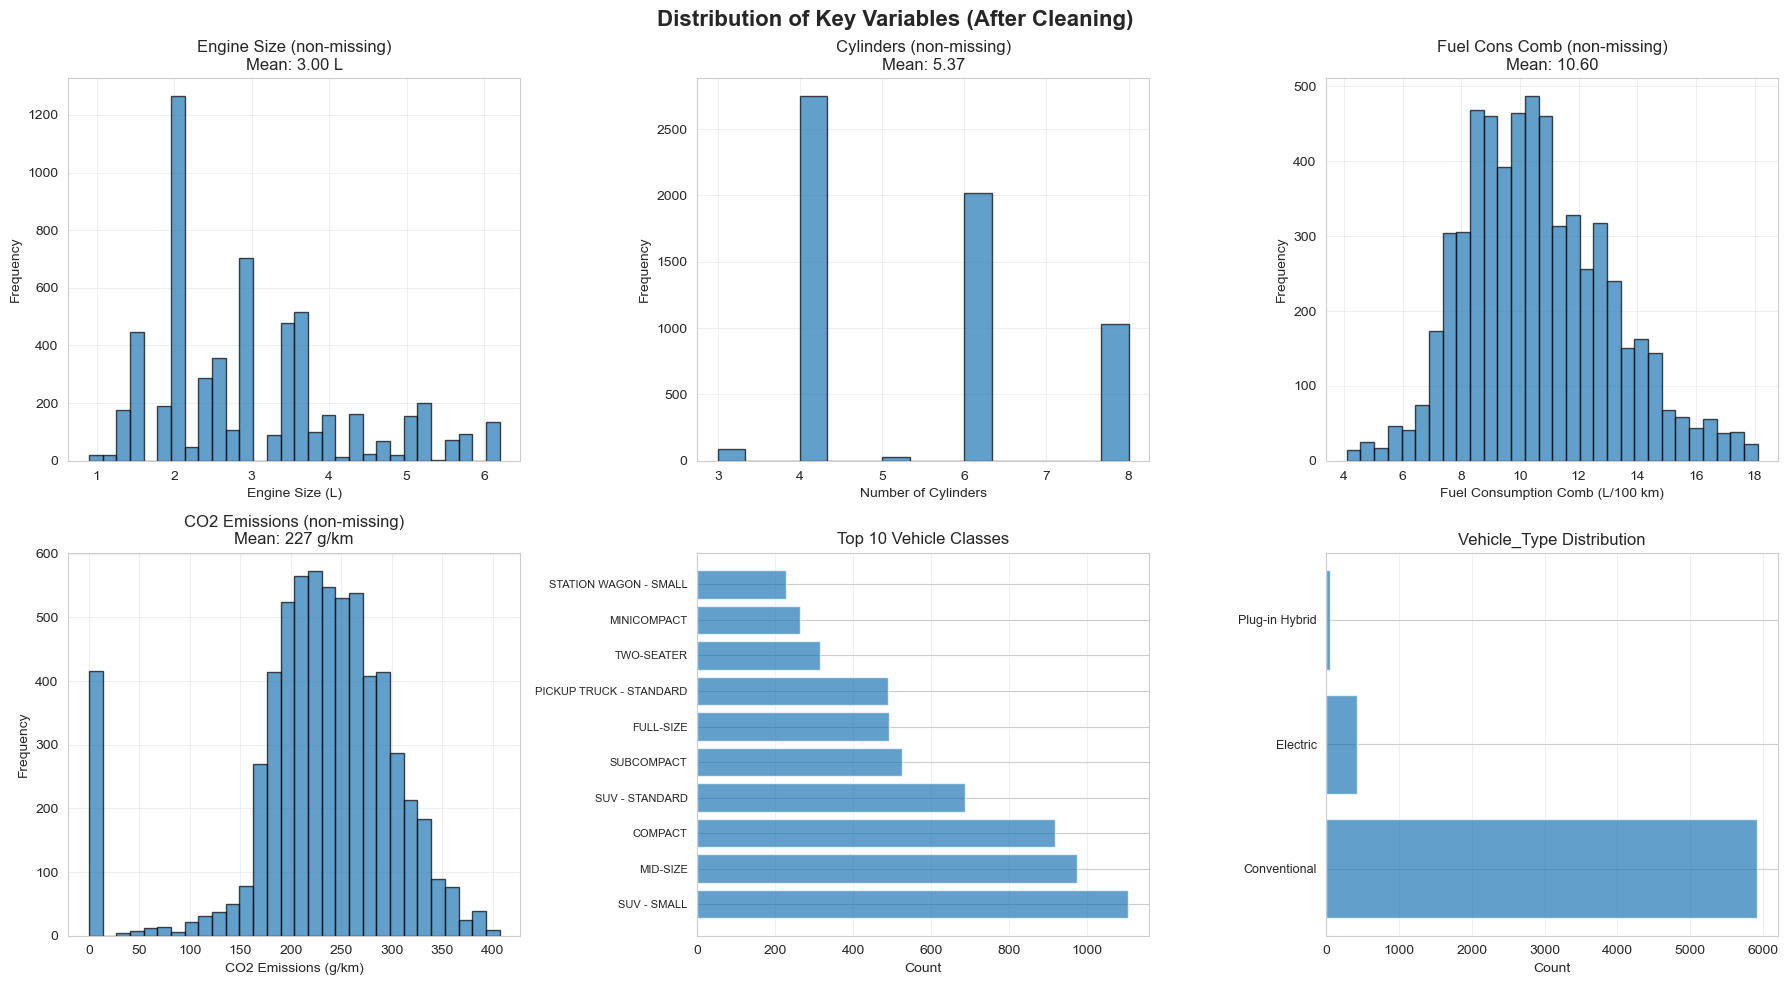


✓ Visualizations generated


In [10]:
#Visualize the distribution of key variables after cleaning.

print("="*80)
print("DATA DISTRIBUTION AFTER CLEANING")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution of Key Variables (After Cleaning)', fontsize=16, fontweight='bold')

def safe_series(col):
    """Return series if exists, else None."""
    return df_clean[col] if col in df_clean.columns else None

def mean_non_missing(s):
    return float(s.dropna().mean()) if s is not None and s.dropna().shape[0] > 0 else float("nan")

# 1) Engine Size (non-missing)
s = safe_series('Engine Size(L)')
if s is not None:
    s_nm = s.dropna()
    axes[0, 0].hist(s_nm, bins=30, edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Engine Size (L)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title(f'Engine Size (non-missing)\nMean: {mean_non_missing(s):.2f} L')
    axes[0, 0].grid(True, alpha=0.3)
else:
    axes[0, 0].set_title("Engine Size(L) not found")
    axes[0, 0].axis("off")

# 2) Cylinders (non-missing)
s = safe_series('Cylinders')
if s is not None:
    s_nm = s.dropna()
    axes[0, 1].hist(s_nm, bins=15, edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Number of Cylinders')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title(f'Cylinders (non-missing)\nMean: {mean_non_missing(s):.2f}')
    axes[0, 1].grid(True, alpha=0.3)
else:
    axes[0, 1].set_title("Cylinders not found")
    axes[0, 1].axis("off")

# 3) Fuel Consumption Comb (non-missing)
s = safe_series('Fuel Consumption Comb (L/100 km)')
if s is not None:
    s_nm = s.dropna()
    axes[0, 2].hist(s_nm, bins=30, edgecolor='black', alpha=0.7)
    axes[0, 2].set_xlabel('Fuel Consumption Comb (L/100 km)')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].set_title(f'Fuel Cons Comb (non-missing)\nMean: {mean_non_missing(s):.2f}')
    axes[0, 2].grid(True, alpha=0.3)
else:
    axes[0, 2].set_title("Fuel Consumption Comb not found")
    axes[0, 2].axis("off")

# 4) CO2 Emissions (non-missing)
s = safe_series('CO2 Emissions(g/km)')
if s is not None:
    s_nm = s.dropna()
    axes[1, 0].hist(s_nm, bins=30, edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('CO2 Emissions (g/km)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title(f'CO2 Emissions (non-missing)\nMean: {mean_non_missing(s):.0f} g/km')
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].set_title("CO2 Emissions not found")
    axes[1, 0].axis("off")

# 5) Top 10 Vehicle Classes
s = safe_series('Vehicle Class')
if s is not None:
    vehicle_class_counts = s.value_counts().head(10)
    axes[1, 1].barh(range(len(vehicle_class_counts)), vehicle_class_counts.values, alpha=0.7)
    axes[1, 1].set_yticks(range(len(vehicle_class_counts)))
    axes[1, 1].set_yticklabels(vehicle_class_counts.index, fontsize=8)
    axes[1, 1].set_xlabel('Count')
    axes[1, 1].set_title('Top 10 Vehicle Classes')
    axes[1, 1].grid(True, alpha=0.3, axis='x')
else:
    axes[1, 1].set_title("Vehicle Class not found")
    axes[1, 1].axis("off")

# 6) Vehicle_Type distribution (replaces Make, avoids error after dropping Make/Model)
s = safe_series('Vehicle_Type')
if s is not None:
    type_counts = s.value_counts()
    axes[1, 2].barh(range(len(type_counts)), type_counts.values, alpha=0.7)
    axes[1, 2].set_yticks(range(len(type_counts)))
    axes[1, 2].set_yticklabels(type_counts.index, fontsize=9)
    axes[1, 2].set_xlabel('Count')
    axes[1, 2].set_title('Vehicle_Type Distribution')
    axes[1, 2].grid(True, alpha=0.3, axis='x')
else:
    axes[1, 2].set_title("Vehicle_Type not found")
    axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

print("\n✓ Visualizations generated")

## FEATURE ENGINEERING - TRANSMISSION FEATURES


In [11]:
#Extract transmission type and number of gears from transmission column.

print("="*80)
print("FEATURE ENGINEERING: TRANSMISSION")
print("="*80)

df_engineered = df_clean.copy()

# Safety: ensure Transmission exists
if "Transmission" not in df_engineered.columns:
    raise KeyError("Column 'Transmission' not found in df_clean.")

# 1) Transmission_Type: first character, but keep 'UNK' for missing
df_engineered["Transmission_Type"] = df_engineered["Transmission"].astype("string").str[0]
df_engineered["Transmission_Type"] = df_engineered["Transmission_Type"].fillna("UNK")

# 2) Num_Gears: extract digits
df_engineered["Num_Gears"] = (
    df_engineered["Transmission"].astype("string").str.extract(r"(\d+)", expand=False).astype(float)
)

# 3) Fill missing gears with median by transmission type
#    IMPORTANT: only do this for rows where Transmission_Type is not UNK
mask_fill = df_engineered["Num_Gears"].isna() & (df_engineered["Transmission_Type"] != "UNK")

df_engineered.loc[mask_fill, "Num_Gears"] = df_engineered.loc[mask_fill].groupby(
    "Transmission_Type"
)["Num_Gears"].transform("median")

# ---- Reporting (non-missing stats for gears) ----
n_types = df_engineered["Transmission_Type"].nunique(dropna=False)
type_dist = df_engineered["Transmission_Type"].value_counts(dropna=False).to_dict()

gears_non_missing = df_engineered["Num_Gears"].dropna()

print(f"\n✓ Transmission features extracted:")
print(f"  - Transmission_Type: {n_types} unique types (including 'UNK' for missing)")
print(f"    Distribution: {type_dist}")

if len(gears_non_missing) > 0:
    print(f"\n  - Num_Gears (non-missing): Range {gears_non_missing.min():.0f} to {gears_non_missing.max():.0f}")
    print(f"    Mean (non-missing): {gears_non_missing.mean():.1f}")
else:
    print("\n  - Num_Gears: all missing (no numeric gears found)")

print(f"\n  Example transmissions:")
display(df_engineered[["Vehicle_Type", "Transmission", "Transmission_Type", "Num_Gears"]].head(10))

FEATURE ENGINEERING: TRANSMISSION

✓ Transmission features extracted:
  - Transmission_Type: 3 unique types (including 'UNK' for missing)
    Distribution: {'A': 4911, 'M': 1000, 'UNK': 474}

  - Num_Gears (non-missing): Range 4 to 10
    Mean (non-missing): 6.9

  Example transmissions:


,Vehicle_Type,Transmission,Transmission_Type,Num_Gears
0,Conventional,AS5,A,5.0
1,Conventional,M6,M,6.0
2,Conventional,AV7,A,7.0
3,Conventional,AS6,A,6.0
4,Conventional,AS6,A,6.0
5,Conventional,AS6,A,6.0
6,Conventional,AS6,A,6.0
7,Conventional,AS6,A,6.0
8,Conventional,M6,M,6.0
9,Conventional,AS5,A,5.0


FEATURE ENGINEERING: FUEL EFFICIENCY (3 VEHICLE TYPES)
Note: 'Fuel Consumption City (L/100 km)' and/or 'Fuel Consumption Hwy (L/100 km)' not found (likely dropped in noise filtering).
      'City_Hwy_Diff' set to NaN (skipped).

✓ Fuel efficiency metrics created:

  Fuel_Efficiency (km/L) [non-missing only]:
    Mean: 9.97 km/L
    Range: 5.52 to 24.39 km/L
    n: 5969

  City_Hwy_Diff (City - Hwy) [non-missing only]:
    Not available (columns missing) or all missing.

  Non-missing counts by Vehicle_Type:


,Fuel_Efficiency,City_Hwy_Diff
Vehicle_Type,,
Conventional,5911,0
Electric,0,0
Plug-in Hybrid,58,0


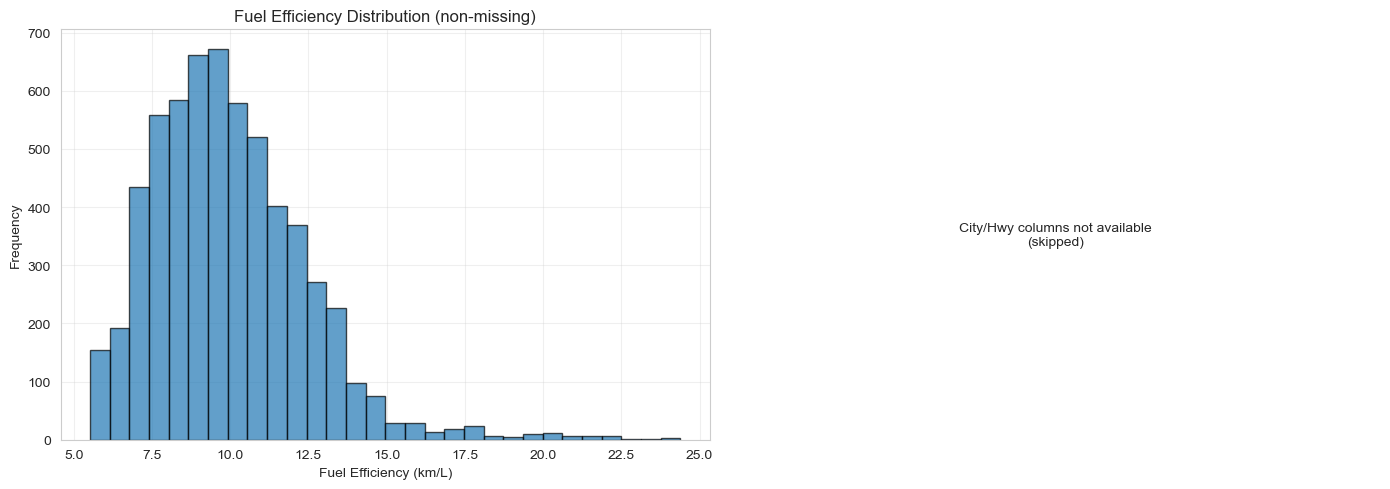

In [12]:
#Create fuel efficiency and consumption differential features.

print("="*80)
print("FEATURE ENGINEERING: FUEL EFFICIENCY (3 VEHICLE TYPES)")
print("="*80)

# Ensure df_engineered exists
# (If you just did transmission/performance steps, df_engineered should already exist)
# If not, uncomment the next line:
# df_engineered = df_clean.copy()

# -----------------------------
# 1) Fuel_Efficiency (km/L) from Comb (L/100km)
# -----------------------------
df_engineered["Fuel_Efficiency"] = np.nan

comb_col = "Fuel Consumption Comb (L/100 km)"
if comb_col not in df_engineered.columns:
    raise KeyError(f"Missing required column: '{comb_col}'")

mask_fuel_ok = df_engineered[comb_col].notna() & (df_engineered[comb_col] > 0)
df_engineered.loc[mask_fuel_ok, "Fuel_Efficiency"] = 100.0 / df_engineered.loc[mask_fuel_ok, comb_col]

# -----------------------------
# 2) City_Hwy_Diff (only if City & Hwy columns exist)
# -----------------------------
city_col = "Fuel Consumption City (L/100 km)"
hwy_col  = "Fuel Consumption Hwy (L/100 km)"

if (city_col in df_engineered.columns) and (hwy_col in df_engineered.columns):
    df_engineered["City_Hwy_Diff"] = df_engineered[city_col] - df_engineered[hwy_col]
    city_hwy_available = True
else:
    df_engineered["City_Hwy_Diff"] = np.nan
    city_hwy_available = False
    print(f"Note: '{city_col}' and/or '{hwy_col}' not found (likely dropped in noise filtering).")
    print("      'City_Hwy_Diff' set to NaN (skipped).")

# -----------------------------
# 3) Print summary (non-missing)
# -----------------------------
fe = df_engineered["Fuel_Efficiency"].dropna()
print(f"\n✓ Fuel efficiency metrics created:")

print(f"\n  Fuel_Efficiency (km/L) [non-missing only]:")
if len(fe) > 0:
    print(f"    Mean: {fe.mean():.2f} km/L")
    print(f"    Range: {fe.min():.2f} to {fe.max():.2f} km/L")
    print(f"    n: {len(fe)}")
else:
    print("    All missing (no valid fuel consumption values)")

chd = df_engineered["City_Hwy_Diff"].dropna()
print(f"\n  City_Hwy_Diff (City - Hwy) [non-missing only]:")
if city_hwy_available and len(chd) > 0:
    print(f"    Mean: {chd.mean():.2f}")
    print(f"    Range: {chd.min():.2f} to {chd.max():.2f}")
    print(f"    n: {len(chd)}")
    print("    (Positive = worse in city, Negative = worse on highway)")
else:
    print("    Not available (columns missing) or all missing.")

# Optional: show counts by Vehicle_Type (useful for your 3-type design)
print("\n  Non-missing counts by Vehicle_Type:")
display(df_engineered.groupby("Vehicle_Type")[["Fuel_Efficiency", "City_Hwy_Diff"]].apply(lambda g: g.notna().sum()))

# -----------------------------
# 4) Visualize (only non-missing)
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fuel_Efficiency hist
axes[0].hist(fe, bins=30, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Fuel Efficiency (km/L)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Fuel Efficiency Distribution (non-missing)")
axes[0].grid(True, alpha=0.3)

# City_Hwy_Diff hist (if available)
if city_hwy_available and len(chd) > 0:
    axes[1].hist(chd, bins=30, edgecolor="black", alpha=0.7)
    axes[1].axvline(0, linestyle="--", linewidth=2, label="No difference")
    axes[1].set_xlabel("City - Highway Consumption (L/100km)")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title("City vs Highway Consumption Difference")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "City/Hwy columns not available\n(skipped)", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

FEATURE ENGINEERING: PERFORMANCE INDICATORS (3 VEHICLE TYPES) - UPDATED

✓ Performance indicators created (Electric kept as NaN where not meaningful).

  Power_Proxy [overall non-missing]: n=5911, mean=17.81, range=(2.70, 49.60)

  Efficiency_Ratio [overall non-missing]: n=5911, mean=88.77, range=(41.61, 197.00)

  Stats by Vehicle_Type (non-missing):


,Power_Proxy,Efficiency_Ratio
Vehicle_Type,,
Conventional,5911,5911
Electric,0,0
Plug-in Hybrid,0,0


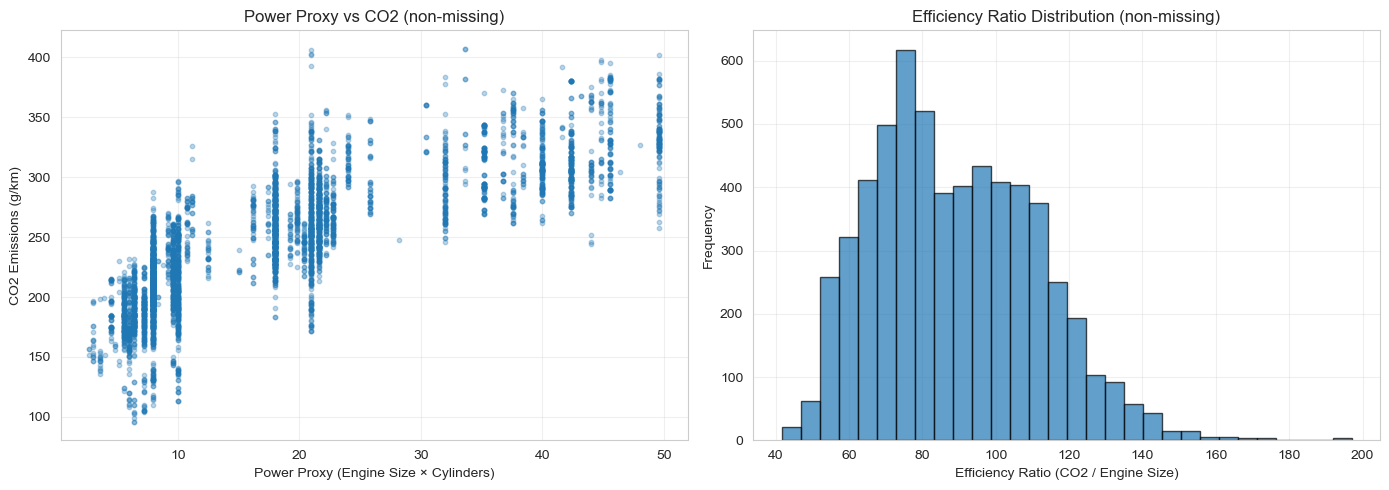

In [13]:
#Create power and efficiency ratio features.

print("="*80)
print("FEATURE ENGINEERING: PERFORMANCE INDICATORS (3 VEHICLE TYPES) - UPDATED")
print("="*80)

# Safety check
required_cols = ["Vehicle_Type", "Engine Size(L)", "Cylinders", "CO2 Emissions(g/km)"]
missing_cols = [c for c in required_cols if c not in df_engineered.columns]
if missing_cols:
    raise KeyError(f"Missing required columns in df_engineered: {missing_cols}")

# ------------------------------------------------------------
# 1) Create columns with NaN by default (Electric stays NaN)
# ------------------------------------------------------------
df_engineered["Power_Proxy"] = np.nan
df_engineered["Efficiency_Ratio"] = np.nan

# ------------------------------------------------------------
# 2) Compute only where Engine Size makes sense (non-Electric) and is valid
#    (You can adjust engine_min if you want)
# ------------------------------------------------------------
engine_min = 0.5  # optional: avoid tiny/erroneous engine sizes creating huge ratios

mask_non_electric = df_engineered["Vehicle_Type"].isin(["Conventional", "Plug-in Hybrid"])

mask_engine_ok = (
    mask_non_electric &
    df_engineered["Engine Size(L)"].notna() &
    (df_engineered["Engine Size(L)"] > engine_min) &
    df_engineered["Cylinders"].notna() &
    (df_engineered["Cylinders"] > 0)
)

# Power proxy: Engine Size × Cylinders
df_engineered.loc[mask_engine_ok, "Power_Proxy"] = (
    df_engineered.loc[mask_engine_ok, "Engine Size(L)"] *
    df_engineered.loc[mask_engine_ok, "Cylinders"]
)

# Efficiency ratio: CO2 / Engine Size
mask_eff_ok = mask_engine_ok & df_engineered["CO2 Emissions(g/km)"].notna()
df_engineered.loc[mask_eff_ok, "Efficiency_Ratio"] = (
    df_engineered.loc[mask_eff_ok, "CO2 Emissions(g/km)"] /
    df_engineered.loc[mask_eff_ok, "Engine Size(L)"]
)

print("\n✓ Performance indicators created (Electric kept as NaN where not meaningful).")

# ------------------------------------------------------------
# 3) Summary stats (overall non-missing + by Vehicle_Type)
# ------------------------------------------------------------
def summarize_series(s):
    s = s.dropna()
    if len(s) == 0:
        return {"n": 0, "mean": np.nan, "min": np.nan, "max": np.nan}
    return {"n": len(s), "mean": float(s.mean()), "min": float(s.min()), "max": float(s.max())}

for col in ["Power_Proxy", "Efficiency_Ratio"]:
    stats = summarize_series(df_engineered[col])
    print(f"\n  {col} [overall non-missing]: n={stats['n']}, mean={stats['mean']:.2f}, range=({stats['min']:.2f}, {stats['max']:.2f})")

print("\n  Stats by Vehicle_Type (non-missing):")
stats_by_type = df_engineered.groupby("Vehicle_Type")[["Power_Proxy", "Efficiency_Ratio"]].agg(
    n=("Power_Proxy", lambda s: s.notna().sum())
)
# better: show counts for both columns
counts_by_type = df_engineered.groupby("Vehicle_Type")[["Power_Proxy", "Efficiency_Ratio"]].apply(lambda g: g.notna().sum())
display(counts_by_type)

# ------------------------------------------------------------
# 4) Visualizations (use only non-missing points)
#    Also: color/marker not required; keep simple
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Power_Proxy vs CO2 (only where Power_Proxy exists)
mask_scatter = df_engineered["Power_Proxy"].notna() & df_engineered["CO2 Emissions(g/km)"].notna()
axes[0].scatter(
    df_engineered.loc[mask_scatter, "Power_Proxy"],
    df_engineered.loc[mask_scatter, "CO2 Emissions(g/km)"],
    alpha=0.3,
    s=10
)
axes[0].set_xlabel("Power Proxy (Engine Size × Cylinders)")
axes[0].set_ylabel("CO2 Emissions (g/km)")
axes[0].set_title("Power Proxy vs CO2 (non-missing)")
axes[0].grid(True, alpha=0.3)

# Histogram: Efficiency_Ratio (only non-missing)
eff = df_engineered["Efficiency_Ratio"].dropna()
axes[1].hist(eff, bins=30, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Efficiency Ratio (CO2 / Engine Size)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Efficiency Ratio Distribution (non-missing)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

FEATURE ENGINEERING: VEHICLE CATEGORIES (3 VEHICLE TYPES) - UPDATED

✓ Vehicle categorization features created:

  SUV Distribution (overall):
    SUVs: 1792 (28.1%)
    Non-SUVs: 4593 (71.9%)

  Truck Distribution (overall):
    Trucks: 711 (11.1%)
    Non-Trucks: 5674 (88.9%)

  Engine Category Distribution (including NaN for Electric):


Engine_Category
Small         2116
Medium        1504
Large         1342
Very Large     949
NaN            474
Name: count, dtype: int64


  CO2 Category Distribution (including NaN):


CO2_Category
Low           604
Medium       1199
High         2013
Very High    2569
Name: count, dtype: int64


  By Vehicle_Type (counts):


,Is_SUV,Is_Truck
Vehicle_Type,,
Conventional,1558,653
Electric,234,58
Plug-in Hybrid,0,0


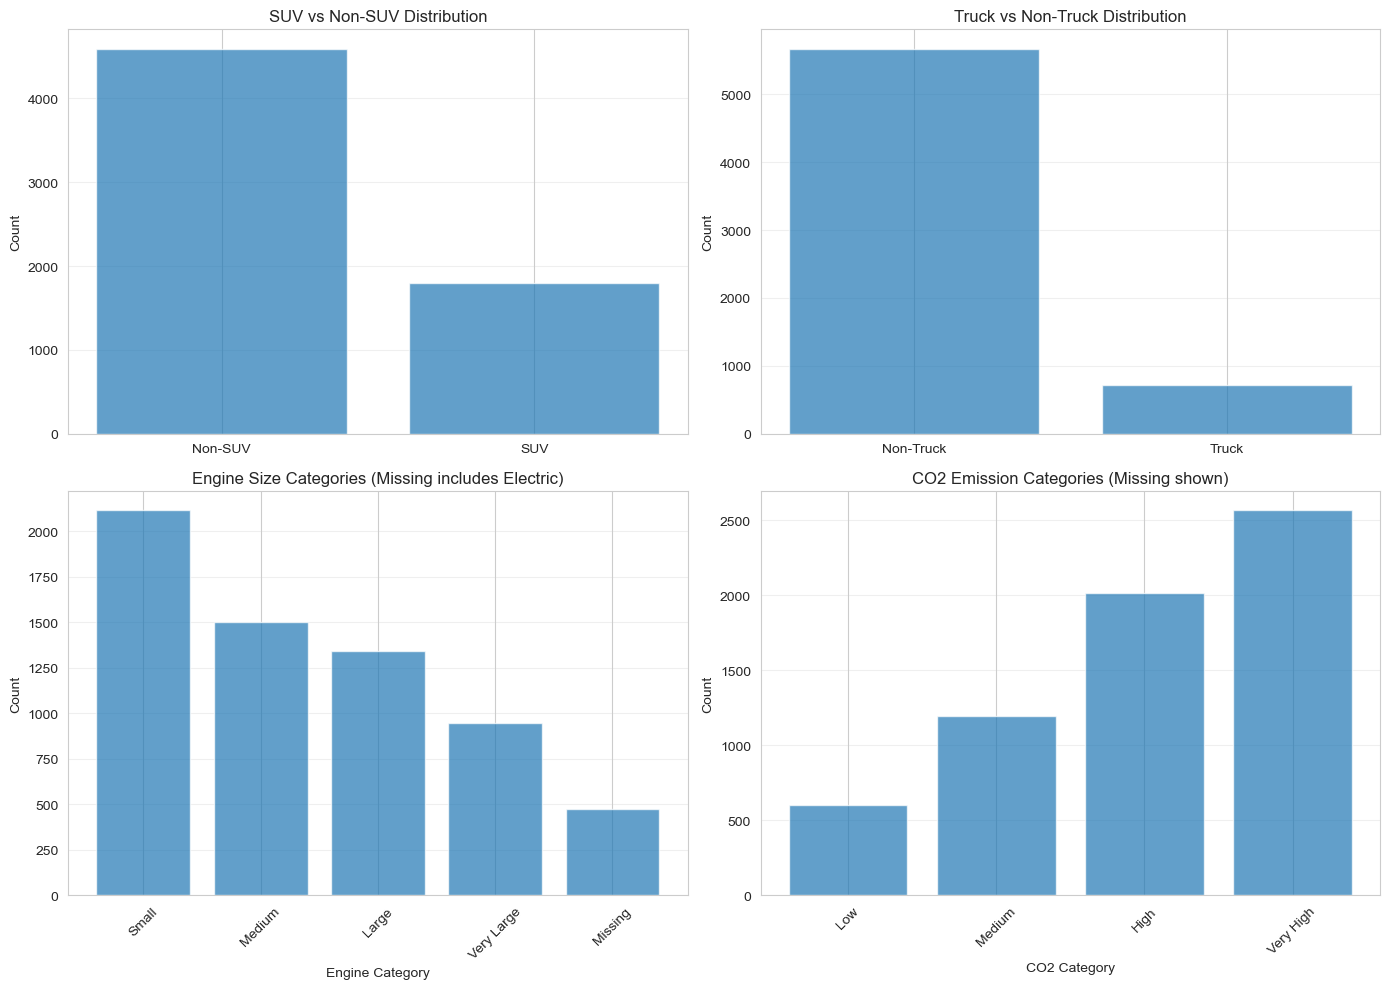

In [14]:
#Create vehicle type category flags (SUV, Truck, etc.).

print("="*80)
print("FEATURE ENGINEERING: VEHICLE CATEGORIES (3 VEHICLE TYPES) - UPDATED")
print("="*80)

# Safety checks
for c in ["Vehicle Class", "Vehicle_Type"]:
    if c not in df_engineered.columns:
        raise KeyError(f"Missing required column: '{c}'")

# ------------------------------------------------------------
# 1) SUV / Truck flags (robust to NaN)
# ------------------------------------------------------------
suv_keywords = ['SUV', 'SPORT UTILITY', 'JEEP']
truck_keywords = ['PICKUP', 'TRUCK', 'VAN']

vc_upper = df_engineered["Vehicle Class"].astype("string").str.upper()

df_engineered["Is_SUV"] = vc_upper.apply(
    lambda x: any(k in x for k in suv_keywords) if pd.notna(x) else False
).astype(int)

df_engineered["Is_Truck"] = vc_upper.apply(
    lambda x: any(k in x for k in truck_keywords) if pd.notna(x) else False
).astype(int)

# ------------------------------------------------------------
# 2) Engine size categories
#    Electric has structural NaN -> stays NaN (do NOT fill)
# ------------------------------------------------------------
if "Engine Size(L)" not in df_engineered.columns:
    raise KeyError("Missing required column: 'Engine Size(L)'")

df_engineered["Engine_Category"] = pd.cut(
    df_engineered["Engine Size(L)"],
    bins=[0, 2, 3, 4, 10],
    labels=["Small", "Medium", "Large", "Very Large"],
    include_lowest=False  # engine size should be >0; NaN stays NaN
)

# ------------------------------------------------------------
# 3) CO2 categories
#    Make sure CO2=0 (possible for Electric) is included
#    Use include_lowest=True so 0 goes into the first bin.
# ------------------------------------------------------------
if "CO2 Emissions(g/km)" not in df_engineered.columns:
    raise KeyError("Missing required column: 'CO2 Emissions(g/km)'")

df_engineered["CO2_Category"] = pd.cut(
    df_engineered["CO2 Emissions(g/km)"],
    bins=[0, 150, 200, 250, 500],
    labels=["Low", "Medium", "High", "Very High"],
    include_lowest=True  # IMPORTANT: include 0 in 'Low'
)

print("\n✓ Vehicle categorization features created:")

# ------------------------------------------------------------
# 4) Print distributions (overall + by Vehicle_Type)
# ------------------------------------------------------------
def pct(x):
    return 100 * float(x)

print(f"\n  SUV Distribution (overall):")
print(f"    SUVs: {int(df_engineered['Is_SUV'].sum())} ({pct(df_engineered['Is_SUV'].mean()):.1f}%)")
print(f"    Non-SUVs: {int((1-df_engineered['Is_SUV']).sum())} ({pct(1-df_engineered['Is_SUV'].mean()):.1f}%)")

print(f"\n  Truck Distribution (overall):")
print(f"    Trucks: {int(df_engineered['Is_Truck'].sum())} ({pct(df_engineered['Is_Truck'].mean()):.1f}%)")
print(f"    Non-Trucks: {int((1-df_engineered['Is_Truck']).sum())} ({pct(1-df_engineered['Is_Truck'].mean()):.1f}%)")

print("\n  Engine Category Distribution (including NaN for Electric):")
display(df_engineered["Engine_Category"].value_counts(dropna=False).sort_index())

print("\n  CO2 Category Distribution (including NaN):")
display(df_engineered["CO2_Category"].value_counts(dropna=False).sort_index())

print("\n  By Vehicle_Type (counts):")
by_type = df_engineered.groupby("Vehicle_Type")[["Is_SUV", "Is_Truck"]].sum()
display(by_type)

# ------------------------------------------------------------
# 5) Visualize (same layout, but robust)
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# SUV vs Non-SUV
suv_counts = df_engineered["Is_SUV"].value_counts().reindex([0, 1], fill_value=0)
axes[0, 0].bar(["Non-SUV", "SUV"], suv_counts.values, alpha=0.7)
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("SUV vs Non-SUV Distribution")
axes[0, 0].grid(True, alpha=0.3, axis="y")

# Truck vs Non-Truck
truck_counts = df_engineered["Is_Truck"].value_counts().reindex([0, 1], fill_value=0)
axes[0, 1].bar(["Non-Truck", "Truck"], truck_counts.values, alpha=0.7)
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Truck vs Non-Truck Distribution")
axes[0, 1].grid(True, alpha=0.3, axis="y")

# Engine Category (include NaN as 'Missing' so Electric is visible)
engine_cat = df_engineered["Engine_Category"].astype("object").fillna("Missing").value_counts()
# keep a sensible order
engine_order = ["Small", "Medium", "Large", "Very Large", "Missing"]
engine_cat = engine_cat.reindex([c for c in engine_order if c in engine_cat.index], fill_value=0)
axes[1, 0].bar(engine_cat.index, engine_cat.values, alpha=0.7)
axes[1, 0].set_xlabel("Engine Category")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Engine Size Categories (Missing includes Electric)")
axes[1, 0].grid(True, alpha=0.3, axis="y")
axes[1, 0].tick_params(axis="x", rotation=45)

# CO2 Category (include NaN)
co2_cat = df_engineered["CO2_Category"].astype("object").fillna("Missing").value_counts()
co2_order = ["Low", "Medium", "High", "Very High", "Missing"]
co2_cat = co2_cat.reindex([c for c in co2_order if c in co2_cat.index], fill_value=0)
axes[1, 1].bar(co2_cat.index, co2_cat.values, alpha=0.7)
axes[1, 1].set_xlabel("CO2 Category")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("CO2 Emission Categories (Missing shown)")
axes[1, 1].grid(True, alpha=0.3, axis="y")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [15]:
#Summary of all engineered features.

print("="*80)
print("FEATURE ENGINEERING SUMMARY (3 VEHICLE TYPES)")
print("="*80)

# Expected engineered features
expected_features = [
    "Transmission_Type",
    "Num_Gears",
    "Fuel_Efficiency",
    "City_Hwy_Diff",      # may not exist
    "Power_Proxy",
    "Efficiency_Ratio",
    "Is_SUV",
    "Is_Truck",
    "Engine_Category",
    "CO2_Category"
]

# Keep only features that actually exist
existing_features = [f for f in expected_features if f in df_engineered.columns]
missing_features  = [f for f in expected_features if f not in df_engineered.columns]

print(f"\n✓ Total engineered features expected: {len(expected_features)}")
print(f"✓ Found in dataset: {len(existing_features)}")
print(f"✓ Missing/skipped: {len(missing_features)}")

# ------------------------------------------------------------
# Feature list with dtype and non-missing counts
# ------------------------------------------------------------
print(f"\n  Feature list (with dtype and non-missing counts):")

for i, feature in enumerate(existing_features, 1):

    dtype = df_engineered[feature].dtype
    non_missing = df_engineered[feature].notna().sum()
    pct = 100 * non_missing / len(df_engineered)

    print(f"    {i}. {feature}")
    print(f"       dtype: {dtype}")
    print(f"       non-missing: {non_missing}/{len(df_engineered)} ({pct:.1f}%)")

# ------------------------------------------------------------
# Missing features warning
# ------------------------------------------------------------
if missing_features:
    print("\n  Skipped features (not present in df_engineered):")
    for f in missing_features:
        print(f"    - {f}")

# ------------------------------------------------------------
# Dataset shape comparison
# ------------------------------------------------------------
print(f"\n  Dataset shape:")
print(f"    Original (df_clean): {df_clean.shape}")
print(f"    With engineered features (df_engineered): {df_engineered.shape}")

print(f"\n  Total columns now: {len(df_engineered.columns)}")

# ------------------------------------------------------------
# VERY IMPORTANT: counts by Vehicle_Type (for clustering design)
# ------------------------------------------------------------
print("\n  Non-missing counts by Vehicle_Type:")
display(
    df_engineered.groupby("Vehicle_Type")[existing_features]
    .apply(lambda g: g.notna().sum())
)

FEATURE ENGINEERING SUMMARY (3 VEHICLE TYPES)

✓ Total engineered features expected: 10
✓ Found in dataset: 10
✓ Missing/skipped: 0

  Feature list (with dtype and non-missing counts):
    1. Transmission_Type
       dtype: string
       non-missing: 6385/6385 (100.0%)
    2. Num_Gears
       dtype: float64
       non-missing: 5670/6385 (88.8%)
    3. Fuel_Efficiency
       dtype: float64
       non-missing: 5969/6385 (93.5%)
    4. City_Hwy_Diff
       dtype: float64
       non-missing: 0/6385 (0.0%)
    5. Power_Proxy
       dtype: float64
       non-missing: 5911/6385 (92.6%)
    6. Efficiency_Ratio
       dtype: float64
       non-missing: 5911/6385 (92.6%)
    7. Is_SUV
       dtype: int64
       non-missing: 6385/6385 (100.0%)
    8. Is_Truck
       dtype: int64
       non-missing: 6385/6385 (100.0%)
    9. Engine_Category
       dtype: category
       non-missing: 5911/6385 (92.6%)
    10. CO2_Category
       dtype: category
       non-missing: 6385/6385 (100.0%)

  Dataset shap

,Transmission_Type,Num_Gears,Fuel_Efficiency,City_Hwy_Diff,Power_Proxy,Efficiency_Ratio,Is_SUV,Is_Truck,Engine_Category,CO2_Category
Vehicle_Type,,,,,,,,,,
Conventional,5911,5670,5911,0,5911,5911,5911,5911,5911,5911
Electric,416,0,0,0,0,0,416,416,0,416
Plug-in Hybrid,58,0,58,0,0,0,58,58,0,58


## ENCODING CATEGORICAL VARIABLES


In [16]:
print("="*80)
print("ENCODING + FEATURE SELECTION (3 VEHICLE TYPES, MARKET SEGMENTATION)")
print("="*80)

# -----------------------------
# 0) Start from engineered data
# -----------------------------
df_encoded = df_engineered.copy()

# -----------------------------
# 1) One-hot encode categorical vars (clustering-safe)
# -----------------------------
cat_cols = ["Fuel Type", "Transmission_Type", "Powertrain Type"]
for c in cat_cols:
    if c not in df_encoded.columns:
        raise KeyError(f"Missing column '{c}' in df_engineered")

# normalize NaNs
df_encoded["Fuel Type"] = df_encoded["Fuel Type"].astype("string").fillna("UNK")
df_encoded["Transmission_Type"] = df_encoded["Transmission_Type"].astype("string").fillna("UNK")
df_encoded["Powertrain Type"] = df_encoded["Powertrain Type"].astype("string").fillna("UNK")

df_encoded = pd.get_dummies(
    df_encoded,
    columns=["Fuel Type", "Transmission_Type", "Powertrain Type"],
    prefix=["Fuel", "Trans", "Powertrain"],
    dummy_na=False
)

fuel_ohe = [c for c in df_encoded.columns if c.startswith("Fuel_")]
trans_ohe = [c for c in df_encoded.columns if c.startswith("Trans_")]
powertrain_ohe = [c for c in df_encoded.columns if c.startswith("Powertrain_")]

print("\n✓ Encoding completed (one-hot):")
print(f"  Fuel OHE: {len(fuel_ohe)} cols")
print(f"  Transmission OHE: {len(trans_ohe)} cols")
print(f"  Powertrain OHE: {len(powertrain_ohe)} cols")
print(f"  Encoded dataset shape: {df_encoded.shape}")

# -----------------------------
# 2) Define feature sets per Vehicle_Type
# -----------------------------
def keep_existing(cols):
    return [c for c in cols if c in df_encoded.columns]

# Common flags (work for all types)
common_flags = ["Is_SUV", "Is_Truck"]

# ---- Conventional: rich ICE features ----
features_conventional = keep_existing([
    "Engine Size(L)",
    "Cylinders",
    "Fuel Consumption Comb (L/100 km)",
    "CO2 Emissions(g/km)",
    "Num_Gears",
    "Fuel_Efficiency",
    "Power_Proxy",
    "Efficiency_Ratio",
    *common_flags
]) + fuel_ohe + trans_ohe

# ---- Electric: EV-specific ----
features_electric = keep_existing([
    "Energy Consumption Comb (Le/100km)",
    "Electric Range (km)",
    "CO2 Emissions(g/km)",
    *common_flags
]) + powertrain_ohe

# ---- Plug-in Hybrid: mixed ----
features_phev = keep_existing([
    "Fuel Consumption Comb (L/100 km)",
    "Energy Consumption Comb (Le/100km)",
    "CO2 Emissions(g/km)",
    "Fuel_Efficiency",
    *common_flags
]) + fuel_ohe + trans_ohe + powertrain_ohe

print("\n✓ Feature sets defined:")
print(f"  Conventional: {len(features_conventional)} features")
print(f"  Electric:     {len(features_electric)} features")
print(f"  Plug-in Hyb:  {len(features_phev)} features")

# -----------------------------
# 3) Filter step inside each Vehicle_Type
#    FIX: handle duplicated column names safely
# -----------------------------
def drop_constant_and_near_constant(X, near_thr=0.99):
    # FIX 1: ensure unique column names (duplicate names cause X[c] to be a DataFrame)
    if X.columns.duplicated().any():
        X = X.loc[:, ~X.columns.duplicated()].copy()

    # drop constant
    const_cols = []
    for c in X.columns:
        nuniq = X[c].nunique(dropna=False)  # guaranteed scalar now
        if nuniq <= 1:
            const_cols.append(c)
    X = X.drop(columns=const_cols, errors="ignore")

    # drop near-constant
    near_cols = []
    for c in X.columns:
        vc = X[c].value_counts(normalize=True, dropna=False)
        if len(vc) > 0 and vc.iloc[0] >= near_thr:
            near_cols.append(c)
    X = X.drop(columns=near_cols, errors="ignore")

    return X, const_cols, near_cols

# -----------------------------
# 4) Build X matrices
#    FIX: de-duplicate columns before filtering, and print duplicates if exist
# -----------------------------
def build_X(vehicle_type, feature_list):
    df_sub = df_encoded[df_encoded["Vehicle_Type"] == vehicle_type].copy()
    X = df_sub[feature_list].copy()

    # FIX 2: remove duplicated columns early (so dropna and filtering are stable)
    if X.columns.duplicated().any():
        dup_cols = X.columns[X.columns.duplicated()].tolist()
        print(f"\n⚠️ {vehicle_type}: duplicated columns detected (showing up to 20):")
        print("   ", dup_cols[:20], "..." if len(dup_cols) > 20 else "")
        X = X.loc[:, ~X.columns.duplicated()].copy()

    # drop rows with any NaN in these features
    X = X.dropna()

    # filter constant/near-constant
    X, const_cols, near_cols = drop_constant_and_near_constant(X, near_thr=0.99)

    print(f"\n--- {vehicle_type} ---")
    print(f"Initial rows: {len(df_sub)}")
    print(f"Rows after dropna on features: {len(X)}")
    print(f"Features kept: {X.shape[1]}")
    print(f"Dropped constant: {len(const_cols)} | Dropped near-constant: {len(near_cols)}")

    return X

X_conv = build_X("Conventional", features_conventional)
X_ev   = build_X("Electric", features_electric)
X_phev = build_X("Plug-in Hybrid", features_phev)

print("\n✓ Feature matrices created:")
print("  X_conv:", X_conv.shape)
print("  X_ev:  ", X_ev.shape)
print("  X_phev:", X_phev.shape)

print("\nMemory usage (MB):")
print(f"  X_conv: {X_conv.memory_usage(deep=True).sum()/1024**2:.2f}")
print(f"  X_ev:   {X_ev.memory_usage(deep=True).sum()/1024**2:.2f}")
print(f"  X_phev: {X_phev.memory_usage(deep=True).sum()/1024**2:.2f}")


ENCODING + FEATURE SELECTION (3 VEHICLE TYPES, MARKET SEGMENTATION)

✓ Encoding completed (one-hot):
  Fuel OHE: 9 cols
  Transmission OHE: 3 cols
  Powertrain OHE: 4 cols
  Encoded dataset shape: (6385, 34)

✓ Feature sets defined:
  Conventional: 22 features
  Electric:     9 features
  Plug-in Hyb:  22 features

⚠️ Conventional: duplicated columns detected (showing up to 20):
    ['Fuel_Efficiency'] 

--- Conventional ---
Initial rows: 5911
Rows after dropna on features: 5670
Features kept: 16
Dropped constant: 4 | Dropped near-constant: 1

--- Electric ---
Initial rows: 416
Rows after dropna on features: 416
Features kept: 4
Dropped constant: 5 | Dropped near-constant: 0

⚠️ Plug-in Hybrid: duplicated columns detected (showing up to 20):
    ['Fuel_Efficiency'] 

--- Plug-in Hybrid ---
Initial rows: 58
Rows after dropna on features: 58
Features kept: 6
Dropped constant: 15 | Dropped near-constant: 0

✓ Feature matrices created:
  X_conv: (5670, 16)
  X_ev:   (416, 4)
  X_phev: (58,

CORRELATION ANALYSIS (BY VEHICLE TYPE)

--- Conventional ---
Features: 16 | Samples: 5670
1) Highly Correlated Feature Pairs (|r| > 0.9): Found 7 pairs
   Engine Size(L) ↔ Cylinders | r=0.937
   Engine Size(L) ↔ Power_Proxy | r=0.986
   Cylinders ↔ Power_Proxy | r=0.961
   Fuel Consumption Comb (L/100 km) ↔ CO2 Emissions(g/km) | r=0.919
   Fuel Consumption Comb (L/100 km) ↔ Fuel_Efficiency | r=-0.953
   CO2 Emissions(g/km) ↔ Fuel_Efficiency | r=-0.915
   Trans_A ↔ Trans_M | r=-1.000

2) Features to Remove (highly correlated):
   1. CO2 Emissions(g/km)
   2. Cylinders
   3. Fuel_Efficiency
   4. Power_Proxy
   5. Trans_M

✓ Feature selection based on correlation:
  Original features: 16
  Features removed: 5
  Final features: 11


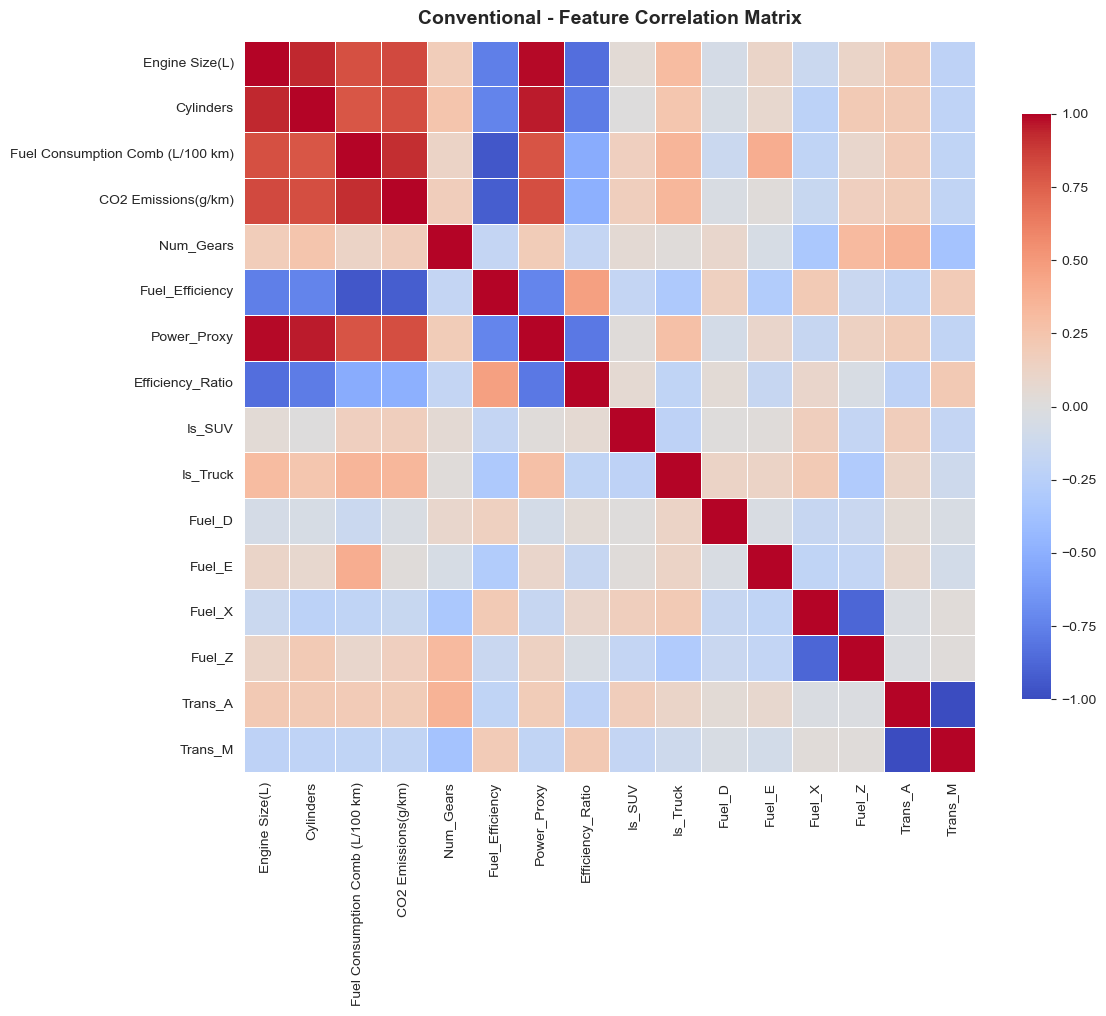


--- Electric ---
Features: 4 | Samples: 416
1) Highly Correlated Feature Pairs (|r| > 0.9): Found 0 pairs

2) Features to Remove (highly correlated):
   None

✓ Feature selection based on correlation:
  Original features: 4
  Features removed: 0
  Final features: 4


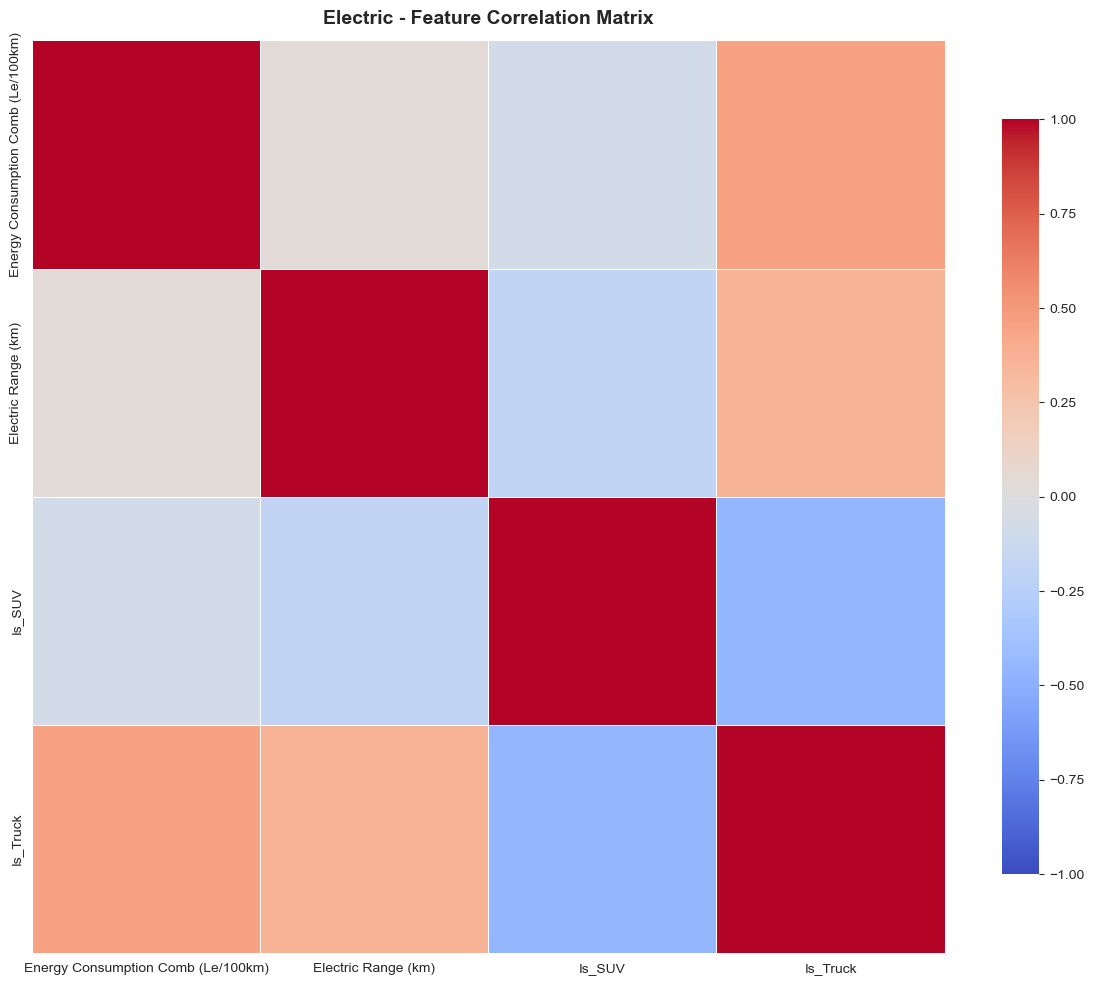


--- Plug-in Hybrid ---
Features: 6 | Samples: 58
1) Highly Correlated Feature Pairs (|r| > 0.9): Found 5 pairs
   Fuel Consumption Comb (L/100 km) ↔ Energy Consumption Comb (Le/100km) | r=0.909
   Fuel Consumption Comb (L/100 km) ↔ CO2 Emissions(g/km) | r=0.908
   Fuel Consumption Comb (L/100 km) ↔ Fuel_Efficiency | r=-0.912
   Energy Consumption Comb (Le/100km) ↔ Fuel_Efficiency | r=-0.921
   Fuel_B / X ↔ Fuel_B / Z | r=-1.000

2) Features to Remove (highly correlated):
   1. CO2 Emissions(g/km)
   2. Energy Consumption Comb (Le/100km)
   3. Fuel_B / Z
   4. Fuel_Efficiency

✓ Feature selection based on correlation:
  Original features: 6
  Features removed: 4
  Final features: 2


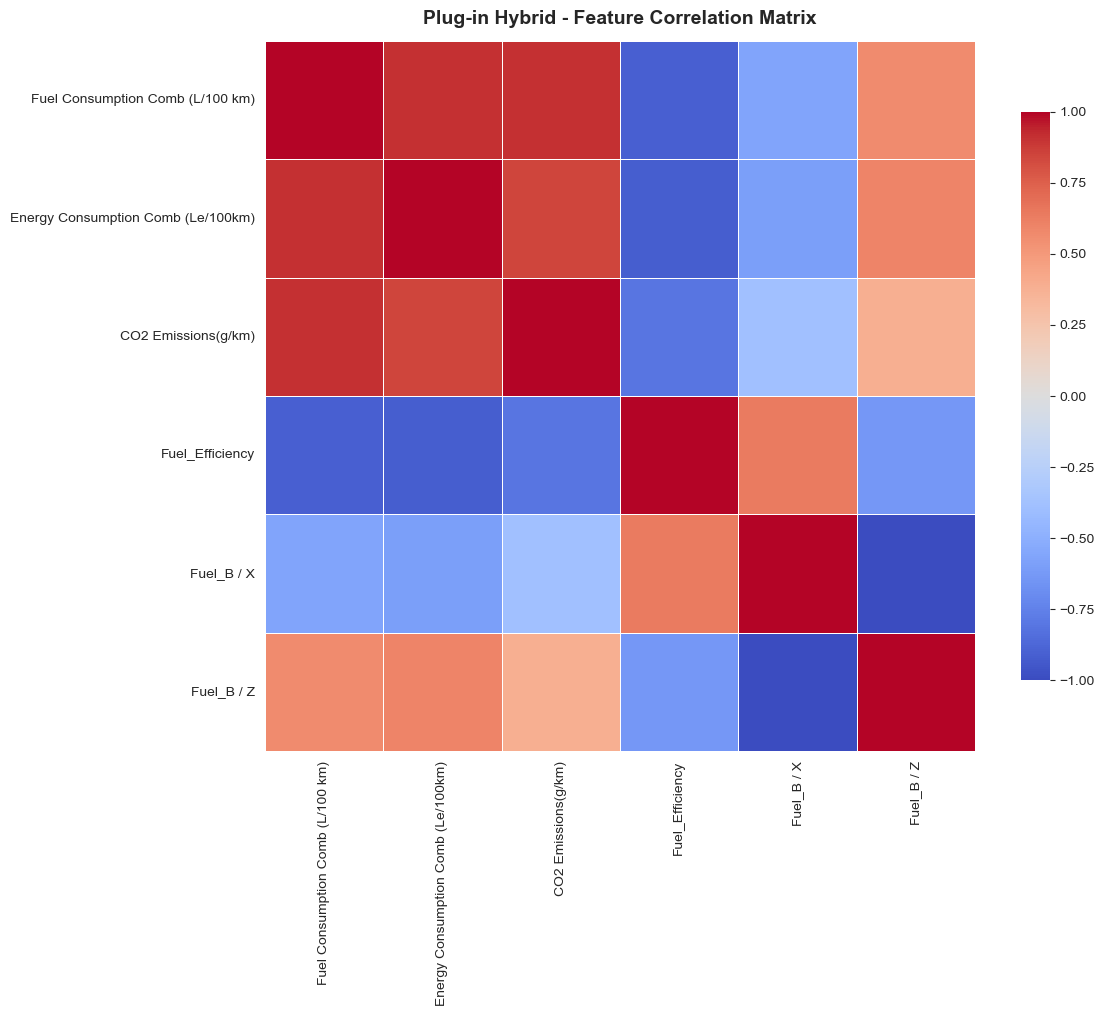


FINAL SHAPES AFTER CORRELATION FILTER
X_conv_sel: (5670, 11)
X_ev_sel:   (416, 4)
X_phev_sel: (58, 2)


In [17]:
#Analyze correlations between features to identify redundant features.
import seaborn as sns

print("="*80)
print("CORRELATION ANALYSIS (BY VEHICLE TYPE)")
print("="*80)

def correlation_filter(X, name, thr=0.9, plot=True, max_plot_feats=25):
    """
    Find highly correlated feature pairs and remove redundant features.
    Strategy: for each correlated pair, remove the second feature (simple, reproducible).
    """
    corr_matrix = X.corr(numeric_only=True)

    # Find highly correlated pairs (upper triangle)
    cols = corr_matrix.columns
    high_corr_pairs = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr_matrix.iloc[i, j]
            if np.isfinite(r) and abs(r) > thr:
                high_corr_pairs.append((cols[i], cols[j], float(r)))

    print(f"\n--- {name} ---")
    print(f"Features: {X.shape[1]} | Samples: {X.shape[0]}")
    print(f"1) Highly Correlated Feature Pairs (|r| > {thr}): Found {len(high_corr_pairs)} pairs")

    # Print pairs (optional: limit to avoid huge output)
    for (feat1, feat2, r) in high_corr_pairs[:30]:
        print(f"   {feat1} ↔ {feat2} | r={r:.3f}")
    if len(high_corr_pairs) > 30:
        print(f"   ... (showing 30 of {len(high_corr_pairs)})")

    # Decide features to remove
    features_to_remove = set()
    for feat1, feat2, r in high_corr_pairs:
        features_to_remove.add(feat2)  # simple rule: remove second feature

    selected_features = [c for c in X.columns if c not in features_to_remove]
    X_selected = X[selected_features].copy()

    print("\n2) Features to Remove (highly correlated):")
    if features_to_remove:
        for i, f in enumerate(sorted(features_to_remove), 1):
            print(f"   {i}. {f}")
    else:
        print("   None")

    print("\n✓ Feature selection based on correlation:")
    print(f"  Original features: {X.shape[1]}")
    print(f"  Features removed: {len(features_to_remove)}")
    print(f"  Final features: {X_selected.shape[1]}")

    # Plot heatmap (optional)
    if plot:
        # If too many features, plot a subset: pick features with highest average absolute correlation
        plot_cols = list(corr_matrix.columns)
        if len(plot_cols) > max_plot_feats:
            avg_abs_corr = corr_matrix.abs().mean().sort_values(ascending=False)
            plot_cols = avg_abs_corr.head(max_plot_feats).index.tolist()
            corr_plot = corr_matrix.loc[plot_cols, plot_cols]
            title_extra = f" (Top {max_plot_feats} features by avg |corr|)"
        else:
            corr_plot = corr_matrix
            title_extra = ""

        plt.figure(figsize=(12, 10))
        sns.heatmap(
            corr_plot,
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1
        )
        plt.title(f"{name} - Feature Correlation Matrix{title_extra}", fontsize=14, fontweight="bold", pad=12)
        plt.tight_layout()
        plt.show()

    return X_selected, selected_features, features_to_remove, corr_matrix

# Run for each vehicle type matrix you already created
X_conv_sel, selected_conv, removed_conv, corr_conv = correlation_filter(X_conv, "Conventional", thr=0.9, plot=True)
X_ev_sel, selected_ev, removed_ev, corr_ev = correlation_filter(X_ev, "Electric", thr=0.9, plot=True)
X_phev_sel, selected_phev, removed_phev, corr_phev = correlation_filter(X_phev, "Plug-in Hybrid", thr=0.9, plot=True)

print("\n" + "="*80)
print("FINAL SHAPES AFTER CORRELATION FILTER")
print("="*80)
print("X_conv_sel:", X_conv_sel.shape)
print("X_ev_sel:  ", X_ev_sel.shape)
print("X_phev_sel:", X_phev_sel.shape)


FEATURE STANDARDIZATION (BY VEHICLE TYPE) - FIX BooleanDtype

--- Conventional ---
Before scaling: shape=(5670, 11)

Sample statistics before scaling:


,Engine Size(L),Fuel Consumption Comb (L/100 km),Num_Gears,Efficiency_Ratio,Is_SUV,Is_Truck,Fuel_D,Fuel_E,Fuel_X,Fuel_Z,Trans_A
count,5670.000000,5670.000000,5670.000000,5670.000000,5670.000000,5670.000000,5670.000000,5670.000000,5670.000000,5670.000000,5670.000000
mean,3.035150,10.750106,6.862963,88.882448,0.263316,0.114815,0.025926,0.039330,0.488713,0.445855,0.823633
std,1.218997,2.390904,1.212370,22.214835,0.440471,0.318826,0.158928,0.194396,0.499917,0.497104,0.381166
min,0.900000,4.100000,4.000000,41.612903,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,9.000000,6.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,3.000000,10.500000,6.000000,86.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,3.600000,12.300000,8.000000,104.666667,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,6.200000,18.100000,10.000000,197.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



✓ Scaling completed
Mean (should be ~0): 0.0000000000
Std (should be ~1): 1.0001


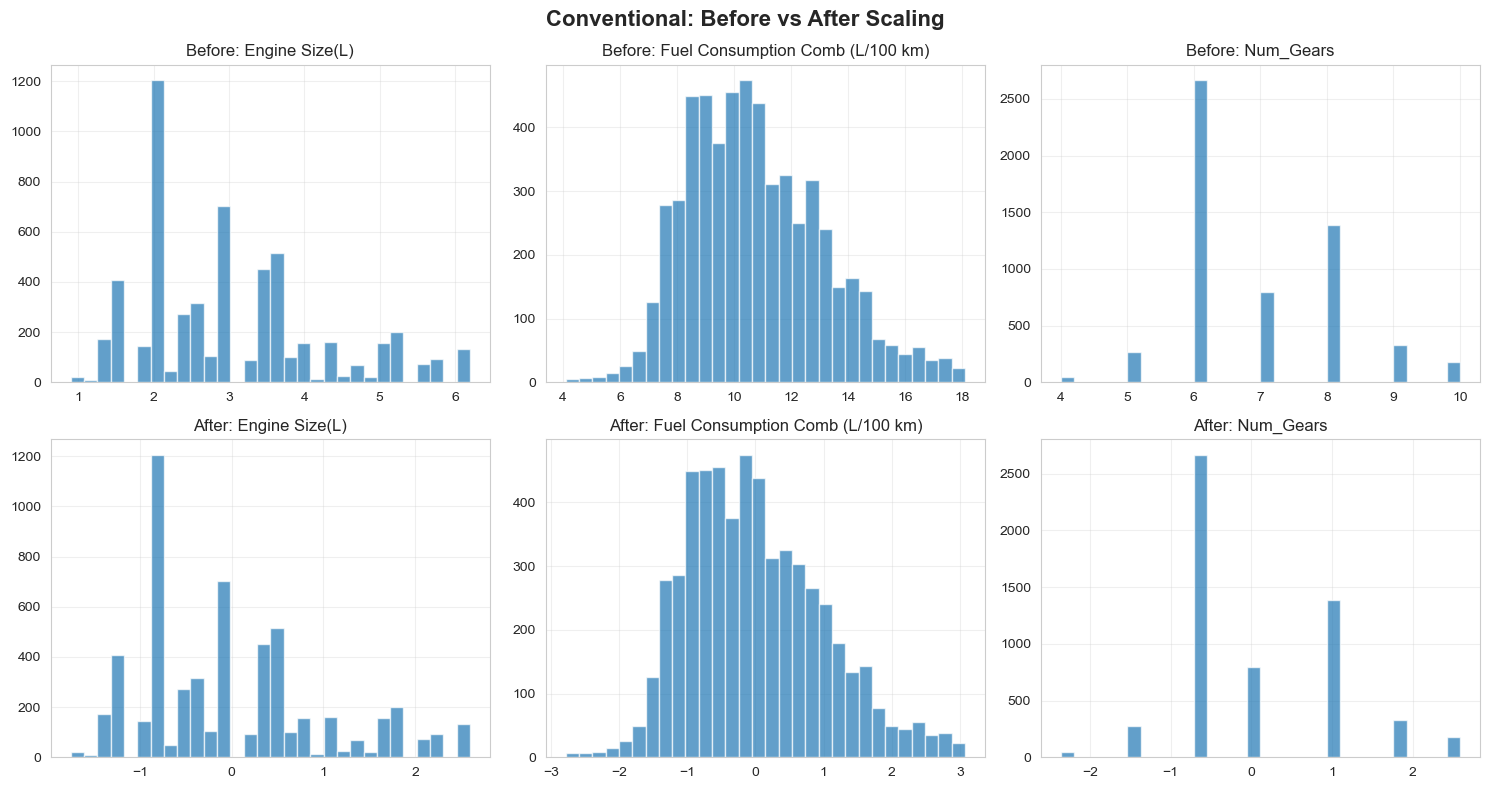


--- Electric ---
Before scaling: shape=(416, 4)

Sample statistics before scaling:


,Energy Consumption Comb (Le/100km),Electric Range (km),Is_SUV,Is_Truck
count,416.000000,416.000000,416.000000,416.000000
mean,2.704087,475.086538,0.562500,0.139423
std,0.547201,83.127959,0.496676,0.346805
min,1.600000,227.000000,0.000000,0.000000
25%,2.300000,423.000000,0.000000,0.000000
50%,2.700000,467.500000,1.000000,0.000000
75%,3.000000,512.000000,1.000000,0.000000
max,5.300000,824.000000,1.000000,1.000000



✓ Scaling completed
Mean (should be ~0): -0.0000000000
Std (should be ~1): 1.0012


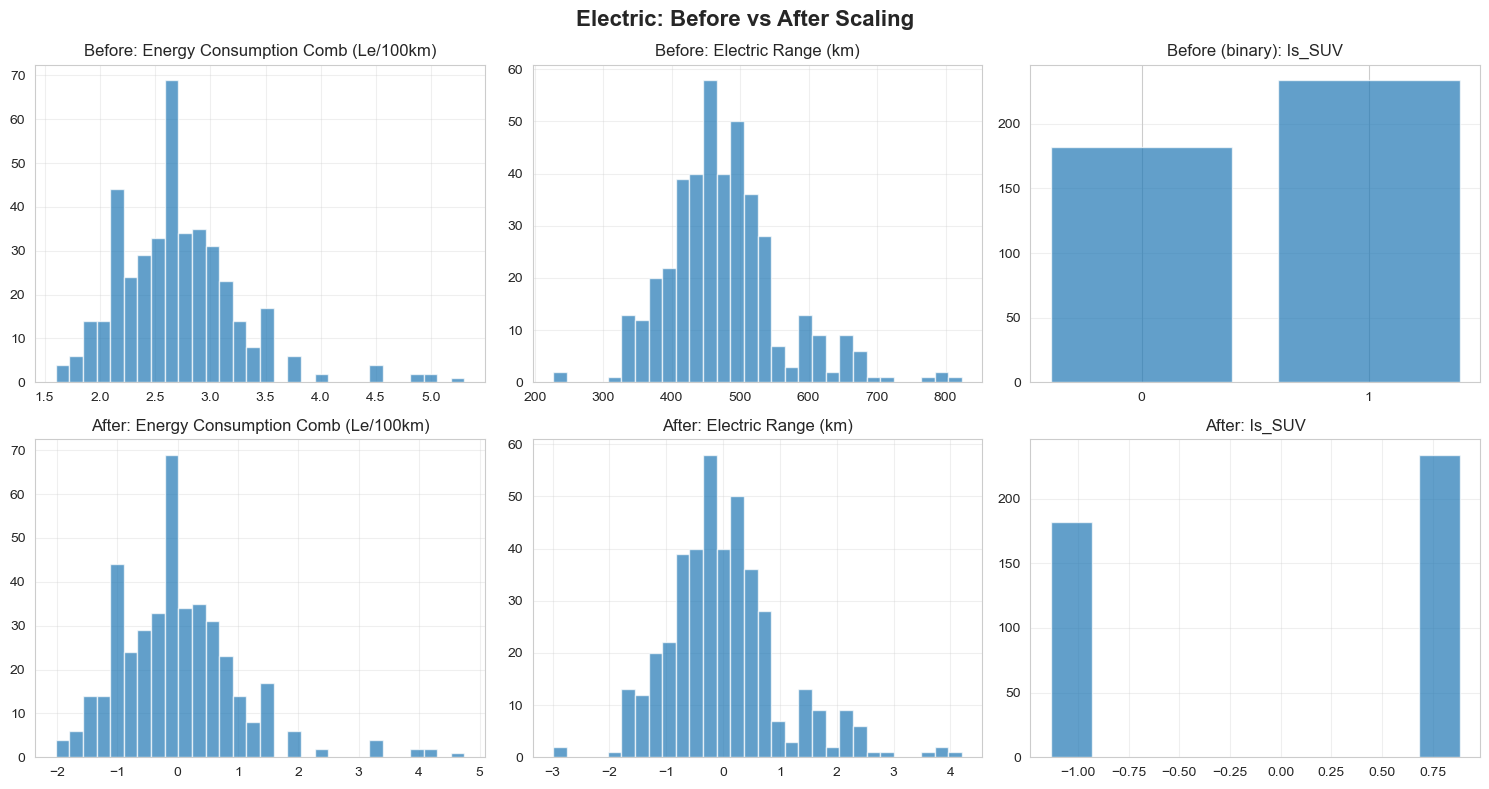


--- Plug-in Hybrid ---
Before scaling: shape=(58, 2)

Sample statistics before scaling:


,Fuel Consumption Comb (L/100 km),Fuel_B / X
count,58.000000,58.000000
mean,9.165517,0.362069
std,3.048529,0.484796
min,4.500000,0.000000
25%,6.900000,0.000000
50%,9.050000,0.000000
75%,10.575000,1.000000
max,17.200000,1.000000



✓ Scaling completed
Mean (should be ~0): -0.0000000000
Std (should be ~1): 1.0087


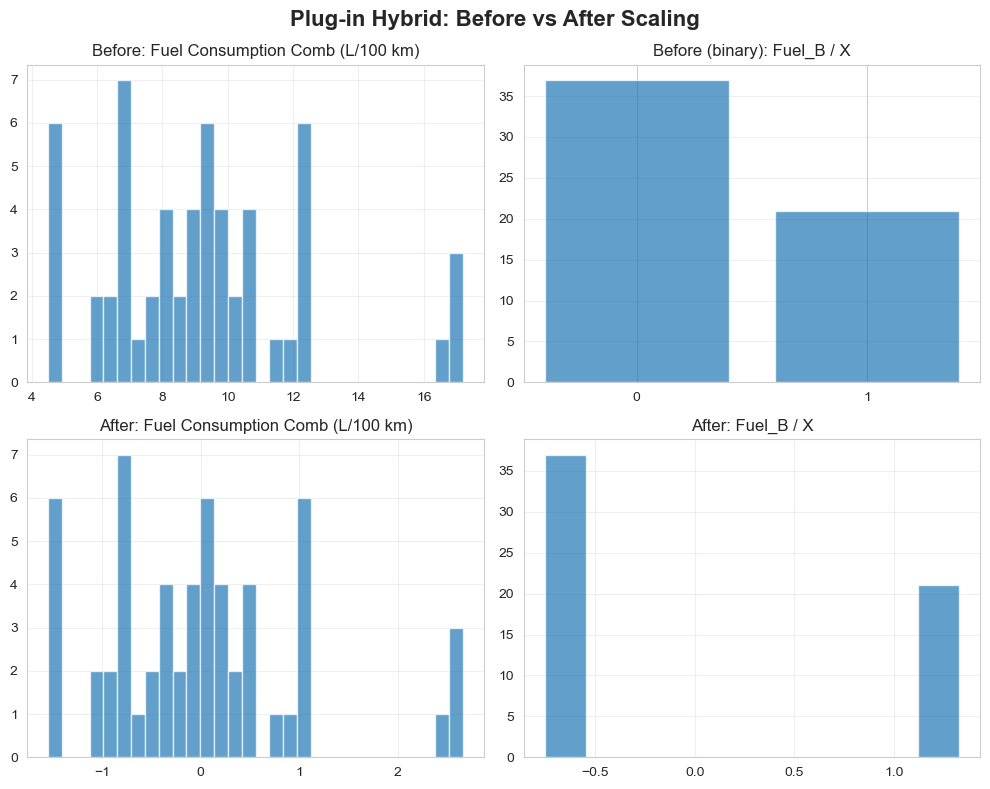


FINAL SCALED MATRICES
X_conv_scaled: (5670, 11)
X_ev_scaled:   (416, 4)
X_phev_scaled: (58, 2)


In [18]:
#Standardize features using StandardScaler.
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype

print("="*80)
print("FEATURE STANDARDIZATION (BY VEHICLE TYPE) - FIX BooleanDtype")
print("="*80)

def scale_features(X, name):
    print(f"\n--- {name} ---")
    print(f"Before scaling: shape={X.shape}")

    X_num = X.copy()

    # 1) Convert pandas nullable boolean ("boolean") and bool to int (preserve NA)
    for c in X_num.columns:
        if str(X_num[c].dtype).lower() in ["bool", "boolean"]:
            # if there are NAs, keep them as NaN after conversion (astype('Int64') then to float)
            X_num[c] = X_num[c].astype("Int64").astype(float)

    # 2) Ensure all columns are numeric; try coercion if not
    non_numeric = []
    for c in X_num.columns:
        if not is_numeric_dtype(X_num[c]):
            # try coercion
            X_num[c] = pd.to_numeric(X_num[c], errors="coerce")
            if X_num[c].isna().all():
                non_numeric.append(c)

    if non_numeric:
        raise TypeError(f"{name}: Columns could not be converted to numeric: {non_numeric}")

    # (Optional) drop any remaining NA rows just in case
    # Ideally your X_*_sel already had dropna, but keep it safe:
    X_num = X_num.dropna()

    print("\nSample statistics before scaling:")
    display(X_num.describe())

    # 3) Fit scaler
    scaler = StandardScaler()
    X_scaled_array = scaler.fit_transform(X_num)

    # 4) Back to DataFrame
    X_scaled = pd.DataFrame(X_scaled_array, columns=X_num.columns, index=X_num.index)

    print("\n✓ Scaling completed")
    print(f"Mean (should be ~0): {X_scaled.mean().mean():.10f}")
    print(f"Std (should be ~1): {X_scaled.std().mean():.4f}")

    # 5) Plot first 3 features safely
    n_plot = min(3, X_num.shape[1])
    fig, axes = plt.subplots(2, n_plot, figsize=(5*n_plot, 8))
    fig.suptitle(f'{name}: Before vs After Scaling', fontsize=16, fontweight='bold')

    for i in range(n_plot):
        feat = X_num.columns[i]
        vals = X_num[feat].dropna()

        # binary check
        uniq = vals.unique()
        if len(uniq) <= 2 and set(uniq).issubset({0, 1}):
            counts = vals.value_counts().reindex([0, 1], fill_value=0)
            axes[0, i].bar(["0", "1"], counts.values, alpha=0.7)
            axes[0, i].set_title(f'Before (binary): {feat}')
            axes[0, i].grid(True, alpha=0.3, axis="y")

            axes[1, i].hist(X_scaled[feat], bins=10, alpha=0.7)
            axes[1, i].set_title(f'After: {feat}')
            axes[1, i].grid(True, alpha=0.3)
        else:
            axes[0, i].hist(vals, bins=30, alpha=0.7)
            axes[0, i].set_title(f'Before: {feat}')
            axes[0, i].grid(True, alpha=0.3)

            axes[1, i].hist(X_scaled[feat], bins=30, alpha=0.7)
            axes[1, i].set_title(f'After: {feat}')
            axes[1, i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return scaler, X_scaled

# Run scaling (use your *_sel matrices)
scaler_conv, X_conv_scaled = scale_features(X_conv_sel, "Conventional")
scaler_ev, X_ev_scaled = scale_features(X_ev_sel, "Electric")
scaler_phev, X_phev_scaled = scale_features(X_phev_sel, "Plug-in Hybrid")

print("\n" + "="*80)
print("FINAL SCALED MATRICES")
print("="*80)
print("X_conv_scaled:", X_conv_scaled.shape)
print("X_ev_scaled:  ", X_ev_scaled.shape)
print("X_phev_scaled:", X_phev_scaled.shape)


PRINCIPAL COMPONENT ANALYSIS (BY VEHICLE TYPE)

--- Conventional ---

Total features: 11
Components for 80% variance: 6
Components for 90% variance: 7
Components for 95% variance: 8

Variance explained:
PC1: 26.56% (Cumulative: 26.56%)
PC2: 19.37% (Cumulative: 45.93%)
PC3: 12.07% (Cumulative: 58.00%)
PC4: 11.04% (Cumulative: 69.04%)
PC5: 9.86% (Cumulative: 78.90%)
PC6: 7.93% (Cumulative: 86.83%)
PC7: 5.75% (Cumulative: 92.58%)
PC8: 4.81% (Cumulative: 97.39%)
PC9: 2.27% (Cumulative: 99.66%)
PC10: 0.34% (Cumulative: 100.00%)


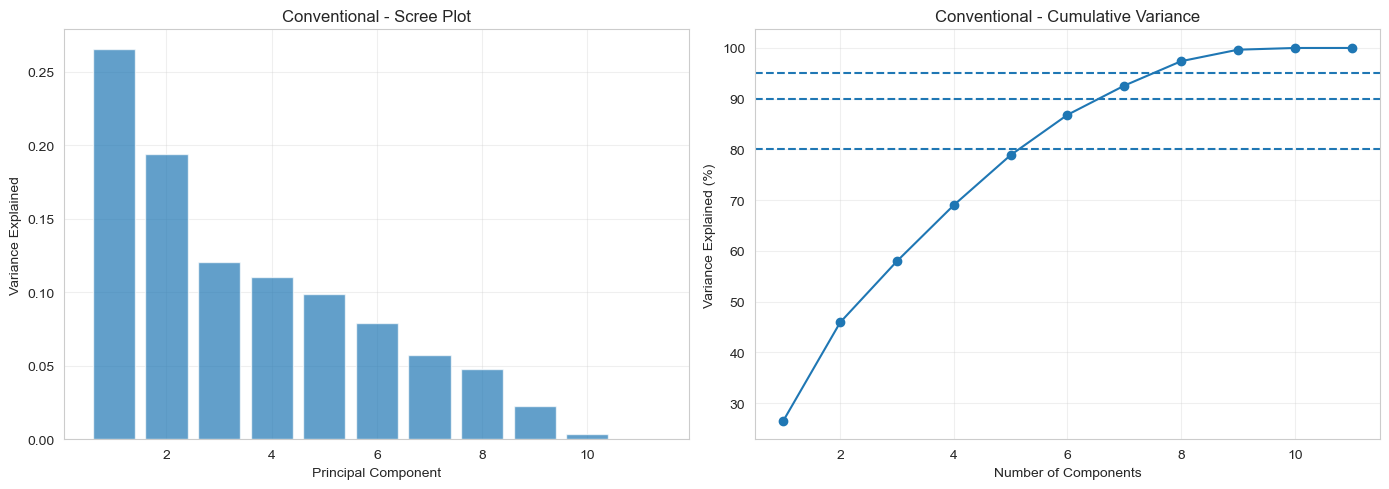


--- Electric ---

Total features: 4
Components for 80% variance: 3
Components for 90% variance: 3
Components for 95% variance: 4

Variance explained:
PC1: 46.31% (Cumulative: 46.31%)
PC2: 24.86% (Cumulative: 71.18%)
PC3: 20.16% (Cumulative: 91.34%)
PC4: 8.66% (Cumulative: 100.00%)


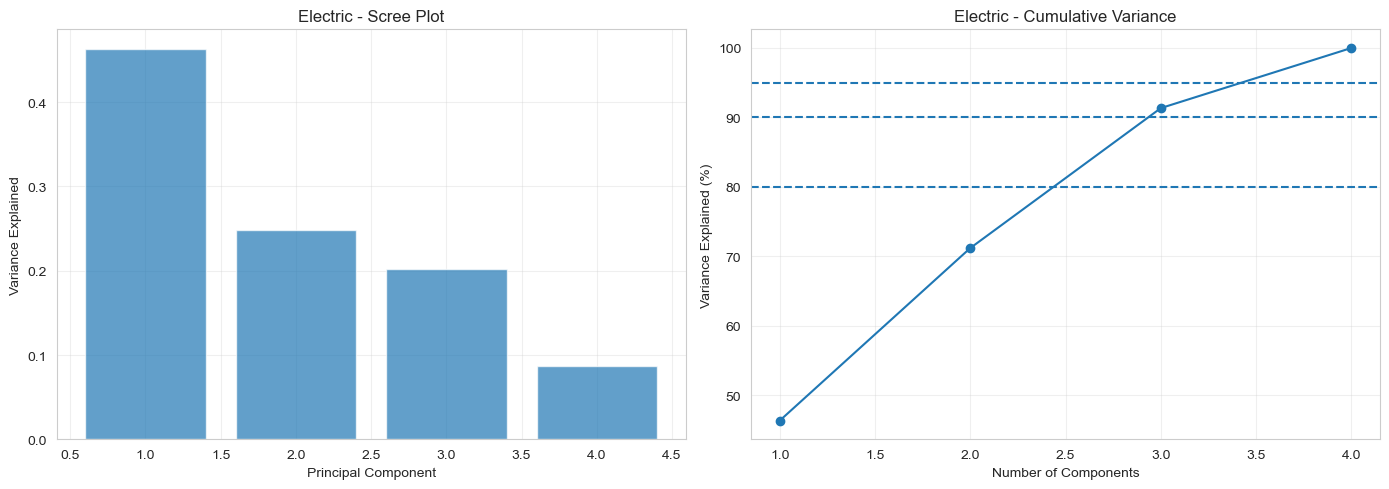


--- Plug-in Hybrid ---

Total features: 2
Components for 80% variance: 2
Components for 90% variance: 2
Components for 95% variance: 2

Variance explained:
PC1: 78.30% (Cumulative: 78.30%)
PC2: 21.70% (Cumulative: 100.00%)


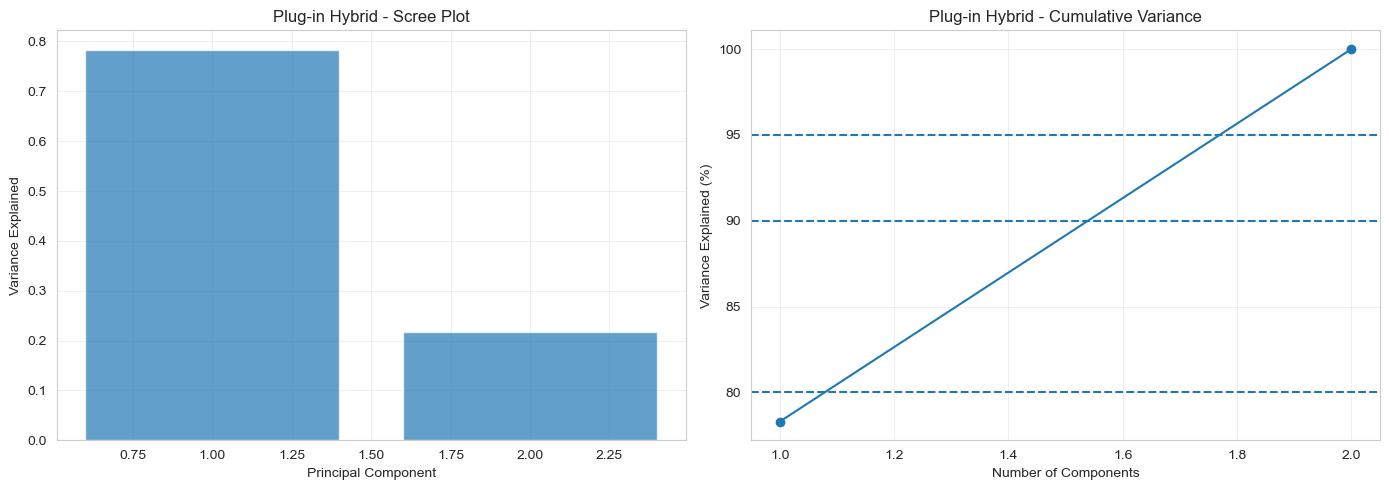

In [19]:
#Perform PCA to understand feature variance and dimensionality.

from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

print("="*80)
print("PRINCIPAL COMPONENT ANALYSIS (BY VEHICLE TYPE)")
print("="*80)


def run_pca_analysis(X_scaled, name):
    print(f"\n--- {name} ---")

    n_features = X_scaled.shape[1]

    pca = PCA()
    pca.fit(X_scaled)

    explained = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)

    # find thresholds
    n80 = np.argmax(cumulative >= 0.80) + 1
    n90 = np.argmax(cumulative >= 0.90) + 1
    n95 = np.argmax(cumulative >= 0.95) + 1

    print(f"\nTotal features: {n_features}")
    print(f"Components for 80% variance: {n80}")
    print(f"Components for 90% variance: {n90}")
    print(f"Components for 95% variance: {n95}")

    print("\nVariance explained:")
    for i in range(min(n_features, 10)):
        print(f"PC{i+1}: {explained[i]*100:.2f}% "
              f"(Cumulative: {cumulative[i]*100:.2f}%)")

    # Scree plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(
        range(1, n_features + 1),
        explained,
        alpha=0.7
    )
    axes[0].set_title(f"{name} - Scree Plot")
    axes[0].set_xlabel("Principal Component")
    axes[0].set_ylabel("Variance Explained")
    axes[0].grid(True, alpha=0.3)

    # Cumulative
    axes[1].plot(
        range(1, n_features + 1),
        cumulative * 100,
        marker='o'
    )
    axes[1].axhline(80, linestyle='--')
    axes[1].axhline(90, linestyle='--')
    axes[1].axhline(95, linestyle='--')

    axes[1].set_title(f"{name} - Cumulative Variance")
    axes[1].set_xlabel("Number of Components")
    axes[1].set_ylabel("Variance Explained (%)")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "n_features": n_features,
        "n80": n80,
        "n90": n90,
        "n95": n95,
        "explained": explained,
        "cumulative": cumulative
    }


# Run PCA for each vehicle type
pca_conv = run_pca_analysis(X_conv_scaled, "Conventional")
pca_ev   = run_pca_analysis(X_ev_scaled,   "Electric")
pca_phev = run_pca_analysis(X_phev_scaled, "Plug-in Hybrid")


DETERMINING OPTIMAL NUMBER OF CLUSTERS (BY VEHICLE TYPE)

--- Conventional ---
X shape: (5670, 11)
Testing K-Means with k from 2 to 10...

  k=2: Silhouette=0.239 | Davies-Bouldin=1.863 | Calinski-Harabasz=1333.0
  k=3: Silhouette=0.273 | Davies-Bouldin=1.611 | Calinski-Harabasz=1351.5
  k=4: Silhouette=0.296 | Davies-Bouldin=1.323 | Calinski-Harabasz=1371.2
  k=5: Silhouette=0.302 | Davies-Bouldin=1.200 | Calinski-Harabasz=1472.2
  k=6: Silhouette=0.343 | Davies-Bouldin=1.058 | Calinski-Harabasz=1574.1
  k=7: Silhouette=0.310 | Davies-Bouldin=1.150 | Calinski-Harabasz=1667.7
  k=8: Silhouette=0.331 | Davies-Bouldin=1.057 | Calinski-Harabasz=1717.7
  k=9: Silhouette=0.360 | Davies-Bouldin=1.017 | Calinski-Harabasz=1743.0
  k=10: Silhouette=0.359 | Davies-Bouldin=1.002 | Calinski-Harabasz=1725.1

Conventional — OPTIMAL CLUSTER RECOMMENDATIONS
Based on Silhouette (higher better): k=9 (score=0.360)
Based on Davies-Bouldin (lower better): k=10 (score=1.002)
Based on Calinski-Harabasz (high

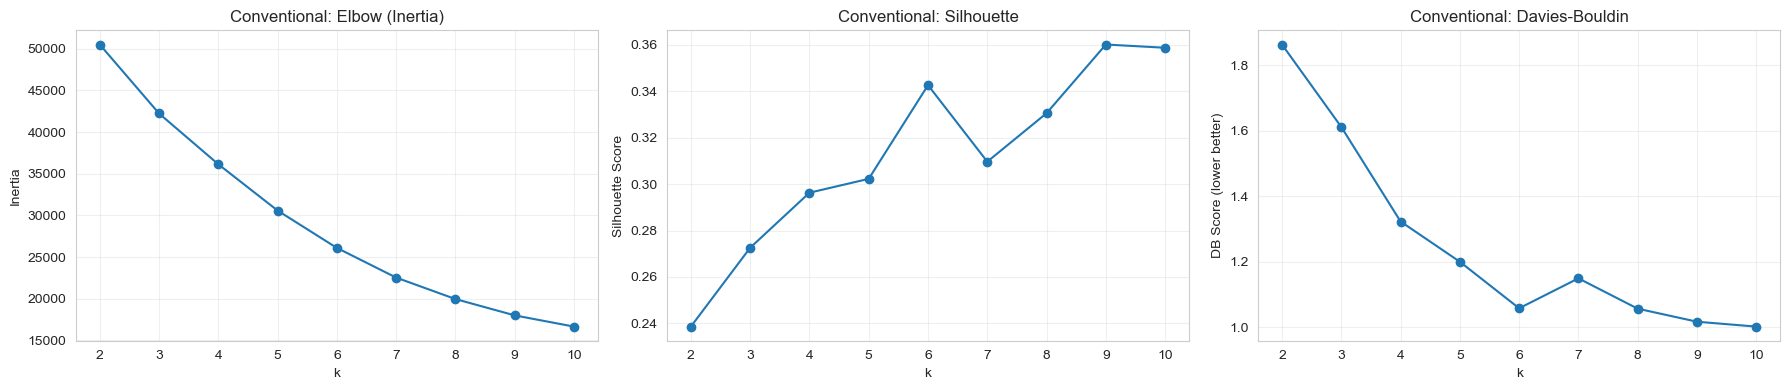


--- Electric ---
X shape: (416, 4)
Testing K-Means with k from 2 to 8...

  k=2: Silhouette=0.523 | Davies-Bouldin=0.759 | Calinski-Harabasz=262.5
  k=3: Silhouette=0.463 | Davies-Bouldin=0.904 | Calinski-Harabasz=298.6
  k=4: Silhouette=0.457 | Davies-Bouldin=0.744 | Calinski-Harabasz=264.9
  k=5: Silhouette=0.396 | Davies-Bouldin=0.897 | Calinski-Harabasz=270.1
  k=6: Silhouette=0.407 | Davies-Bouldin=0.875 | Calinski-Harabasz=269.2
  k=7: Silhouette=0.402 | Davies-Bouldin=0.867 | Calinski-Harabasz=275.1
  k=8: Silhouette=0.404 | Davies-Bouldin=0.823 | Calinski-Harabasz=283.6

Electric — OPTIMAL CLUSTER RECOMMENDATIONS
Based on Silhouette (higher better): k=2 (score=0.523)
Based on Davies-Bouldin (lower better): k=4 (score=0.744)
Based on Calinski-Harabasz (higher better): k=3 (score=298.6)

💡 Practical recommendation: start with k=2 (Silhouette), then sanity-check with elbow + interpretability.


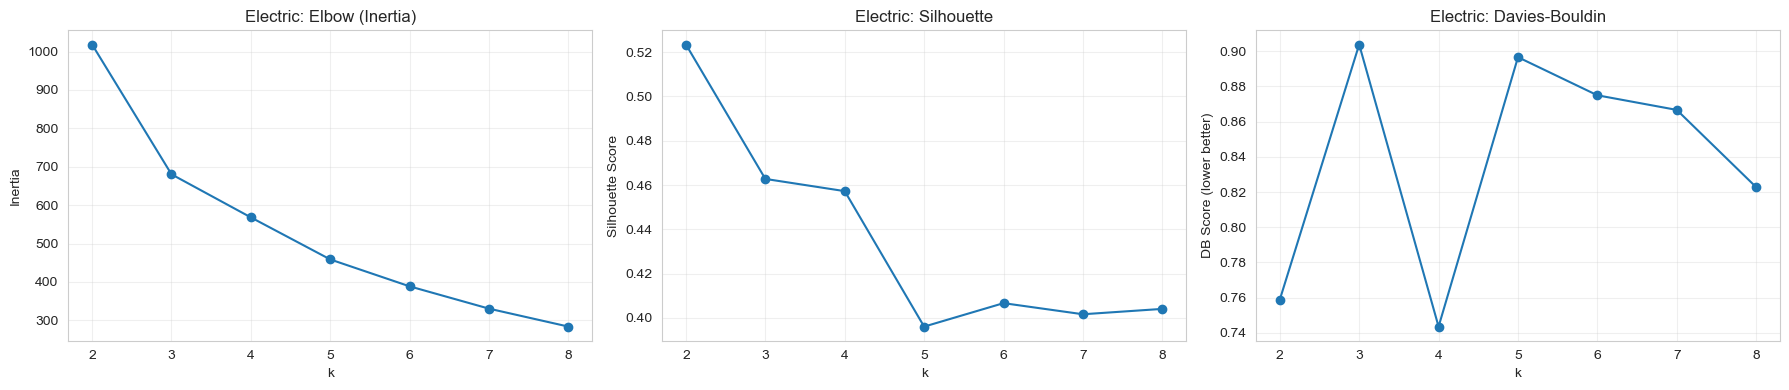


--- Plug-in Hybrid ---
X shape: (58, 2)
Testing K-Means with k from 2 to 4...

  k=2: Silhouette=0.653 | Davies-Bouldin=0.492 | Calinski-Harabasz=108.8
  k=3: Silhouette=0.696 | Davies-Bouldin=0.351 | Calinski-Harabasz=141.6
  k=4: Silhouette=0.613 | Davies-Bouldin=0.475 | Calinski-Harabasz=156.4

Plug-in Hybrid — OPTIMAL CLUSTER RECOMMENDATIONS
Based on Silhouette (higher better): k=3 (score=0.696)
Based on Davies-Bouldin (lower better): k=3 (score=0.351)
Based on Calinski-Harabasz (higher better): k=4 (score=156.4)

💡 Practical recommendation: start with k=3 (Silhouette), then sanity-check with elbow + interpretability.


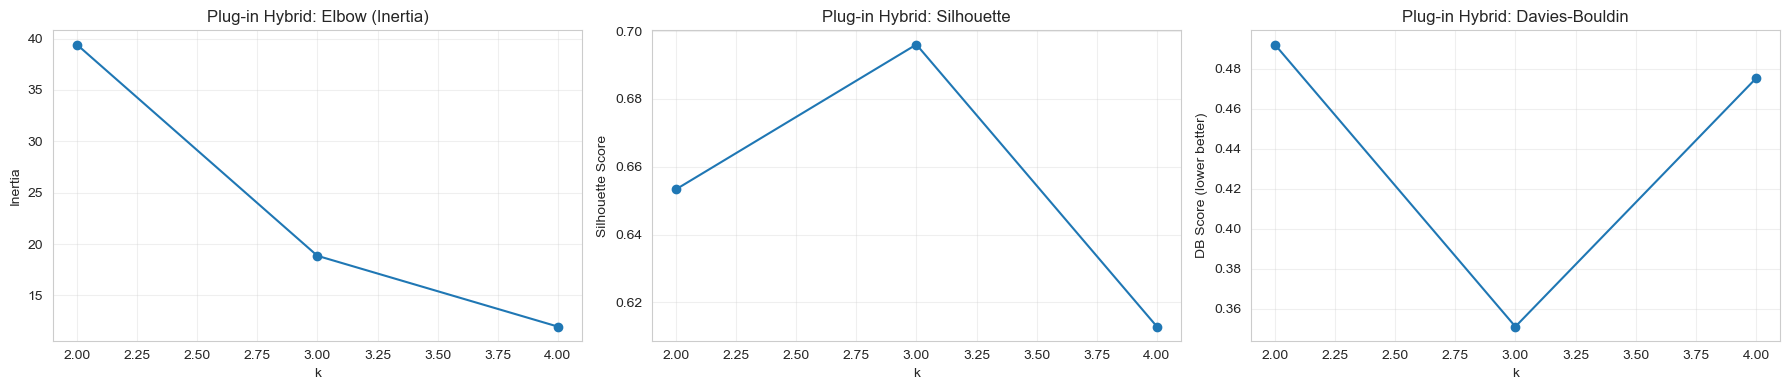

In [20]:
#Use multiple metrics to determine the optimal number of clusters.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("="*80)
print("DETERMINING OPTIMAL NUMBER OF CLUSTERS (BY VEHICLE TYPE)")
print("="*80)

def evaluate_kmeans_k(X_df, name, max_clusters=10, random_state=42):
    """
    Evaluate KMeans for k=2..max_clusters using:
    - inertia (Elbow)
    - silhouette (higher better)
    - Davies-Bouldin (lower better)
    - Calinski-Harabasz (higher better)
    """
    X = X_df.values
    n = X.shape[0]
    k_max_use = min(max_clusters, n - 1)

    if k_max_use < 2:
        print(f"\n{name}: Not enough samples for clustering (n={n}).")
        return None

    inertias = []
    silhouettes = []
    db_scores = []
    ch_scores = []

    print(f"\n--- {name} ---")
    print(f"X shape: {X_df.shape}")
    print(f"Testing K-Means with k from 2 to {k_max_use}...\n")

    ks = list(range(2, k_max_use + 1))
    for k in ks:
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=30)
        labels = kmeans.fit_predict(X)

        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(X, labels))
        db_scores.append(davies_bouldin_score(X, labels))
        ch_scores.append(calinski_harabasz_score(X, labels))

        print(f"  k={k}: Silhouette={silhouettes[-1]:.3f} | Davies-Bouldin={db_scores[-1]:.3f} | Calinski-Harabasz={ch_scores[-1]:.1f}")

    # best k by each metric
    optimal_k_sil = ks[int(np.argmax(silhouettes))]
    optimal_k_db  = ks[int(np.argmin(db_scores))]
    optimal_k_ch  = ks[int(np.argmax(ch_scores))]

    print(f"\n{'='*80}")
    print(f"{name} — OPTIMAL CLUSTER RECOMMENDATIONS")
    print(f"{'='*80}")
    print(f"Based on Silhouette (higher better): k={optimal_k_sil} (score={max(silhouettes):.3f})")
    print(f"Based on Davies-Bouldin (lower better): k={optimal_k_db} (score={min(db_scores):.3f})")
    print(f"Based on Calinski-Harabasz (higher better): k={optimal_k_ch} (score={max(ch_scores):.1f})")
    print(f"\n💡 Practical recommendation: start with k={optimal_k_sil} (Silhouette), then sanity-check with elbow + interpretability.")
    print(f"{'='*80}")

    # plots (optional but useful)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(ks, inertias, marker="o")
    axes[0].set_title(f"{name}: Elbow (Inertia)")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("Inertia")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(ks, silhouettes, marker="o")
    axes[1].set_title(f"{name}: Silhouette")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("Silhouette Score")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(ks, db_scores, marker="o")
    axes[2].set_title(f"{name}: Davies-Bouldin")
    axes[2].set_xlabel("k")
    axes[2].set_ylabel("DB Score (lower better)")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "name": name,
        "ks": ks,
        "inertias": inertias,
        "silhouettes": silhouettes,
        "db_scores": db_scores,
        "ch_scores": ch_scores,
        "optimal_k_silhouette": optimal_k_sil,
        "optimal_k_db": optimal_k_db,
        "optimal_k_ch": optimal_k_ch,
    }

# Use your scaled matrices (DataFrames)
# Conventional: allow up to 10
res_k_conv = evaluate_kmeans_k(X_conv_scaled, "Conventional", max_clusters=10)

# Electric: smaller, max 8 is enough
res_k_ev = evaluate_kmeans_k(X_ev_scaled, "Electric", max_clusters=8)

# PHEV: very small + only 2 features -> keep k very small
res_k_phev = evaluate_kmeans_k(X_phev_scaled, "Plug-in Hybrid", max_clusters=4)


The optimal number of clusters was determined using multiple clustering validity metrics, including the Silhouette Score, Davies–Bouldin Index, and Calinski–Harabasz Index. Although higher cluster numbers slightly improved mathematical performance for conventional vehicles, they resulted in overly fragmented and less interpretable market segments. Therefore, a balance between statistical validity and practical interpretability was applied. Based on this combined evaluation, the final number of clusters was selected as k = 5 for conventional vehicles, k = 3 for electric vehicles, and k = 3 for plug-in hybrid vehicles, ensuring meaningful and interpretable market segmentation.

Generating cluster optimization visualizations (by Vehicle Type)...


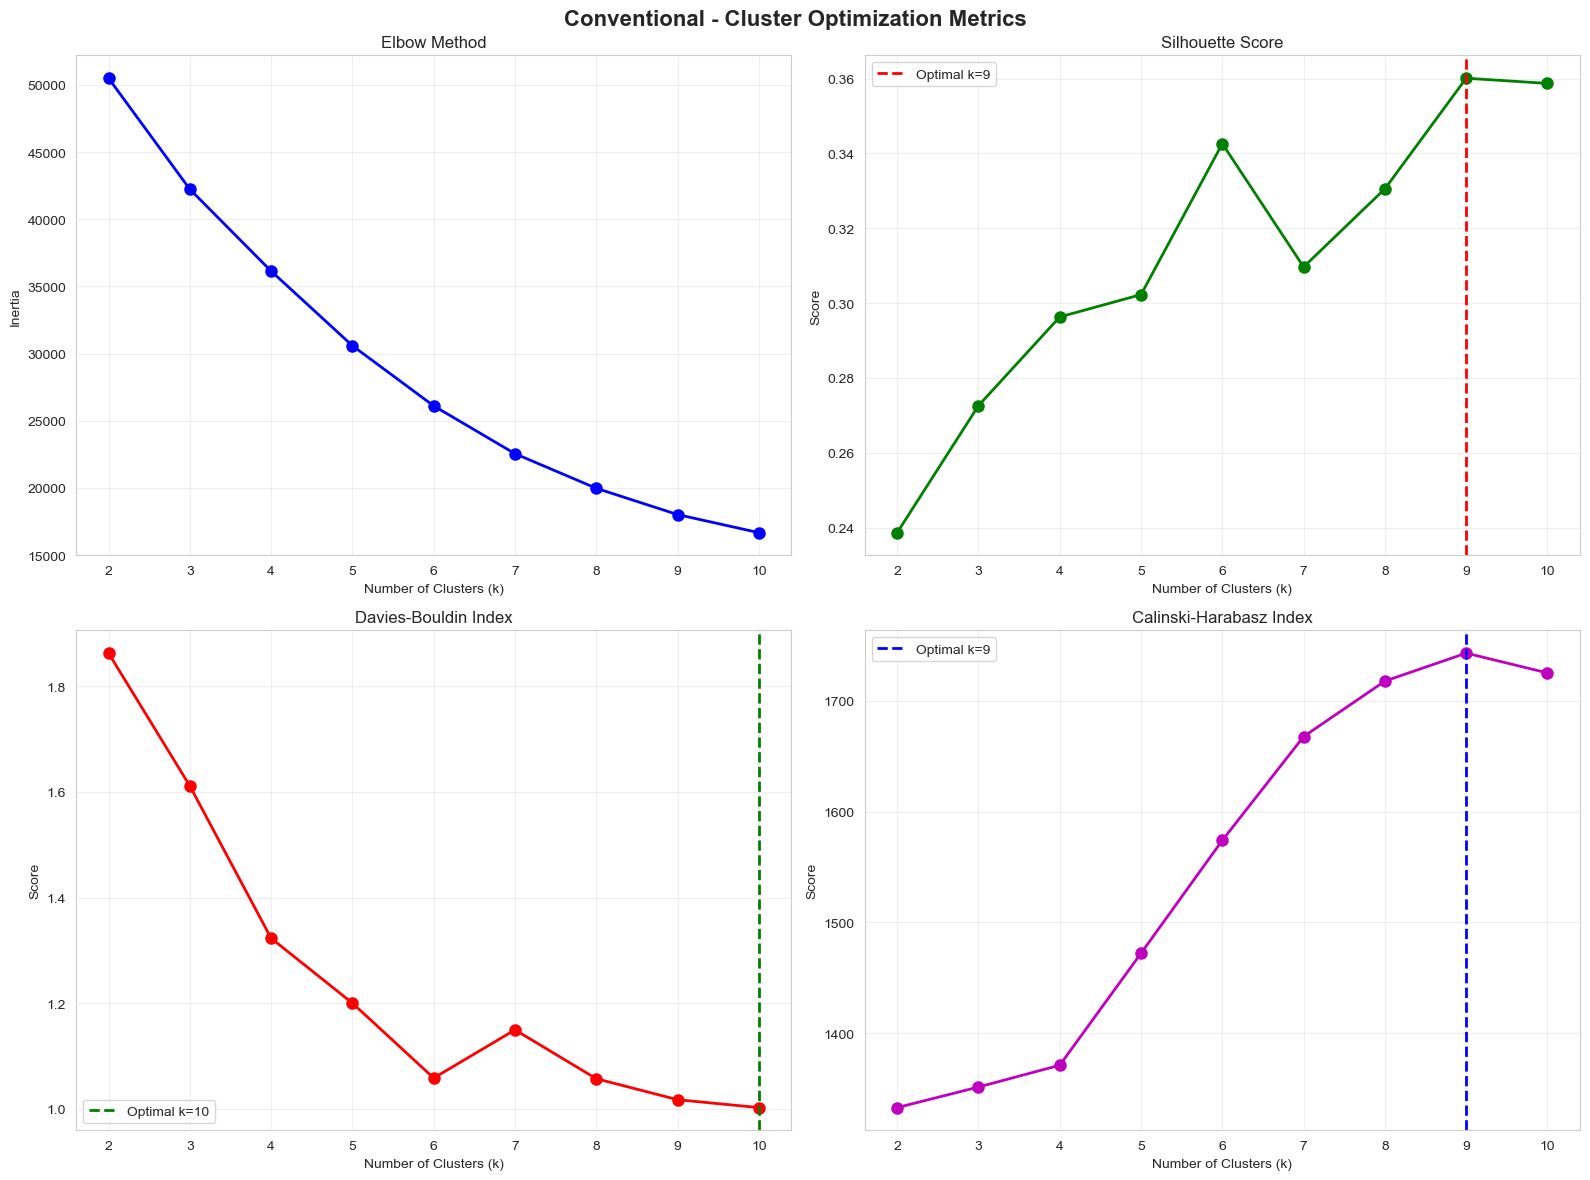

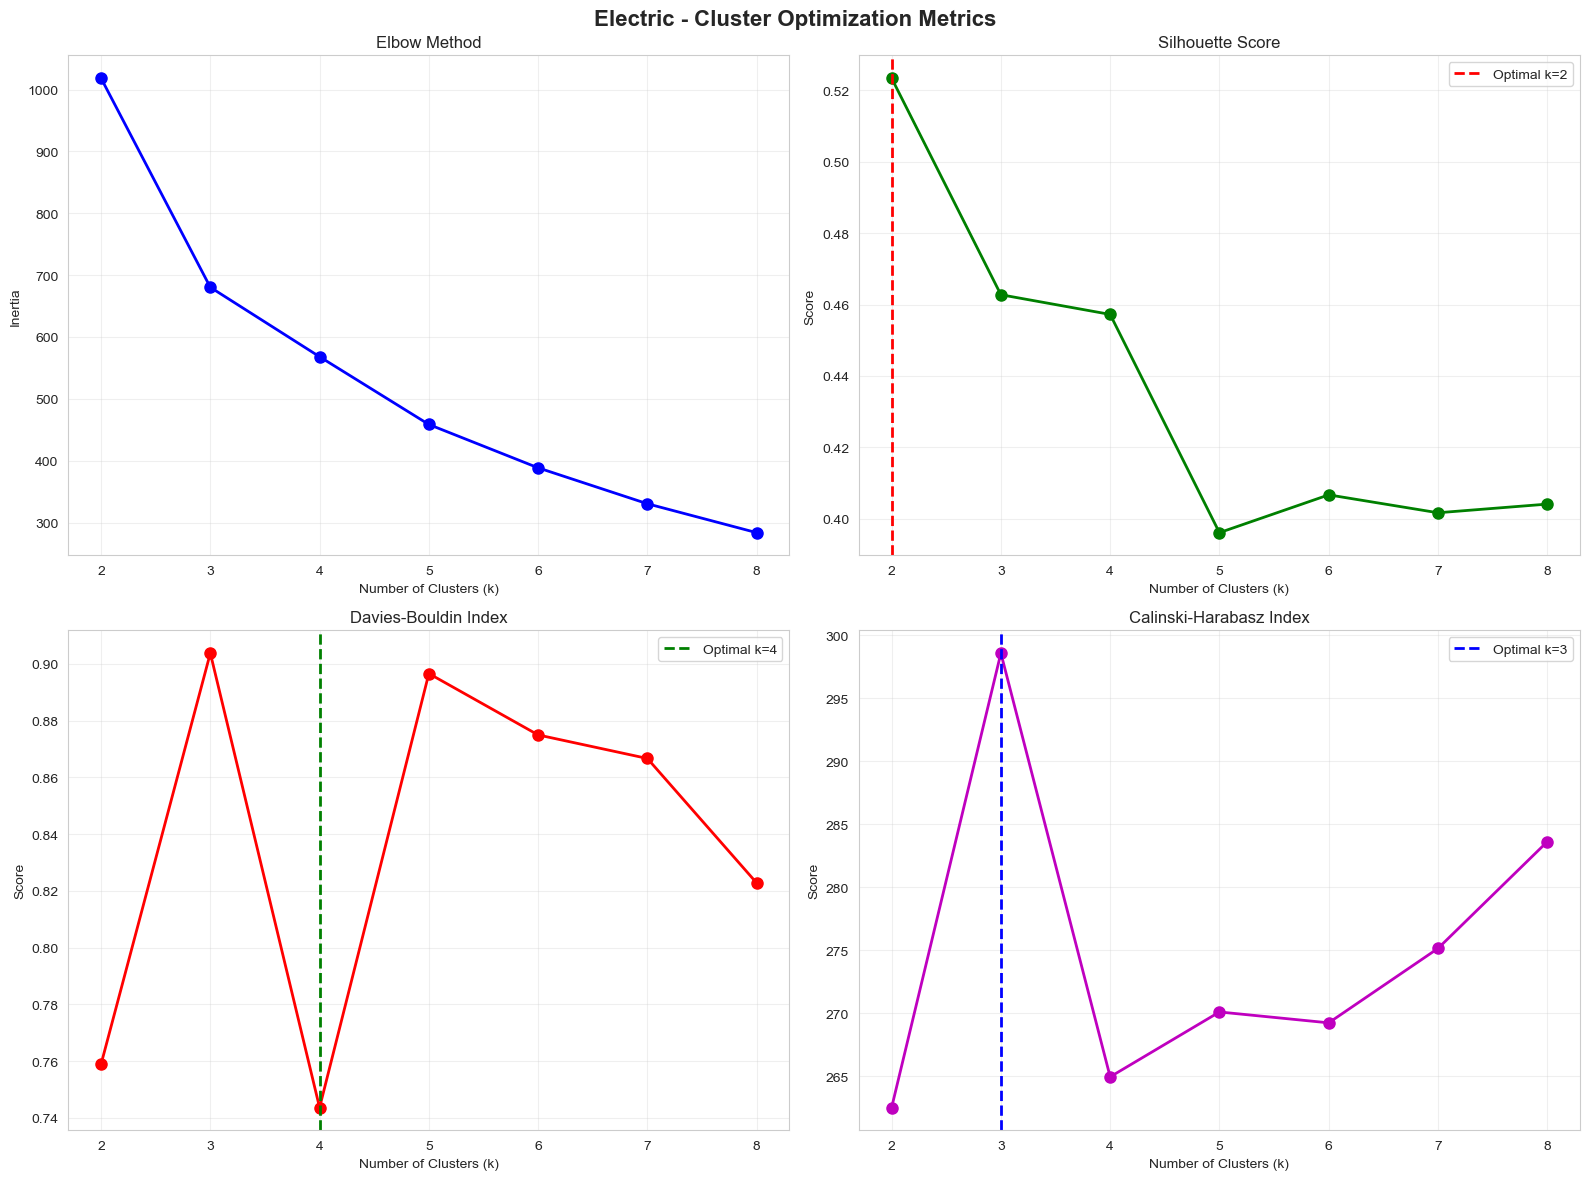

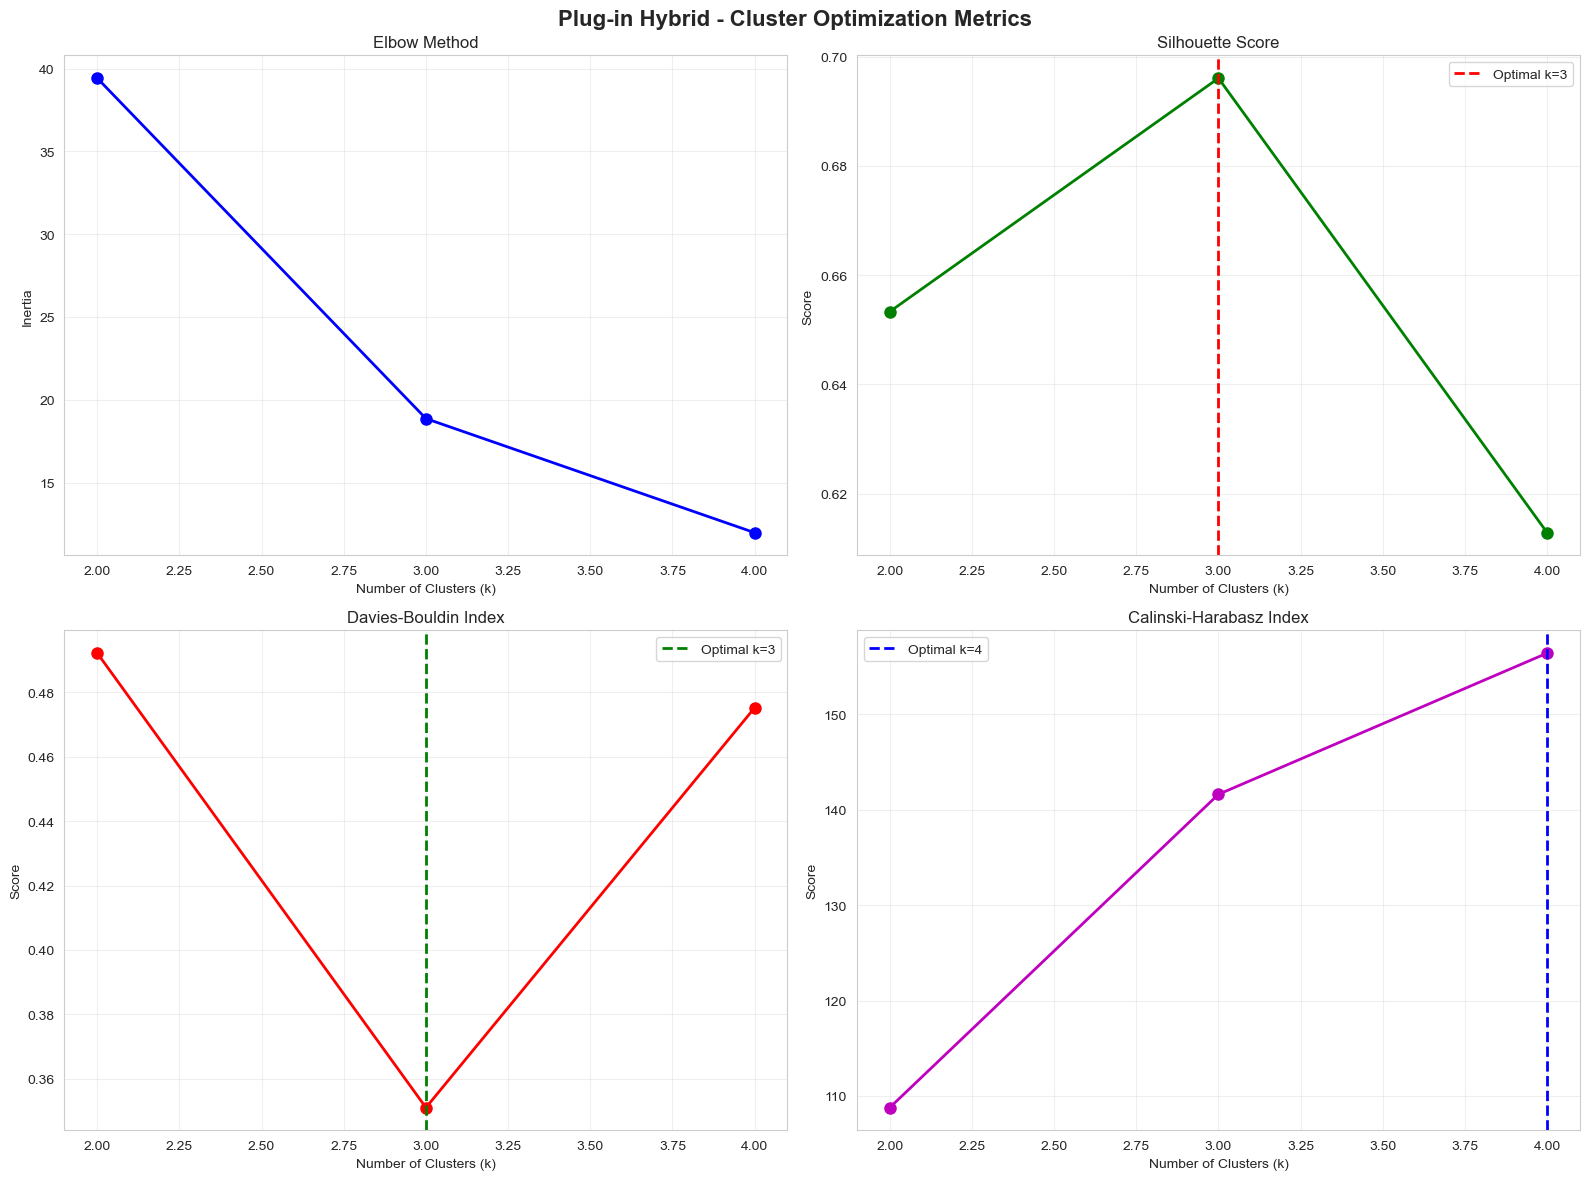

✓ Cluster optimization visualizations generated


In [21]:
#Visualize all metrics used to determine optimal clusters.
print("Generating cluster optimization visualizations (by Vehicle Type)...")

import matplotlib.pyplot as plt

def plot_cluster_metrics(res_dict):
    name = res_dict["name"]
    ks = res_dict["ks"]
    inertias = res_dict["inertias"]
    silhouettes = res_dict["silhouettes"]
    db_scores = res_dict["db_scores"]
    ch_scores = res_dict["ch_scores"]

    optimal_k_sil = res_dict["optimal_k_silhouette"]
    optimal_k_db  = res_dict["optimal_k_db"]
    optimal_k_ch  = res_dict["optimal_k_ch"]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{name} - Cluster Optimization Metrics', fontsize=16, fontweight='bold')

    # 1. Elbow
    axes[0, 0].plot(ks, inertias, 'bo-', linewidth=2, markersize=8)
    axes[0, 0].set_title('Elbow Method')
    axes[0, 0].set_xlabel('Number of Clusters (k)')
    axes[0, 0].set_ylabel('Inertia')
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Silhouette
    axes[0, 1].plot(ks, silhouettes, 'go-', linewidth=2, markersize=8)
    axes[0, 1].axvline(optimal_k_sil, color='red', linestyle='--', linewidth=2,
                       label=f'Optimal k={optimal_k_sil}')
    axes[0, 1].set_title('Silhouette Score')
    axes[0, 1].set_xlabel('Number of Clusters (k)')
    axes[0, 1].set_ylabel('Score')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Davies-Bouldin
    axes[1, 0].plot(ks, db_scores, 'ro-', linewidth=2, markersize=8)
    axes[1, 0].axvline(optimal_k_db, color='green', linestyle='--', linewidth=2,
                       label=f'Optimal k={optimal_k_db}')
    axes[1, 0].set_title('Davies-Bouldin Index')
    axes[1, 0].set_xlabel('Number of Clusters (k)')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Calinski-Harabasz
    axes[1, 1].plot(ks, ch_scores, 'mo-', linewidth=2, markersize=8)
    axes[1, 1].axvline(optimal_k_ch, color='blue', linestyle='--', linewidth=2,
                       label=f'Optimal k={optimal_k_ch}')
    axes[1, 1].set_title('Calinski-Harabasz Index')
    axes[1, 1].set_xlabel('Number of Clusters (k)')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot for each vehicle type
plot_cluster_metrics(res_k_conv)
plot_cluster_metrics(res_k_ev)
plot_cluster_metrics(res_k_phev)

print("✓ Cluster optimization visualizations generated")


In [22]:
#Fit the K-Means clustering model with optimal k.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("="*80)
print("FITTING K-MEANS CLUSTERING MODELS (BY VEHICLE TYPE)")
print("="*80)

def fit_kmeans_and_report(X_scaled_df, name, n_clusters, random_state=42):
    X = X_scaled_df.values

    print(f"\n--- {name} ---")
    print(f"Using k = {n_clusters} clusters")
    print(f"Fitting K-Means...")

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=50,
        max_iter=300
    )
    labels = kmeans.fit_predict(X)

    # Metrics
    sil = silhouette_score(X, labels) if n_clusters >= 2 else np.nan
    db  = davies_bouldin_score(X, labels) if n_clusters >= 2 else np.nan
    ch  = calinski_harabasz_score(X, labels) if n_clusters >= 2 else np.nan

    print(f"\n✓ K-Means clustering completed!")
    print(f"  Performance Metrics:")
    print(f"    Silhouette Score: {sil:.3f}")
    print(f"    Davies-Bouldin Index: {db:.3f}")
    print(f"    Calinski-Harabasz Score: {ch:.1f}")

    # Cluster distribution
    print(f"\n  Cluster Distribution:")
    counts = np.bincount(labels, minlength=n_clusters)
    for i, count in enumerate(counts):
        pct = (count / len(labels)) * 100
        print(f"    Cluster {i}: {count} vehicles ({pct:.1f}%)")

    print(f"\n  Cluster Centers Shape: {kmeans.cluster_centers_.shape}")
    print(f"  Total iterations: {kmeans.n_iter_}")

    return kmeans, labels

# ---- Use the final k values (market segmentation choice) ----
k_conv = 5
k_ev   = 3
k_phev = 3

kmeans_conv, labels_conv = fit_kmeans_and_report(X_conv_scaled, "Conventional", k_conv)
kmeans_ev,   labels_ev   = fit_kmeans_and_report(X_ev_scaled,   "Electric", k_ev)
kmeans_phev, labels_phev = fit_kmeans_and_report(X_phev_scaled, "Plug-in Hybrid", k_phev)

# Store labels if you want to use later
cluster_labels_conv = labels_conv
cluster_labels_ev   = labels_ev
cluster_labels_phev = labels_phev


FITTING K-MEANS CLUSTERING MODELS (BY VEHICLE TYPE)

--- Conventional ---
Using k = 5 clusters
Fitting K-Means...

✓ K-Means clustering completed!
  Performance Metrics:
    Silhouette Score: 0.327
    Davies-Bouldin Index: 1.107
    Calinski-Harabasz Score: 1486.1

  Cluster Distribution:
    Cluster 0: 2504 vehicles (44.2%)
    Cluster 1: 2120 vehicles (37.4%)
    Cluster 2: 147 vehicles (2.6%)
    Cluster 3: 676 vehicles (11.9%)
    Cluster 4: 223 vehicles (3.9%)

  Cluster Centers Shape: (5, 11)
  Total iterations: 4

--- Electric ---
Using k = 3 clusters
Fitting K-Means...

✓ K-Means clustering completed!
  Performance Metrics:
    Silhouette Score: 0.463
    Davies-Bouldin Index: 0.904
    Calinski-Harabasz Score: 298.6

  Cluster Distribution:
    Cluster 0: 234 vehicles (56.2%)
    Cluster 1: 58 vehicles (13.9%)
    Cluster 2: 124 vehicles (29.8%)

  Cluster Centers Shape: (3, 4)
  Total iterations: 3

--- Plug-in Hybrid ---
Using k = 3 clusters
Fitting K-Means...

✓ K-Means cl

In [23]:
#Fit Hierarchical clustering for comparison.

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("="*80)
print("HIERARCHICAL CLUSTERING (BY VEHICLE TYPE) + MODEL COMPARISON")
print("="*80)

def fit_hierarchical_and_compare(X_scaled_df, name, n_clusters, kmeans_labels):
    """
    Fit Agglomerative clustering (Ward) and compare vs existing KMeans labels
    using Silhouette, Davies-Bouldin, Calinski-Harabasz.
    """
    X = X_scaled_df.values

    print(f"\n--- {name} ---")
    print(f"Fitting Hierarchical Clustering (ward) with k = {n_clusters}...")

    # Fit Hierarchical
    hierarchical = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    h_labels = hierarchical.fit_predict(X)

    # Metrics for Hierarchical
    h_sil = silhouette_score(X, h_labels)
    h_db  = davies_bouldin_score(X, h_labels)
    h_ch  = calinski_harabasz_score(X, h_labels)

    print("\n✓ Hierarchical clustering completed!")
    print("  Hierarchical Metrics:")
    print(f"    Silhouette Score: {h_sil:.3f}")
    print(f"    Davies-Bouldin Index: {h_db:.3f}")
    print(f"    Calinski-Harabasz Score: {h_ch:.1f}")

    print("\n  Hierarchical Cluster Distribution:")
    h_counts = np.bincount(h_labels, minlength=n_clusters)
    for i, count in enumerate(h_counts):
        pct = count / len(h_labels) * 100
        print(f"    Cluster {i}: {count} vehicles ({pct:.1f}%)")

    # Metrics for KMeans (from labels you already have)
    km_sil = silhouette_score(X, kmeans_labels)
    km_db  = davies_bouldin_score(X, kmeans_labels)
    km_ch  = calinski_harabasz_score(X, kmeans_labels)

    # Comparison table
    comparison_df = pd.DataFrame({
        "Metric": ["Silhouette Score (↑)", "Davies-Bouldin (↓)", "Calinski-Harabasz (↑)"],
        "K-Means": [km_sil, km_db, km_ch],
        "Hierarchical": [h_sil, h_db, h_ch],
        "Better Model": [
            "K-Means" if km_sil > h_sil else "Hierarchical",
            "K-Means" if km_db < h_db else "Hierarchical",
            "K-Means" if km_ch > h_ch else "Hierarchical",
        ]
    })

    print(f"\n{'='*80}")
    print(f"{name} — MODEL COMPARISON")
    print(f"{'='*80}")
    display(comparison_df)

    # Choose "best" by silhouette (simple, standard)
    if km_sil >= h_sil:
        best_model = "K-Means"
        best_labels = kmeans_labels
        best_score = km_sil
    else:
        best_model = "Hierarchical"
        best_labels = h_labels
        best_score = h_sil

    print(f"\n✓ BEST MODEL (by Silhouette): {best_model} (Silhouette = {best_score:.3f})")

    return {
        "name": name,
        "hierarchical_model": hierarchical,
        "hierarchical_labels": h_labels,
        "comparison_df": comparison_df,
        "best_model": best_model,
        "best_labels": best_labels
    }


# Use the SAME k as your KMeans for fair comparison
res_h_conv = fit_hierarchical_and_compare(X_conv_scaled, "Conventional", n_clusters=5, kmeans_labels=labels_conv)
res_h_ev   = fit_hierarchical_and_compare(X_ev_scaled,   "Electric",     n_clusters=3, kmeans_labels=labels_ev)
res_h_phev = fit_hierarchical_and_compare(X_phev_scaled, "Plug-in Hybrid",n_clusters=3, kmeans_labels=labels_phev)


HIERARCHICAL CLUSTERING (BY VEHICLE TYPE) + MODEL COMPARISON

--- Conventional ---
Fitting Hierarchical Clustering (ward) with k = 5...

✓ Hierarchical clustering completed!
  Hierarchical Metrics:
    Silhouette Score: 0.335
    Davies-Bouldin Index: 1.082
    Calinski-Harabasz Score: 1478.7

  Hierarchical Cluster Distribution:
    Cluster 0: 2265 vehicles (39.9%)
    Cluster 1: 2504 vehicles (44.2%)
    Cluster 2: 531 vehicles (9.4%)
    Cluster 3: 147 vehicles (2.6%)
    Cluster 4: 223 vehicles (3.9%)

Conventional — MODEL COMPARISON


,Metric,K-Means,Hierarchical,Better Model
0,Silhouette Score (↑),0.327149,0.335069,Hierarchical
1,Davies-Bouldin (↓),1.106831,1.081989,Hierarchical
2,Calinski-Harabasz (↑),1486.128023,1478.690358,K-Means



✓ BEST MODEL (by Silhouette): Hierarchical (Silhouette = 0.335)

--- Electric ---
Fitting Hierarchical Clustering (ward) with k = 3...

✓ Hierarchical clustering completed!
  Hierarchical Metrics:
    Silhouette Score: 0.461
    Davies-Bouldin Index: 0.923
    Calinski-Harabasz Score: 286.5

  Hierarchical Cluster Distribution:
    Cluster 0: 124 vehicles (29.8%)
    Cluster 1: 63 vehicles (15.1%)
    Cluster 2: 229 vehicles (55.0%)

Electric — MODEL COMPARISON


,Metric,K-Means,Hierarchical,Better Model
0,Silhouette Score (↑),0.462753,0.460694,K-Means
1,Davies-Bouldin (↓),0.903743,0.922519,K-Means
2,Calinski-Harabasz (↑),298.591280,286.531065,K-Means



✓ BEST MODEL (by Silhouette): K-Means (Silhouette = 0.463)

--- Plug-in Hybrid ---
Fitting Hierarchical Clustering (ward) with k = 3...

✓ Hierarchical clustering completed!
  Hierarchical Metrics:
    Silhouette Score: 0.696
    Davies-Bouldin Index: 0.351
    Calinski-Harabasz Score: 141.6

  Hierarchical Cluster Distribution:
    Cluster 0: 33 vehicles (56.9%)
    Cluster 1: 21 vehicles (36.2%)
    Cluster 2: 4 vehicles (6.9%)

Plug-in Hybrid — MODEL COMPARISON


,Metric,K-Means,Hierarchical,Better Model
0,Silhouette Score (↑),0.696054,0.696054,Hierarchical
1,Davies-Bouldin (↓),0.351075,0.351075,Hierarchical
2,Calinski-Harabasz (↑),141.628470,141.628470,Hierarchical



✓ BEST MODEL (by Silhouette): K-Means (Silhouette = 0.696)


In [24]:
#Generate basic statistical profiles for each cluster.

print("="*80)
print("CLUSTER PROFILING - BASIC STATISTICS (BY VEHICLE TYPE)")
print("="*80)

def make_cluster_profile(df_base, X_scaled_df, labels, name):
    """
    df_base:  df_engineered (recommended) or df_encoded (if it contains required cols)
    X_scaled_df: the scaled feature matrix DataFrame (keeps the correct index after dropna)
    labels:  clustering labels aligned with X_scaled_df rows
    name:    vehicle type name
    """

    # Align rows: use the exact rows that were clustered
    df_prof = df_base.loc[X_scaled_df.index].copy()
    df_prof["Cluster"] = labels

    print(f"\n--- {name} ---")
    print(f"Rows profiled: {len(df_prof)} | Clusters: {df_prof['Cluster'].nunique()}")

    # Choose columns that exist (avoid KeyError)
    agg_dict = {}
    if "Make" in df_prof.columns:
        agg_dict["Make"] = "count"

    for col in ["Engine Size(L)", "Cylinders",
                "Fuel Consumption Comb (L/100 km)",
                "CO2 Emissions(g/km)",
                "Fuel_Efficiency"]:
        if col in df_prof.columns:
            agg_dict[col] = ["mean", "std"]

    for col in ["Is_SUV", "Is_Truck"]:
        if col in df_prof.columns:
            agg_dict[col] = "mean"   # mean of 0/1 = proportion

    # Full profile with mean/std
    cluster_profile = df_prof.groupby("Cluster").agg(agg_dict).round(2)
    print("\n✓ Cluster Profile Summary:")
    display(cluster_profile)

    # Clean summary (mean only + percentages)
    summary_dict = {}
    if "Make" in df_prof.columns:
        summary_dict["Make"] = "count"

    mean_cols = ["Engine Size(L)", "Cylinders",
                 "Fuel Consumption Comb (L/100 km)",
                 "CO2 Emissions(g/km)",
                 "Fuel_Efficiency"]
    for col in mean_cols:
        if col in df_prof.columns:
            summary_dict[col] = "mean"

    for col in ["Is_SUV", "Is_Truck"]:
        if col in df_prof.columns:
            summary_dict[col] = "mean"

    cluster_summary = df_prof.groupby("Cluster").agg(summary_dict).round(2)

    # Rename columns (only those that exist)
    rename_map = {}
    if "Make" in cluster_summary.columns: rename_map["Make"] = "Count"
    if "Engine Size(L)" in cluster_summary.columns: rename_map["Engine Size(L)"] = "Avg_Engine_Size"
    if "Cylinders" in cluster_summary.columns: rename_map["Cylinders"] = "Avg_Cylinders"
    if "Fuel Consumption Comb (L/100 km)" in cluster_summary.columns: rename_map["Fuel Consumption Comb (L/100 km)"] = "Avg_Fuel_Consumption"
    if "CO2 Emissions(g/km)" in cluster_summary.columns: rename_map["CO2 Emissions(g/km)"] = "Avg_CO2_Emissions"
    if "Fuel_Efficiency" in cluster_summary.columns: rename_map["Fuel_Efficiency"] = "Avg_Fuel_Efficiency"
    if "Is_SUV" in cluster_summary.columns: rename_map["Is_SUV"] = "Pct_SUV"
    if "Is_Truck" in cluster_summary.columns: rename_map["Is_Truck"] = "Pct_Truck"

    cluster_summary = cluster_summary.rename(columns=rename_map)

    # Convert proportions to %
    for pct_col in ["Pct_SUV", "Pct_Truck"]:
        if pct_col in cluster_summary.columns:
            cluster_summary[pct_col] = (cluster_summary[pct_col] * 100).round(1)

    print("\n✓ Cluster Summary (Formatted):")
    display(cluster_summary)

    return df_prof, cluster_profile, cluster_summary


# IMPORTANT:
# Use df_engineered for profiling (it has readable columns).
# If you *must* use df_encoded, ensure it has those columns too.
df_conv_prof, prof_conv, sum_conv = make_cluster_profile(df_engineered, X_conv_scaled, labels_conv, "Conventional")
df_ev_prof,   prof_ev,   sum_ev   = make_cluster_profile(df_engineered, X_ev_scaled,   labels_ev,   "Electric")
df_phev_prof, prof_phev, sum_phev = make_cluster_profile(df_engineered, X_phev_scaled, labels_phev, "Plug-in Hybrid")

# Save for later if needed
cluster_summary_conv = sum_conv.copy()
cluster_summary_ev   = sum_ev.copy()
cluster_summary_phev = sum_phev.copy()


CLUSTER PROFILING - BASIC STATISTICS (BY VEHICLE TYPE)

--- Conventional ---
Rows profiled: 5670 | Clusters: 5

✓ Cluster Profile Summary:


Engine Size(L)       Cylinders       Fuel Consumption Comb (L/100 km)  \
                  mean   std      mean   std                             mean   
Cluster                                                                         
0                 3.16  1.22      5.74  1.58                            10.96   
1                 2.41  0.77      4.56  0.91                             9.43   
2                 2.53  0.53      4.93  1.00                             8.75   
3                 4.41  1.13      6.81  1.37                            12.99   
4                 3.72  1.06      6.06  1.40                            15.44   

              CO2 Emissions(g/km)        Fuel_Efficiency       Is_SUV Is_Truck  
          std                mean    std            mean   std   mean     mean  
Cluster                                                                         
0        2.04              255.25  47.62            9.44  1.74   0.18     0.00  
1        1.75              219.70  40.72           10.99  2.16   0.40     0.00  
2        1.56              235.24  41.91           11.81  2.16   0.29     0.35  
3        1.49              303.07  34.36            7.80  0.89   0.14     0.79  
4        2.05              252.30  35.10            6.61  1.03   0.31     0.31


✓ Cluster Summary (Formatted):


,Avg_Engine_Size,Avg_Cylinders,Avg_Fuel_Consumption,Avg_CO2_Emissions,Avg_Fuel_Efficiency,Pct_SUV,Pct_Truck
Cluster,,,,,,,
0,3.16,5.74,10.96,255.25,9.44,18.0,0.0
1,2.41,4.56,9.43,219.70,10.99,40.0,0.0
2,2.53,4.93,8.75,235.24,11.81,29.0,35.0
3,4.41,6.81,12.99,303.07,7.80,14.0,79.0
4,3.72,6.06,15.44,252.30,6.61,31.0,31.0



--- Electric ---
Rows profiled: 416 | Clusters: 3

✓ Cluster Profile Summary:


...

,Avg_Engine_Size,Avg_Cylinders,Avg_Fuel_Consumption,Avg_CO2_Emissions,Avg_Fuel_Efficiency,Pct_SUV,Pct_Truck
Cluster,,,,,,,
0,NaN,NaN,NaN,0.0,NaN,100.0,0.0
1,NaN,NaN,NaN,0.0,NaN,0.0,100.0
2,NaN,NaN,NaN,0.0,NaN,0.0,0.0



--- Plug-in Hybrid ---
Rows profiled: 58 | Clusters: 3

✓ Cluster Profile Summary:


Engine Size(L)     Cylinders     Fuel Consumption Comb (L/100 km)  \
                  mean std      mean std                             mean   
Cluster                                                                     
0                  NaN NaN       NaN NaN                             9.67   
1                  NaN NaN       NaN NaN                             6.90   
2                  NaN NaN       NaN NaN                            16.92   

              CO2 Emissions(g/km)        Fuel_Efficiency       Is_SUV Is_Truck  
          std                mean    std            mean   std   mean     mean  
Cluster                                                                         
0        1.75               78.88  19.06           10.70  2.08    0.0      0.0  
1        1.93               62.33  26.60           15.57  4.16    0.0      0.0  
2        0.36              159.50   5.45            5.91  0.13    0.0      0.0


✓ Cluster Summary (Formatted):


,Avg_Engine_Size,Avg_Cylinders,Avg_Fuel_Consumption,Avg_CO2_Emissions,Avg_Fuel_Efficiency,Pct_SUV,Pct_Truck
Cluster,,,,,,,
0,NaN,NaN,9.67,78.88,10.70,0.0,0.0
1,NaN,NaN,6.90,62.33,15.57,0.0,0.0
2,NaN,NaN,16.92,159.50,5.91,0.0,0.0


The clustering analysis identified five distinct segments among conventional vehicles, primarily differentiated by engine size, fuel consumption, CO₂ emissions, and vehicle type. Efficient compact vehicles formed a low-emission cluster, while heavy trucks with large engines formed a high-emission segment. Electric vehicles were segmented into three groups mainly based on vehicle class (SUV, truck, passenger), reflecting structural differences rather than engine characteristics. Plug-in hybrid vehicles formed three clusters representing efficient, moderate, and inefficient hybrid configurations. These results demonstrate clear market segmentation based on performance and efficiency characteristics.

In [25]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("="*80)
print("REBUILD FROM df_engineered WITH ROWID (ROBUST ALIGNMENT) — FIX DUP COLS")
print("="*80)

# =========================
# 0) Start point
# =========================
if "df_engineered" not in globals():
    raise NameError("df_engineered is not defined. Please run feature engineering first to create df_engineered.")

df_encoded = df_engineered.copy().reset_index(drop=True)
df_encoded["RowID"] = np.arange(len(df_encoded), dtype=int)

# =========================
# 1) One-hot encoding (clustering-safe)
# =========================
cat_cols = ["Fuel Type", "Transmission_Type", "Powertrain Type"]
for c in cat_cols:
    if c not in df_encoded.columns:
        raise KeyError(f"Missing column '{c}' in df_engineered/df_encoded")

for c in cat_cols:
    df_encoded[c] = df_encoded[c].astype("string").fillna("UNK")

df_encoded = pd.get_dummies(
    df_encoded,
    columns=cat_cols,
    prefix=["Fuel", "Trans", "Powertrain"],
    dummy_na=False
)

fuel_ohe = [c for c in df_encoded.columns if c.startswith("Fuel_")]
trans_ohe = [c for c in df_encoded.columns if c.startswith("Trans_")]
powertrain_ohe = [c for c in df_encoded.columns if c.startswith("Powertrain_")]

print("\n✓ One-hot encoding done:")
print(f"  Fuel OHE: {len(fuel_ohe)}")
print(f"  Trans OHE: {len(trans_ohe)}")
print(f"  Powertrain OHE: {len(powertrain_ohe)}")
print(f"  df_encoded shape: {df_encoded.shape}")

# =========================
# 2) Feature sets by Vehicle_Type
# =========================
def keep_existing(cols):
    return [c for c in cols if c in df_encoded.columns]

common_flags = keep_existing(["Is_SUV", "Is_Truck"])

features_conventional = keep_existing([
    "Engine Size(L)", "Cylinders",
    "Fuel Consumption Comb (L/100 km)",
    "CO2 Emissions(g/km)",
    "Num_Gears",
    "Fuel_Efficiency",
    "Power_Proxy",
    "Efficiency_Ratio",
    *common_flags
]) + fuel_ohe + trans_ohe

features_electric = keep_existing([
    "Energy Consumption Comb (Le/100km)",
    "Electric Range (km)",
    "CO2 Emissions(g/km)",
    *common_flags
]) + powertrain_ohe

features_phev = keep_existing([
    "Fuel Consumption Comb (L/100 km)",
    "Energy Consumption Comb (Le/100km)",
    "CO2 Emissions(g/km)",
    "Fuel_Efficiency",
    *common_flags
]) + fuel_ohe + trans_ohe + powertrain_ohe

print("\n✓ Feature sets:")
print("  Conventional:", len(features_conventional))
print("  Electric:    ", len(features_electric))
print("  Plug-in Hyb: ", len(features_phev))

# =========================
# 3) Build X matrices (RowID indexed) — FIX DUP COL NAMES
# =========================
def build_X(vehicle_type, feature_list):
    df_sub = df_encoded[df_encoded["Vehicle_Type"] == vehicle_type].copy()

    cols = ["RowID"] + feature_list
    cols = [c for c in cols if c in df_sub.columns]
    X = df_sub[cols].copy()

    # Set index to RowID for stable alignment
    X = X.set_index("RowID")

    # ---- FIX 1: remove duplicated column names (keeps first) ----
    if X.columns.duplicated().any():
        dup_names = X.columns[X.columns.duplicated()].tolist()
        print(f"\n⚠️ {vehicle_type}: duplicated columns detected: {sorted(set(dup_names))}")
        X = X.loc[:, ~X.columns.duplicated(keep="first")]

    # ---- FIX 2: convert BooleanDtype / bool to numeric safely ----
    for c in X.columns:
        if pd.api.types.is_bool_dtype(X[c]) or str(X[c].dtype).lower() == "booleandtype":
            X[c] = X[c].astype("Int64").astype(float)

    # ---- coerce non-numeric to numeric (OHE already numeric) ----
    for c in X.columns:
        if not pd.api.types.is_numeric_dtype(X[c]):
            X[c] = pd.to_numeric(X[c], errors="coerce")

    # Drop rows with any NaN in selected features (strict)
    X = X.dropna()

    return X

X_conv = build_X("Conventional", features_conventional)
X_ev   = build_X("Electric", features_electric)
X_phev = build_X("Plug-in Hybrid", features_phev)

print("\n✓ Built X matrices (RowID indexed):")
print("  X_conv:", X_conv.shape)
print("  X_ev:  ", X_ev.shape)
print("  X_phev:", X_phev.shape)

# =========================
# 4) Scale each Vehicle_Type separately
# =========================
def scale_df(X):
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
    return scaler, X_scaled

scaler_conv, X_conv_scaled = scale_df(X_conv)
scaler_ev,   X_ev_scaled   = scale_df(X_ev)
scaler_phev, X_phev_scaled = scale_df(X_phev)

# =========================
# 5) Fit KMeans (use your chosen k)
# =========================
def fit_kmeans(X_scaled, k, name):
    km = KMeans(n_clusters=k, random_state=42, n_init=50, max_iter=300)
    labels = km.fit_predict(X_scaled.values)

    sil = silhouette_score(X_scaled.values, labels)
    db  = davies_bouldin_score(X_scaled.values, labels)
    ch  = calinski_harabasz_score(X_scaled.values, labels)

    print(f"\n--- {name} ---")
    print(f"k={k} | silhouette={sil:.3f} | DB={db:.3f} | CH={ch:.1f}")
    counts = pd.Series(labels).value_counts().sort_index()
    print("cluster sizes:", counts.to_dict())

    return km, pd.Series(labels, index=X_scaled.index, name="Cluster")

# 你可以改这里
k_conv, k_ev, k_phev = 5, 3, 3

kmeans_conv, labels_conv = fit_kmeans(X_conv_scaled, k_conv, "Conventional")
kmeans_ev,   labels_ev   = fit_kmeans(X_ev_scaled,   k_ev,   "Electric")
kmeans_phev, labels_phev = fit_kmeans(X_phev_scaled, k_phev, "Plug-in Hybrid")

# =========================
# 6) Write clusters back to df_encoded by RowID (no mismatch)
# =========================
df_encoded["Cluster"] = pd.NA

df_encoded.loc[df_encoded["RowID"].isin(labels_conv.index), "Cluster"] = df_encoded["RowID"].map(labels_conv)
df_encoded.loc[df_encoded["RowID"].isin(labels_ev.index),   "Cluster"] = df_encoded["RowID"].map(labels_ev)
df_encoded.loc[df_encoded["RowID"].isin(labels_phev.index), "Cluster"] = df_encoded["RowID"].map(labels_phev)

df_encoded["Cluster"] = df_encoded["Cluster"].astype("Int64")

print("\n✓ Cluster labels written back to df_encoded (by RowID).")
display(df_encoded.groupby("Vehicle_Type")["Cluster"].value_counts(dropna=False).sort_index())
print("\nNote: Cluster=<NA> rows are excluded before clustering (dropna on features).")

# =========================
# 7) Quick check: profiled counts should match X sizes
# =========================
print("\n" + "="*80)
print("SANITY CHECK (profiled rows should match X sizes)")
print("="*80)
print("Conventional profiled:", df_encoded[(df_encoded["Vehicle_Type"]=="Conventional") & df_encoded["Cluster"].notna()].shape[0], "| X_conv:", X_conv.shape[0])
print("Electric profiled:    ", df_encoded[(df_encoded["Vehicle_Type"]=="Electric") & df_encoded["Cluster"].notna()].shape[0], "| X_ev:  ", X_ev.shape[0])
print("PHEV profiled:        ", df_encoded[(df_encoded["Vehicle_Type"]=="Plug-in Hybrid") & df_encoded["Cluster"].notna()].shape[0], "| X_phev:", X_phev.shape[0])


REBUILD FROM df_engineered WITH ROWID (ROBUST ALIGNMENT) — FIX DUP COLS

✓ One-hot encoding done:
  Fuel OHE: 9
  Trans OHE: 3
  Powertrain OHE: 4
  df_encoded shape: (6385, 35)

✓ Feature sets:
  Conventional: 22
  Electric:     9
  Plug-in Hyb:  22

⚠️ Conventional: duplicated columns detected: ['Fuel_Efficiency']

⚠️ Plug-in Hybrid: duplicated columns detected: ['Fuel_Efficiency']

✓ Built X matrices (RowID indexed):
  X_conv: (5670, 21)
  X_ev:   (416, 9)
  X_phev: (58, 21)

--- Conventional ---
k=5 | silhouette=0.285 | DB=1.401 | CH=1334.0
cluster sizes: {0: 1418, 1: 1227, 2: 890, 3: 223, 4: 1912}

--- Electric ---
k=3 | silhouette=0.463 | DB=0.904 | CH=298.6
cluster sizes: {0: 234, 1: 58, 2: 124}

--- Plug-in Hybrid ---
k=3 | silhouette=0.551 | DB=0.691 | CH=85.3
cluster sizes: {0: 20, 1: 26, 2: 12}

✓ Cluster labels written back to df_encoded (by RowID).


Vehicle_Type    Cluster
Conventional    0          1418
                1          1227
                2           890
                3           223
                4          1912
                <NA>        241
Electric        0           234
                1            58
                2           124
Plug-in Hybrid  0            20
                1            26
                2            12
Name: count, dtype: Int64


Note: Cluster=<NA> rows are excluded before clustering (dropna on features).

SANITY CHECK (profiled rows should match X sizes)
Conventional profiled: 5670 | X_conv: 5670
Electric profiled:     416 | X_ev:   416
PHEV profiled:         58 | X_phev: 58


In [26]:
import numpy as np
import pandas as pd

print("="*80)
print("DETAILED CLUSTER CHARACTERISTICS (BY VEHICLE TYPE) — ROBUST VERSION")
print("="*80)

# ------------------------------------------------------------
# 0) Build a metadata table from df_engineered (string columns)
#    Then merge into df_encoded by RowID
# ------------------------------------------------------------
if "df_engineered" not in globals():
    raise NameError("df_engineered not found. Please ensure df_engineered exists.")

meta_cols_candidates = [
    "RowID", "Vehicle_Type",
    "Make", "Model", "Vehicle Class",
    "Fuel Type", "Powertrain Type", "Transmission"
]

# df_engineered may not have RowID (depending on your pipeline)
meta = df_engineered.copy().reset_index(drop=True)
if "RowID" not in meta.columns:
    meta["RowID"] = np.arange(len(meta), dtype=int)

meta_cols = [c for c in meta_cols_candidates if c in meta.columns]
meta = meta[meta_cols].copy()

# merge
df_profile = df_encoded.merge(meta, on=["RowID", "Vehicle_Type"], how="left", suffixes=("", "_meta"))

# ------------------------------------------------------------
# 1) Helpers (avoid KeyError, handle missing)
# ------------------------------------------------------------
def pick_col(df, candidates):
    """Return first existing column name from candidates, else None."""
    for c in candidates:
        if c in df.columns:
            return c
    return None

make_col   = pick_col(df_profile, ["Make", "MAKE", "Make_meta"])
model_col  = pick_col(df_profile, ["Model", "MODEL", "Model_meta"])
class_col  = pick_col(df_profile, ["Vehicle Class", "Vehicle_Class", "Vehicle Class_meta"])
fuel_col   = pick_col(df_profile, ["Fuel Type", "Fuel_Type", "Fuel Type_meta"])
ptype_col  = pick_col(df_profile, ["Powertrain Type", "Powertrain_Type", "Powertrain Type_meta"])

num_cols_candidates = [
    "Engine Size(L)", "Cylinders",
    "Fuel Consumption Comb (L/100 km)",
    "Energy Consumption Comb (Le/100km)",
    "Electric Range (km)",
    "CO2 Emissions(g/km)",
    "Fuel_Efficiency",
    "Is_SUV", "Is_Truck"
]
num_cols = [c for c in num_cols_candidates if c in df_profile.columns]

def safe_mean(df, col):
    if col not in df.columns:
        return np.nan
    return pd.to_numeric(df[col], errors="coerce").mean()

# ------------------------------------------------------------
# 2) Profiling loop
# ------------------------------------------------------------
vehicle_types = ["Conventional", "Electric", "Plug-in Hybrid"]

for vtype in vehicle_types:
    df_v = df_profile[(df_profile["Vehicle_Type"] == vtype) & (df_profile["Cluster"].notna())].copy()

    print("\n" + "="*80)
    print(f"{vtype.upper()} VEHICLES (profiled n={len(df_v)})")
    print("="*80)

    if len(df_v) == 0:
        print("⚠️ No rows with Cluster labels (all NA). Skipping.")
        continue

    clusters = sorted(df_v["Cluster"].dropna().unique())

    for cluster in clusters:
        cluster_data = df_v[df_v["Cluster"] == cluster].copy()

        print(f"\n{'-'*80}")
        print(f"CLUSTER {cluster} (n={len(cluster_data)}, {len(cluster_data)/len(df_v)*100:.1f}%)")
        print(f"{'-'*80}")

        # Top makes
        if make_col is not None:
            print("\n📊 Top 5 Makes:")
            top_makes = cluster_data[make_col].astype("string").value_counts().head(5)
            for make, count in top_makes.items():
                print(f"  • {make}: {count} ({count/len(cluster_data)*100:.1f}%)")
        else:
            print("\n📊 Top 5 Makes: (column not available)")

        # Top vehicle classes
        if class_col is not None:
            print("\n🚗 Top 5 Vehicle Classes:")
            top_classes = cluster_data[class_col].astype("string").value_counts().head(5)
            for vclass, count in top_classes.items():
                print(f"  • {vclass}: {count} ({count/len(cluster_data)*100:.1f}%)")
        else:
            print("\n🚗 Top 5 Vehicle Classes: (column not available)")

        # Fuel types (original text)
        if fuel_col is not None:
            print("\n⛽ Fuel Types:")
            fuel_dist = cluster_data[fuel_col].astype("string").value_counts()
            for fuel, count in fuel_dist.items():
                print(f"  • {fuel}: {count} ({count/len(cluster_data)*100:.1f}%)")
        else:
            print("\n⛽ Fuel Types: (column not available)")

        # Key metrics (numeric)
        print("\n📈 Key Metrics:")
        # show only metrics that exist for this dataset/type
        for col in num_cols:
            m = safe_mean(cluster_data, col)
            if np.isfinite(m):
                if col in ["Is_SUV", "Is_Truck"]:
                    print(f"  • {col}: {m*100:.1f}%")
                else:
                    print(f"  • {col}: {m:.2f}")
            else:
                print(f"  • {col}: NaN")

        # Segment interpretation (use CO2 if present)
        avg_emissions = safe_mean(cluster_data, "CO2 Emissions(g/km)")
        avg_engine = safe_mean(cluster_data, "Engine Size(L)")
        pct_suv = safe_mean(cluster_data, "Is_SUV")
        pct_truck = safe_mean(cluster_data, "Is_Truck")

        # emission category
        if np.isnan(avg_emissions):
            emission_cat = "Unknown Emission"
        elif avg_emissions < 1:
            emission_cat = "Zero Emission"
        elif avg_emissions < 180:
            emission_cat = "Eco-Friendly"
        elif avg_emissions < 250:
            emission_cat = "Moderate Emission"
        else:
            emission_cat = "High Emission"

        # vehicle category
        if not np.isnan(pct_truck) and pct_truck > 0.6:
            vehicle_cat = "Truck Segment"
        elif not np.isnan(pct_suv) and pct_suv > 0.6:
            vehicle_cat = "SUV Segment"
        elif not np.isnan(avg_engine) and avg_engine > 4:
            vehicle_cat = "Large Engine Segment"
        else:
            vehicle_cat = "Standard Segment"

        print(f"\n💡 Segment Interpretation: {emission_cat} – {vehicle_cat}")

print("\n✓ Detailed profiling finished (robust to missing Make/Model/Class columns).")


DETAILED CLUSTER CHARACTERISTICS (BY VEHICLE TYPE) — ROBUST VERSION

CONVENTIONAL VEHICLES (profiled n=5670)

--------------------------------------------------------------------------------
CLUSTER 0 (n=1418, 25.0%)
--------------------------------------------------------------------------------

📊 Top 5 Makes: (column not available)

🚗 Top 5 Vehicle Classes:
  • MID-SIZE: 247 (17.4%)
  • SUV - STANDARD: 212 (15.0%)
  • SUBCOMPACT: 204 (14.4%)
  • COMPACT: 178 (12.6%)
  • FULL-SIZE: 174 (12.3%)

⛽ Fuel Types:
  • Z: 1418 (100.0%)

📈 Key Metrics:
  • Engine Size(L): 3.99
  • Cylinders: 6.91
  • Fuel Consumption Comb (L/100 km): 12.18
  • Energy Consumption Comb (Le/100km): NaN
  • Electric Range (km): NaN
  • CO2 Emissions(g/km): 283.69
  • Fuel_Efficiency: 8.39
  • Is_SUV: 21.3%
  • Is_Truck: 1.8%

💡 Segment Interpretation: High Emission – Standard Segment

--------------------------------------------------------------------------------
CLUSTER 1 (n=1227, 21.6%)
----------------------

In [27]:
#Detailed analysis of each cluster's characteristics.
import numpy as np
import pandas as pd

print("="*80)
print("ADDING CLUSTER LABELS BACK (ALIGN WITH X_*_scaled.index)")
print("="*80)

# 0) init
df_encoded["Cluster"] = pd.NA

# 1) assign by the exact indices used in clustering
df_encoded.loc[X_conv_scaled.index, "Cluster"] = cluster_labels_conv
df_encoded.loc[X_ev_scaled.index,   "Cluster"] = cluster_labels_ev
df_encoded.loc[X_phev_scaled.index, "Cluster"] = cluster_labels_phev

# 2) optional cast
df_encoded["Cluster"] = df_encoded["Cluster"].astype("Int64")

print("✓ Cluster labels added (aligned with clustered rows).")

print("\nCluster counts (only rows used in clustering are labeled):")
display(df_encoded.groupby("Vehicle_Type")["Cluster"].value_counts(dropna=False).sort_index())

print("\nNote: rows with Cluster=<NA> are those dropped before clustering (e.g., due to missing features).")

# -------------------------------------------------------------------
# OPTIONAL: Detailed cluster characteristics (safe version)
# -------------------------------------------------------------------
print("\n" + "="*80)
print("DETAILED CLUSTER CHARACTERISTICS (BY VEHICLE TYPE)")
print("="*80)

vehicle_types = ["Conventional", "Electric", "Plug-in Hybrid"]

def safe_mean(series):
    if series is None:
        return None
    s = series.dropna()
    if s.empty:
        return None
    return float(s.mean())

def fmt(x, nd=2, suffix=""):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "N/A"
    return f"{x:.{nd}f}{suffix}"

def print_top5(df, col, title):
    print(f"\n{title}:")
    if col not in df.columns:
        print("  (column not available)")
        return
    vc = df[col].value_counts().head(5)
    for k, v in vc.items():
        print(f"  • {k}: {v} ({v/len(df)*100:.1f}%)")

for vtype in vehicle_types:
    df_v = df_encoded[(df_encoded["Vehicle_Type"] == vtype) & (df_encoded["Cluster"].notna())].copy()

    print("\n" + "="*80)
    print(f"{vtype.upper()} VEHICLES (profiled n={len(df_v)})")
    print("="*80)

    if df_v.empty:
        print("  (No rows with cluster labels — check scaling/clustering indices)")
        continue

    for cluster in sorted(df_v["Cluster"].unique()):
        cluster_data = df_v[df_v["Cluster"] == cluster]

        print(f"\n{'-'*80}")
        print(f"CLUSTER {cluster} (n={len(cluster_data)}, {len(cluster_data)/len(df_v)*100:.1f}%)")
        print(f"{'-'*80}")

        # top categories (safe)
        print_top5(cluster_data, "Make", "📊 Top 5 Makes")
        print_top5(cluster_data, "Vehicle Class", "🚗 Top 5 Vehicle Classes")
        print_top5(cluster_data, "Fuel Type", "⛽ Fuel Type Distribution")

        # numeric metrics (safe)
        eng = safe_mean(cluster_data.get("Engine Size(L)"))
        cyl = safe_mean(cluster_data.get("Cylinders"))
        fc  = safe_mean(cluster_data.get("Fuel Consumption Comb (L/100 km)"))
        co2 = safe_mean(cluster_data.get("CO2 Emissions(g/km)"))
        fe  = safe_mean(cluster_data.get("Fuel_Efficiency"))
        suv = safe_mean(cluster_data.get("Is_SUV"))
        trk = safe_mean(cluster_data.get("Is_Truck"))

        print("\n📈 Key Metrics:")
        print(f"  • Avg Engine Size: {fmt(eng,2,' L')}")
        print(f"  • Avg Cylinders: {fmt(cyl,1)}")
        print(f"  • Avg Fuel Consumption: {fmt(fc,2,' L/100km')}")
        print(f"  • Avg CO2 Emissions: {fmt(co2,0,' g/km')}")
        print(f"  • Avg Fuel Efficiency: {fmt(fe,2,' km/L')}")
        print(f"  • % SUVs: {fmt(suv*100 if suv is not None else None,1,'%')}")
        print(f"  • % Trucks: {fmt(trk*100 if trk is not None else None,1,'%')}")

        # simple naming
        if co2 is None:
            emission_cat = "Unknown Emission"
        elif co2 < 100:
            emission_cat = "Zero/Low Emission"
        elif co2 < 180:
            emission_cat = "Eco-Friendly"
        elif co2 < 250:
            emission_cat = "Moderate Emission"
        else:
            emission_cat = "High Emission"

        if trk is not None and trk > 0.6:
            vehicle_cat = "Truck Segment"
        elif suv is not None and suv > 0.6:
            vehicle_cat = "SUV Segment"
        elif eng is not None and eng > 4:
            vehicle_cat = "Large Engine Segment"
        else:
            vehicle_cat = "Standard Segment"

        print(f"\n💡 Segment Interpretation: {emission_cat} – {vehicle_cat}")


ADDING CLUSTER LABELS BACK (ALIGN WITH X_*_scaled.index)
✓ Cluster labels added (aligned with clustered rows).

Cluster counts (only rows used in clustering are labeled):


Vehicle_Type    Cluster
Conventional    0          2504
                1          2120
                2           147
                3           676
                4           223
                <NA>        241
Electric        0           234
                1            58
                2           124
Plug-in Hybrid  0            33
                1            21
                2             4
Name: count, dtype: Int64


Note: rows with Cluster=<NA> are those dropped before clustering (e.g., due to missing features).

DETAILED CLUSTER CHARACTERISTICS (BY VEHICLE TYPE)

CONVENTIONAL VEHICLES (profiled n=5670)

--------------------------------------------------------------------------------
CLUSTER 0 (n=2504, 44.2%)
--------------------------------------------------------------------------------

📊 Top 5 Makes:
  (column not available)

🚗 Top 5 Vehicle Classes:
  • COMPACT: 457 (18.3%)
  • SUBCOMPACT: 394 (15.7%)
  • MID-SIZE: 392 (15.7%)
  • TWO-SEATER: 304 (12.1%)
  • SUV - STANDARD: 228 (9.1%)

⛽ Fuel Type Distribution:
  (column not available)

📈 Key Metrics:
  • Avg Engine Size: 3.16 L
  • Avg Cylinders: 5.7
  • Avg Fuel Consumption: 10.96 L/100km
  • Avg CO2 Emissions: 255 g/km
  • Avg Fuel Efficiency: 9.44 km/L
  • % SUVs: 17.8%
  • % Trucks: 0.0%

💡 Segment Interpretation: High Emission – Standard Segment

--------------------------------------------------------------------------------
CLUSTER 1

CLUSTER VISUALIZATION - PCA 2D WITH CENTERS


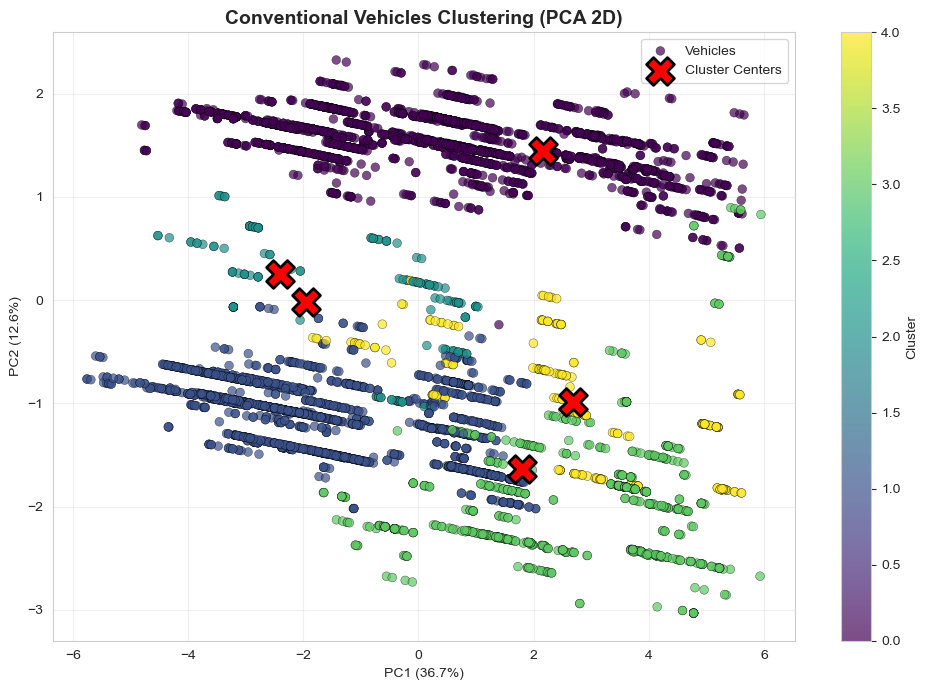

✓ Conventional Vehicles Clustering (PCA 2D)
PC1 variance: 36.7%
PC2 variance: 12.6%
Total variance: 49.3%


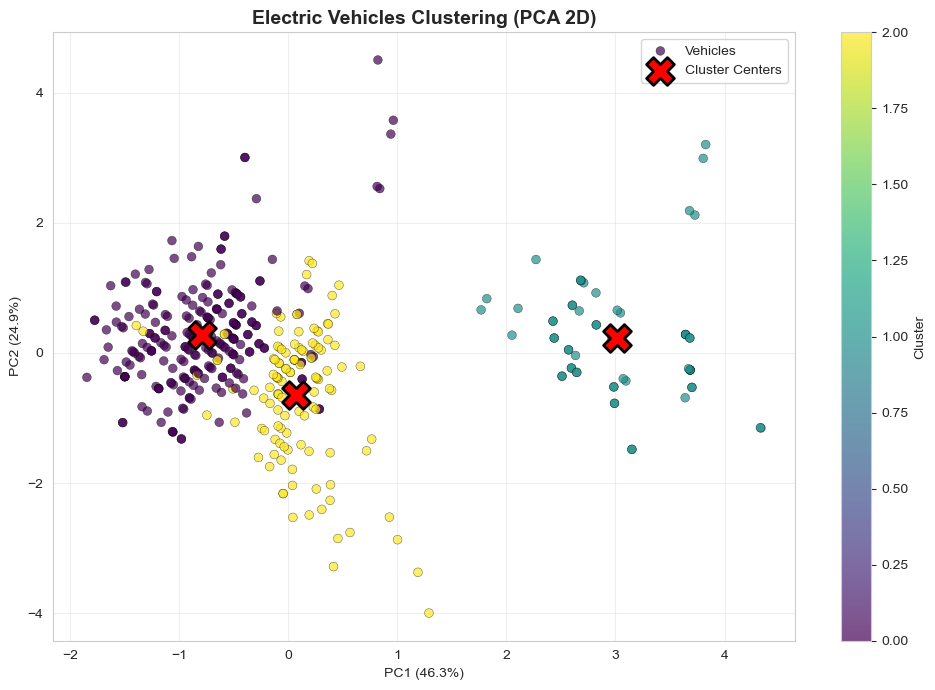

✓ Electric Vehicles Clustering (PCA 2D)
PC1 variance: 46.3%
PC2 variance: 24.9%
Total variance: 71.2%


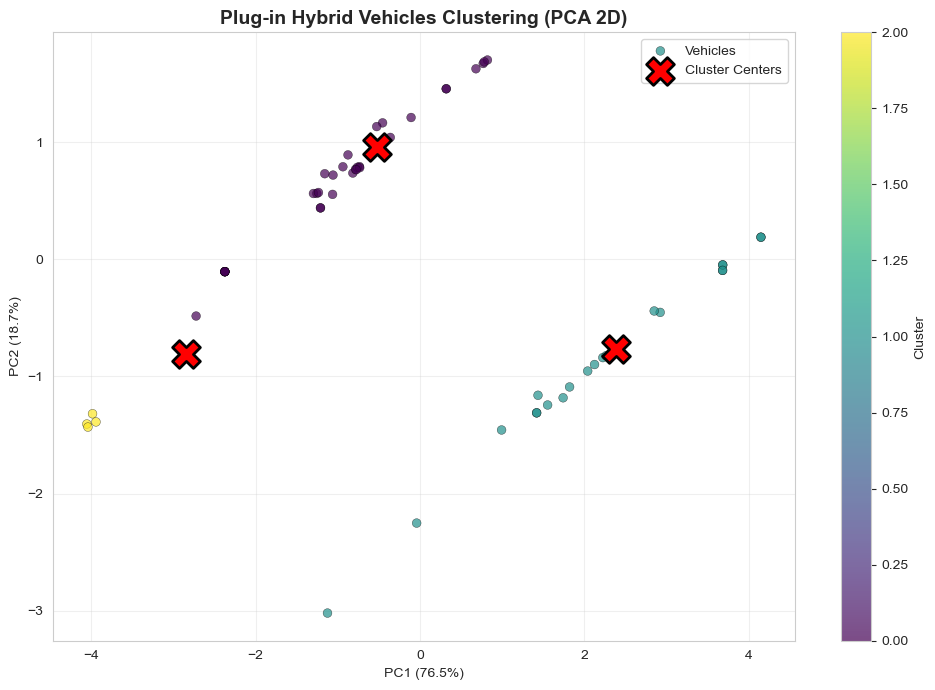

✓ Plug-in Hybrid Vehicles Clustering (PCA 2D)
PC1 variance: 76.5%
PC2 variance: 18.7%
Total variance: 95.2%


In [28]:
#Visualize clusters in 2D using PCA.
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

print("="*80)
print("CLUSTER VISUALIZATION - PCA 2D WITH CENTERS")
print("="*80)

def plot_pca_with_centers(X_scaled, labels, kmeans_model, title):
    
    X_arr = np.asarray(X_scaled)
    
    if X_arr.shape[0] < 2:
        print(f"⚠️ {title}: not enough samples.")
        return
    
    # PCA transform
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_arr)
    
    # Transform cluster centers
    centers_pca = pca.transform(kmeans_model.cluster_centers_)
    
    var1 = pca.explained_variance_ratio_[0] * 100
    var2 = pca.explained_variance_ratio_[1] * 100
    
    plt.figure(figsize=(10, 7))
    
    # Plot sample points
    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        cmap="viridis",
        s=40,
        alpha=0.7,
        edgecolors="black",
        linewidth=0.3,
        label="Vehicles"
    )
    
    # Plot cluster centers ⭐⭐⭐
    plt.scatter(
        centers_pca[:, 0],
        centers_pca[:, 1],
        c="red",
        marker="X",
        s=400,
        edgecolors="black",
        linewidth=2,
        label="Cluster Centers"
    )
    
    plt.xlabel(f"PC1 ({var1:.1f}%)")
    plt.ylabel(f"PC2 ({var2:.1f}%)")
    
    plt.title(title, fontsize=14, fontweight="bold")
    
    plt.colorbar(scatter, label="Cluster")
    
    plt.legend()
    
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    
    plt.show()
    
    print(f"✓ {title}")
    print(f"PC1 variance: {var1:.1f}%")
    print(f"PC2 variance: {var2:.1f}%")
    print(f"Total variance: {(var1+var2):.1f}%")
    

# ---- Run for each vehicle type ----

plot_pca_with_centers(
    X_conv_scaled,
    cluster_labels_conv,
    kmeans_conv,
    "Conventional Vehicles Clustering (PCA 2D)"
)

plot_pca_with_centers(
    X_ev_scaled,
    cluster_labels_ev,
    kmeans_ev,
    "Electric Vehicles Clustering (PCA 2D)"
)

plot_pca_with_centers(
    X_phev_scaled,
    cluster_labels_phev,
    kmeans_phev,
    "Plug-in Hybrid Vehicles Clustering (PCA 2D)"
)


CLUSTER VISUALIZATION - FEATURE RELATIONSHIPS (BY VEHICLE TYPE)


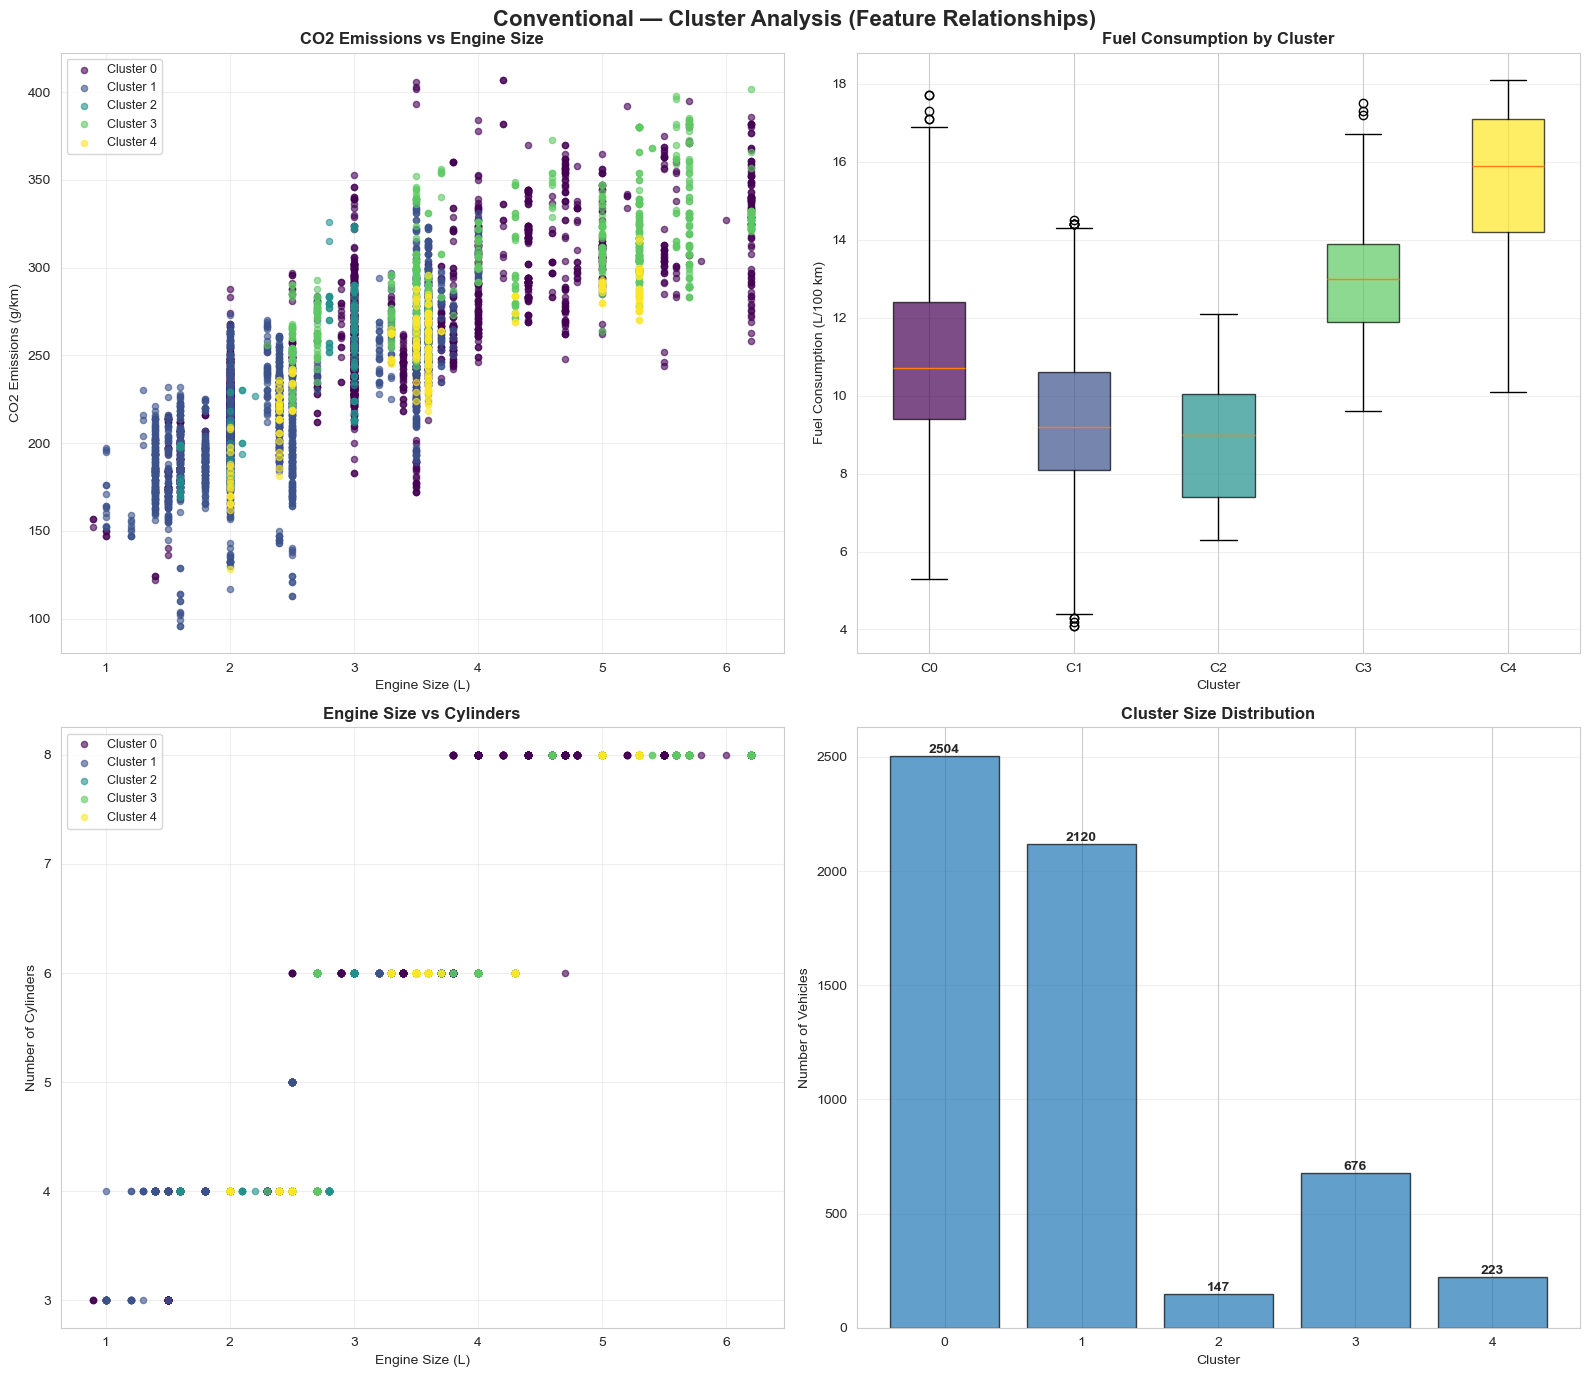

✓ Conventional: feature relationship plots generated (clusters shown: [0, 1, 2, 3, 4]).


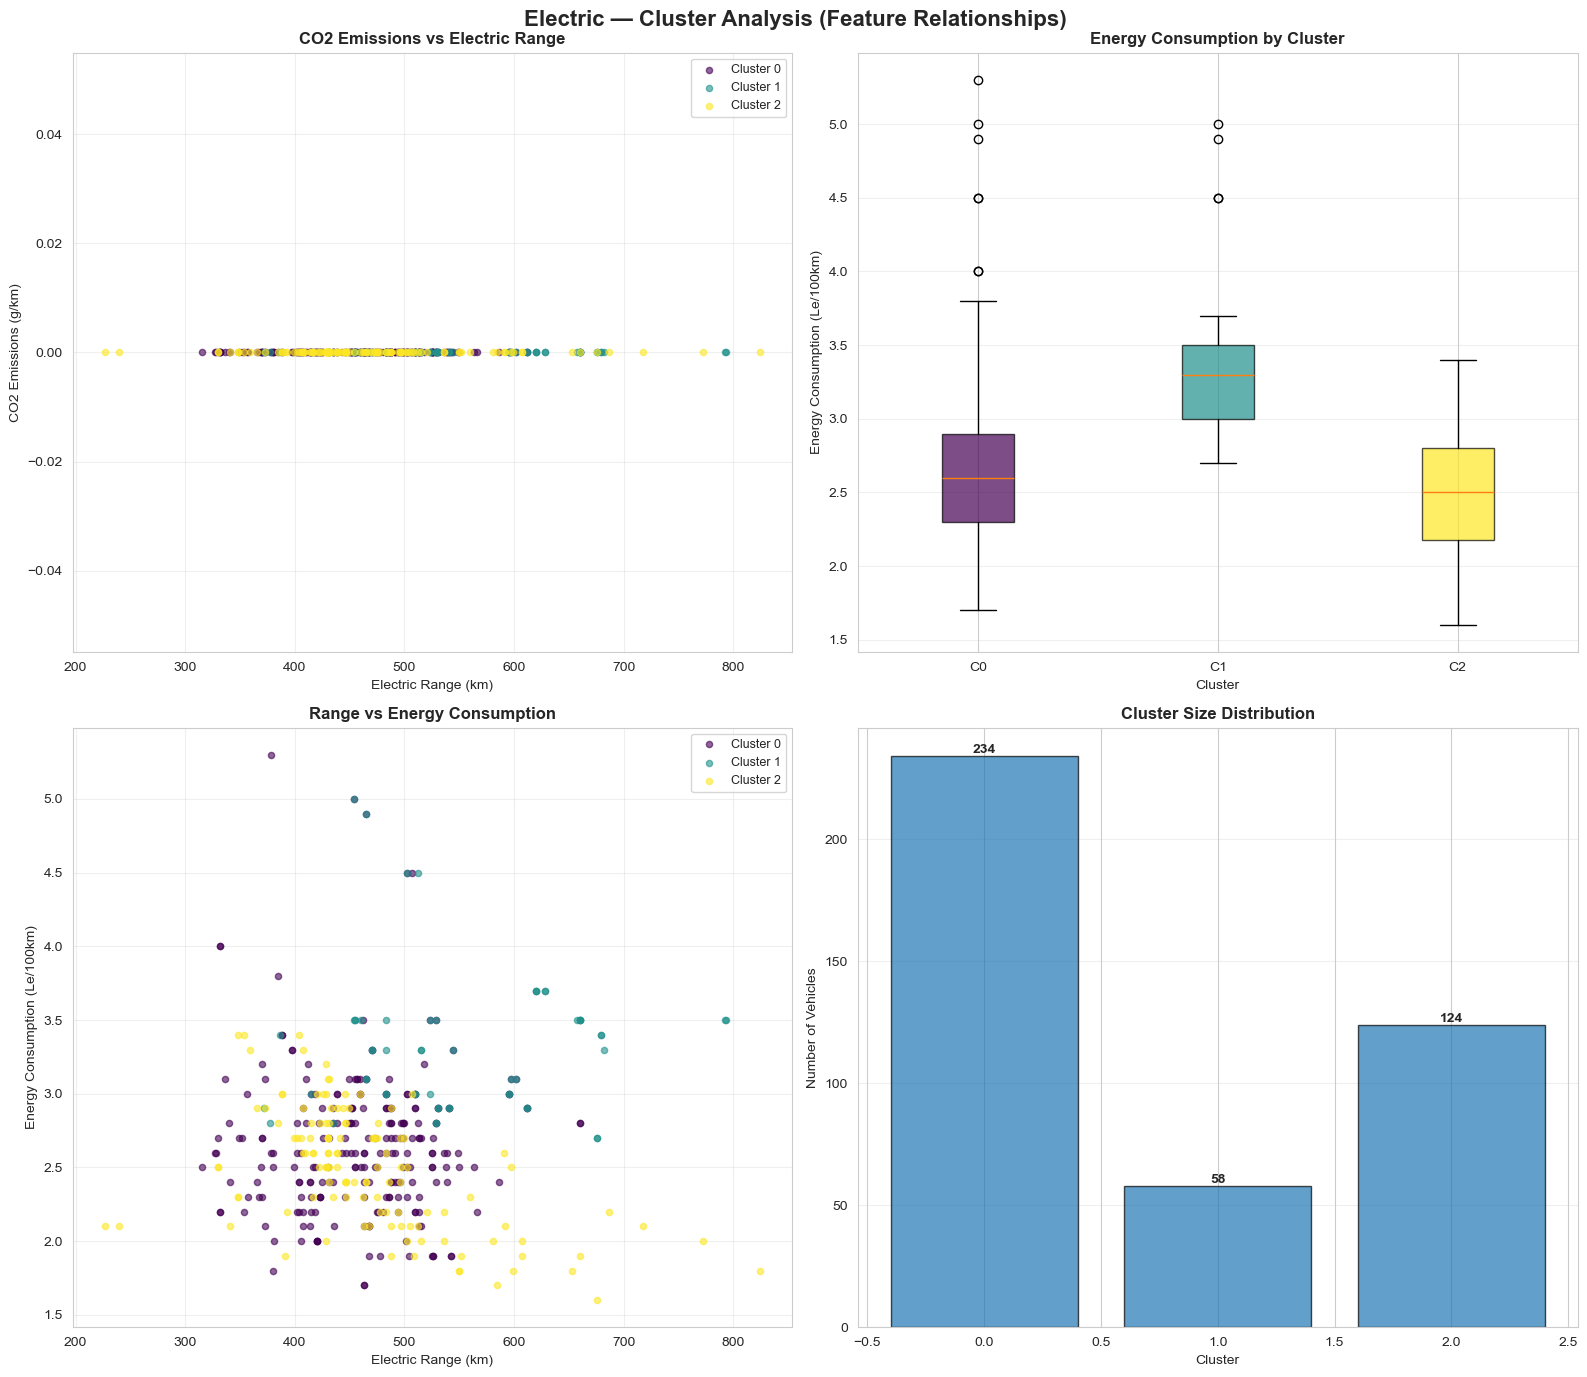

✓ Electric: feature relationship plots generated (clusters shown: [0, 1, 2]).


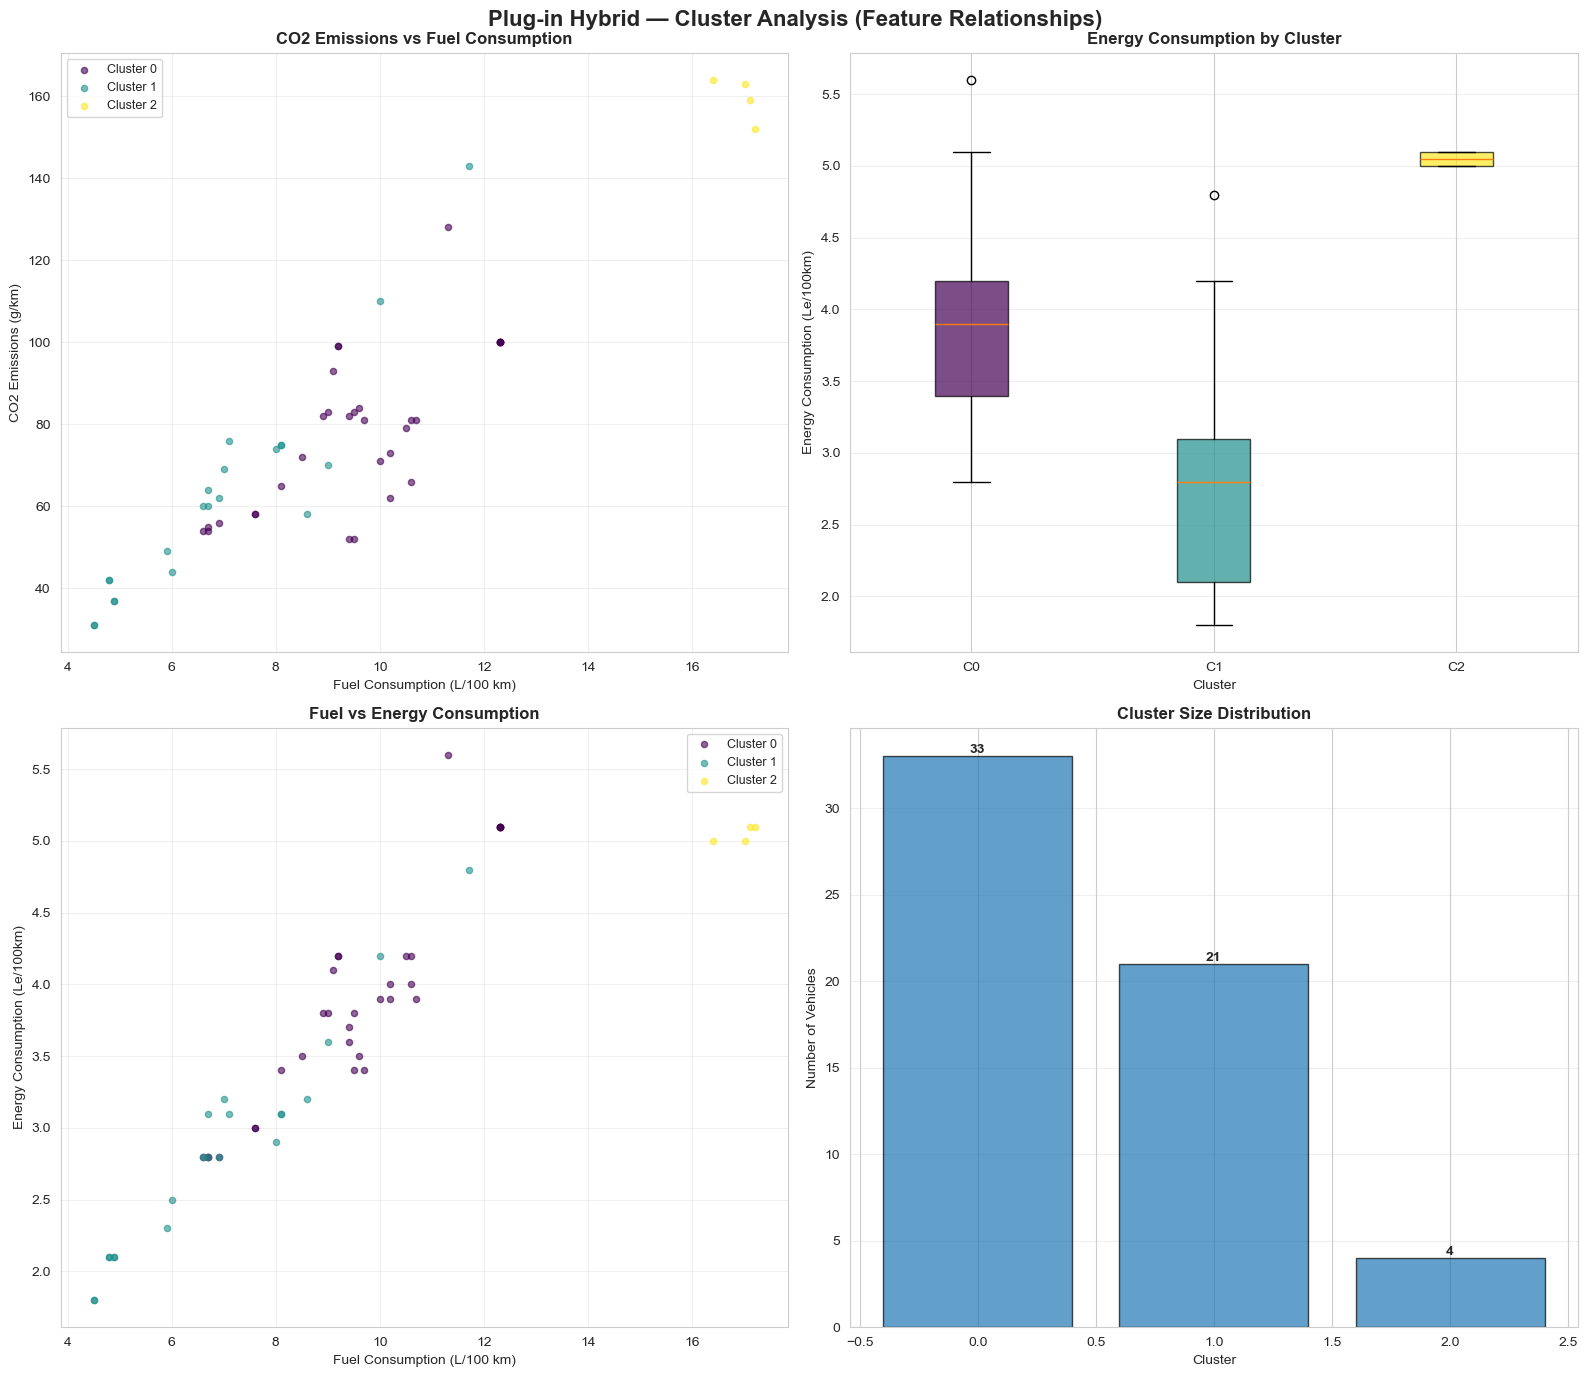

✓ Plug-in Hybrid: feature relationship plots generated (clusters shown: [0, 1, 2]).


In [29]:
#Visualize clusters in feature space.
import numpy as np
import matplotlib.pyplot as plt

print("="*80)
print("CLUSTER VISUALIZATION - FEATURE RELATIONSHIPS (BY VEHICLE TYPE)")
print("="*80)

def plot_feature_relationships(df, vtype, n_clusters, specs, title_suffix=""):
    """
    specs: dict defining which columns to use for each subplot
      specs = {
        "scatter1": ("xcol", "ycol", "title", "xlabel", "ylabel"),
        "box": ("col", "title", "ylabel"),
        "scatter2": ("xcol", "ycol", "title", "xlabel", "ylabel"),
      }
    """
    df_v = df[(df["Vehicle_Type"] == vtype) & (df["Cluster"].notna())].copy()
    if df_v.empty:
        print(f"⚠️ {vtype}: no labeled rows. Skip.")
        return

    # keep only cluster ids that actually exist (some clusters may be missing if tiny)
    present_clusters = sorted(df_v["Cluster"].dropna().unique().tolist())
    k = len(present_clusters)
    if k == 0:
        print(f"⚠️ {vtype}: no clusters present. Skip.")
        return

    colors = plt.cm.viridis(np.linspace(0, 1, max(k, 2)))

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    fig.suptitle(f"{vtype} — Cluster Analysis (Feature Relationships){title_suffix}",
                 fontsize=16, fontweight='bold')

    # -------------------------
    # 1) Scatter 1
    # -------------------------
    x1, y1, t1, xl1, yl1 = specs["scatter1"]
    ax = axes[0, 0]
    if x1 in df_v.columns and y1 in df_v.columns:
        for i, cl in enumerate(present_clusters):
            cd = df_v[df_v["Cluster"] == cl]
            ax.scatter(cd[x1], cd[y1], label=f"Cluster {cl}", alpha=0.6, s=20, color=colors[i])
        ax.set_xlabel(xl1); ax.set_ylabel(yl1); ax.set_title(t1, fontweight='bold')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f"Missing columns:\n{x1} or {y1}", ha="center", va="center")
        ax.set_axis_off()

    # -------------------------
    # 2) Boxplot
    # -------------------------
    box_col, box_title, box_ylabel = specs["box"]
    ax = axes[0, 1]
    if box_col in df_v.columns:
        data = [df_v[df_v["Cluster"] == cl][box_col].dropna().values for cl in present_clusters]
        bp = ax.boxplot(data, labels=[f"C{cl}" for cl in present_clusters], patch_artist=True)
        for patch, c in zip(bp["boxes"], colors[:len(present_clusters)]):
            patch.set_facecolor(c); patch.set_alpha(0.7)
        ax.set_xlabel("Cluster"); ax.set_ylabel(box_ylabel); ax.set_title(box_title, fontweight='bold')
        ax.grid(True, alpha=0.3, axis="y")
    else:
        ax.text(0.5, 0.5, f"Missing column:\n{box_col}", ha="center", va="center")
        ax.set_axis_off()

    # -------------------------
    # 3) Scatter 2
    # -------------------------
    x2, y2, t2, xl2, yl2 = specs["scatter2"]
    ax = axes[1, 0]
    if x2 in df_v.columns and y2 in df_v.columns:
        for i, cl in enumerate(present_clusters):
            cd = df_v[df_v["Cluster"] == cl]
            ax.scatter(cd[x2], cd[y2], label=f"Cluster {cl}", alpha=0.6, s=20, color=colors[i])
        ax.set_xlabel(xl2); ax.set_ylabel(yl2); ax.set_title(t2, fontweight='bold')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f"Missing columns:\n{x2} or {y2}", ha="center", va="center")
        ax.set_axis_off()

    # -------------------------
    # 4) Cluster sizes
    # -------------------------
    ax = axes[1, 1]
    sizes = df_v["Cluster"].value_counts().sort_index()
    bars = ax.bar(sizes.index.astype(int), sizes.values, alpha=0.7, edgecolor="black")
    ax.set_xlabel("Cluster"); ax.set_ylabel("Number of Vehicles")
    ax.set_title("Cluster Size Distribution", fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{int(b.get_height())}",
                ha="center", va="bottom", fontweight="bold")

    plt.tight_layout()
    plt.show()

    print(f"✓ {vtype}: feature relationship plots generated (clusters shown: {present_clusters}).")


# -------------------------
# Specs per vehicle type
# -------------------------
specs_conv = {
    "scatter1": ("Engine Size(L)", "CO2 Emissions(g/km)",
                "CO2 Emissions vs Engine Size", "Engine Size (L)", "CO2 Emissions (g/km)"),
    "box": ("Fuel Consumption Comb (L/100 km)",
            "Fuel Consumption by Cluster", "Fuel Consumption (L/100 km)"),
    "scatter2": ("Engine Size(L)", "Cylinders",
                "Engine Size vs Cylinders", "Engine Size (L)", "Number of Cylinders"),
}

specs_ev = {
    "scatter1": ("Electric Range (km)", "CO2 Emissions(g/km)",
                "CO2 Emissions vs Electric Range", "Electric Range (km)", "CO2 Emissions (g/km)"),
    "box": ("Energy Consumption Comb (Le/100km)",
            "Energy Consumption by Cluster", "Energy Consumption (Le/100km)"),
    "scatter2": ("Electric Range (km)", "Energy Consumption Comb (Le/100km)",
                "Range vs Energy Consumption", "Electric Range (km)", "Energy Consumption (Le/100km)"),
}

specs_phev = {
    "scatter1": ("Fuel Consumption Comb (L/100 km)", "CO2 Emissions(g/km)",
                "CO2 Emissions vs Fuel Consumption", "Fuel Consumption (L/100 km)", "CO2 Emissions (g/km)"),
    "box": ("Energy Consumption Comb (Le/100km)",
            "Energy Consumption by Cluster", "Energy Consumption (Le/100km)"),
    "scatter2": ("Fuel Consumption Comb (L/100 km)", "Energy Consumption Comb (Le/100km)",
                "Fuel vs Energy Consumption", "Fuel Consumption (L/100 km)", "Energy Consumption (Le/100km)"),
}

# -------------------------
# Run plots (use your k values)
# -------------------------
plot_feature_relationships(df_encoded, "Conventional", 5, specs_conv)
plot_feature_relationships(df_encoded, "Electric", 3, specs_ev)
plot_feature_relationships(df_encoded, "Plug-in Hybrid", 3, specs_phev)


CLUSTER VISUALIZATION - FEATURE HEATMAP (BY VEHICLE TYPE)


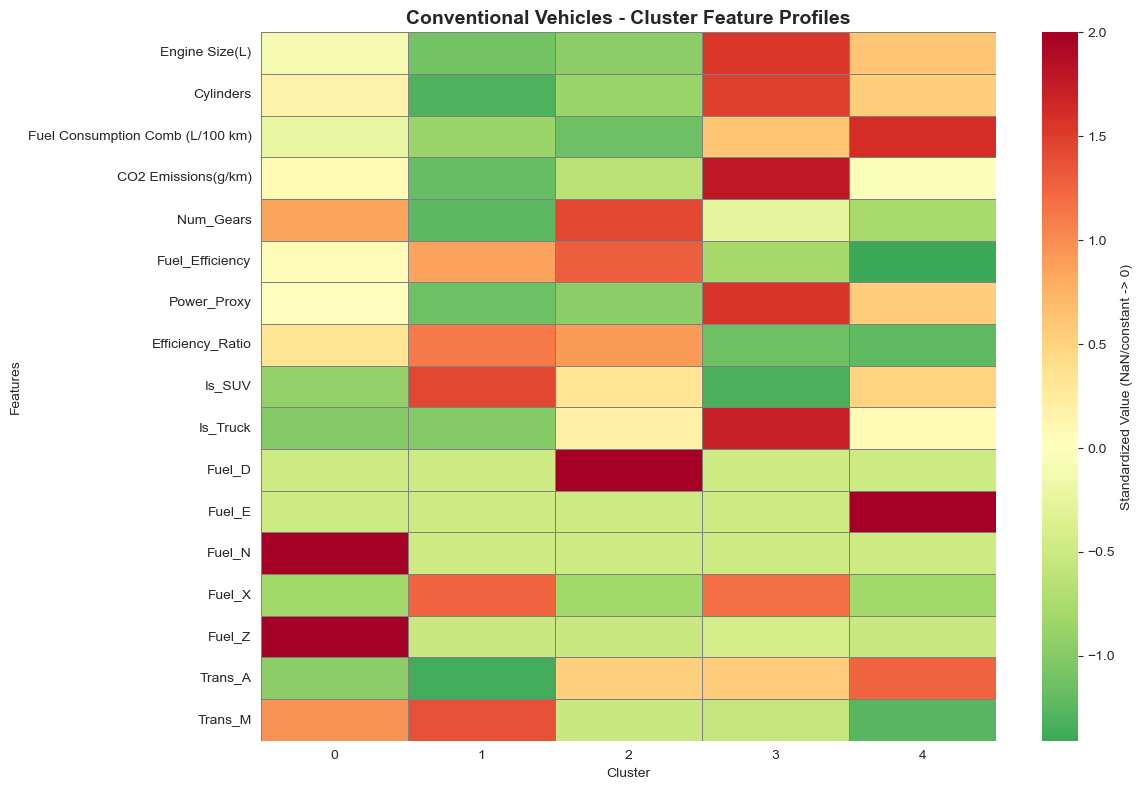

✓ Conventional Vehicles - Cluster Feature Profiles heatmap generated | features shown: 17


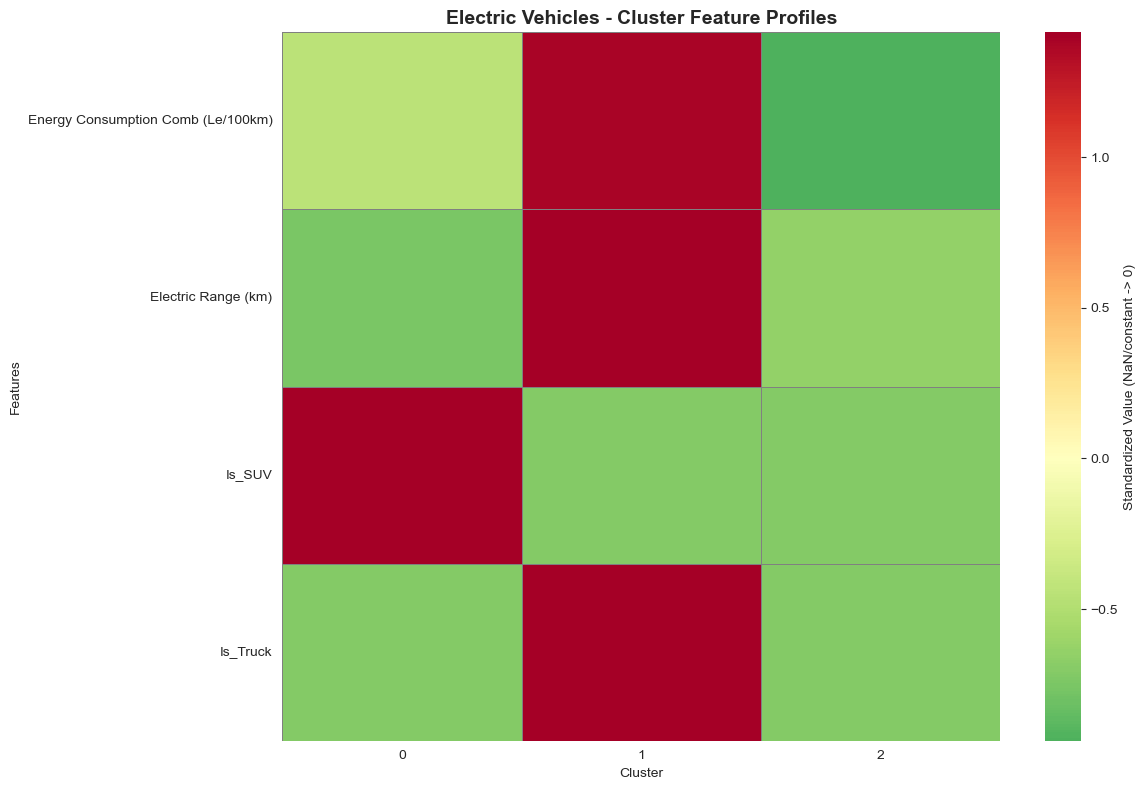

✓ Electric Vehicles - Cluster Feature Profiles heatmap generated | features shown: 4


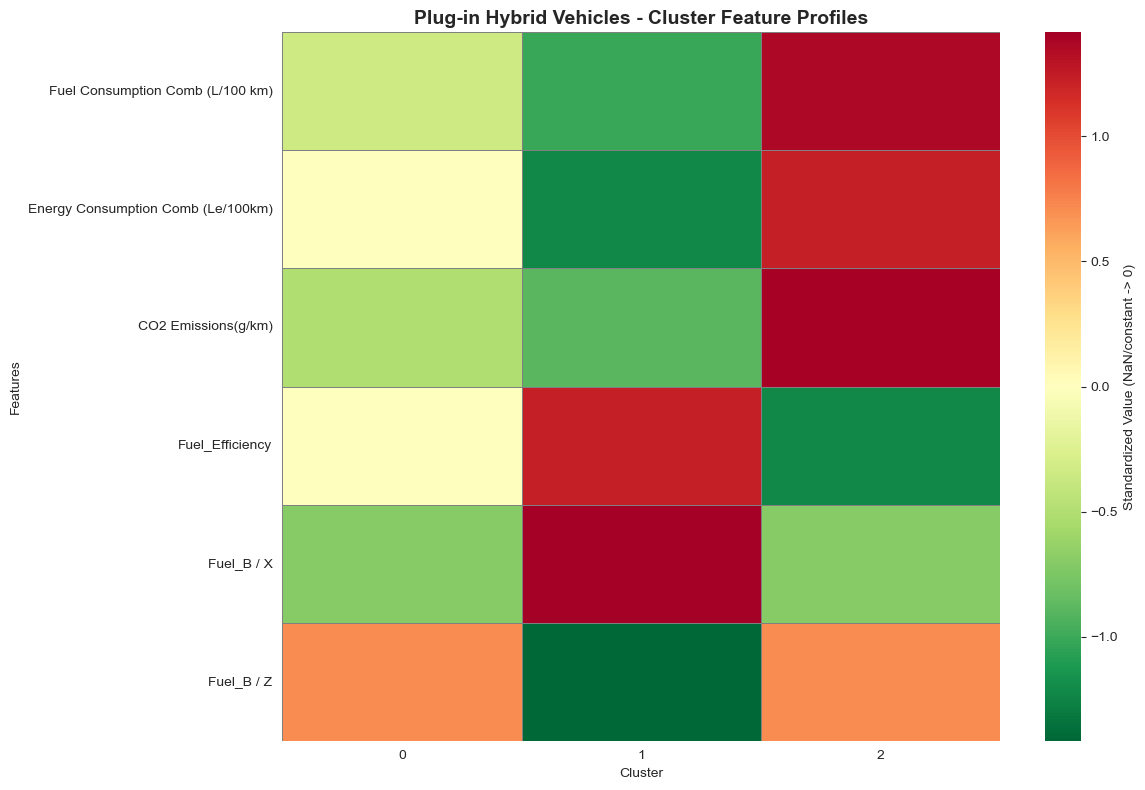

✓ Plug-in Hybrid Vehicles - Cluster Feature Profiles heatmap generated | features shown: 6


In [30]:
#Create a heatmap showing feature profiles by cluster.

# Create a heatmap showing feature profiles by cluster WITHOUT blank cells

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("="*80)
print("CLUSTER VISUALIZATION - FEATURE HEATMAP (BY VEHICLE TYPE)")
print("="*80)

def plot_cluster_heatmap_no_blanks(
    X_scaled,
    labels,
    title,
    drop_constant_features=True,   # True: 删除所有cluster均值完全一样的特征（更干净）
    fill_value=0.0,               # 用0填充NaN，避免heatmap空白（0=中性颜色）
    figsize=(12, 8)
):
    """
    - Computes cluster means per feature
    - Safely z-score normalizes across clusters (feature-wise)
    - Removes all-NaN features and (optionally) constant features
    - Fills any remaining NaNs so the heatmap has no blank cells
    """

    if labels is None or len(labels) == 0:
        print(f"⚠️ {title}: no labels")
        return

    # Ensure DataFrame
    if isinstance(X_scaled, pd.DataFrame):
        df_heat = X_scaled.copy()
    else:
        df_heat = pd.DataFrame(X_scaled)

    # Align labels length with rows (safety)
    if len(labels) != len(df_heat):
        raise ValueError(
            f"{title}: labels length ({len(labels)}) != X rows ({len(df_heat)})"
        )

    df_heat["Cluster"] = labels

    # Mean per cluster
    cluster_means = df_heat.groupby("Cluster").mean(numeric_only=True)

    # 1) Drop features that are all NaN across clusters
    cluster_means = cluster_means.dropna(axis=1, how="all")

    # 2) Optionally drop constant features (std == 0 across clusters)
    #    These are the #1 cause of NaN in z-score
    std = cluster_means.std(axis=0, ddof=0)
    if drop_constant_features:
        non_constant_cols = std[std > 0].index
        cluster_means = cluster_means[non_constant_cols]
        std = cluster_means.std(axis=0, ddof=0)  # recompute after dropping

    # If nothing left, stop
    if cluster_means.shape[1] == 0:
        print(f"⚠️ {title}: no usable features after dropping NaN/constant columns")
        return

    # 3) Safe z-score: if std is 0 (when drop_constant_features=False), avoid division by zero
    mean = cluster_means.mean(axis=0)
    std_safe = std.replace(0, np.nan)
    cluster_means_norm = (cluster_means - mean) / std_safe

    # 4) Fill NaNs so heatmap has no blanks
    cluster_means_norm = cluster_means_norm.fillna(fill_value)

    # Plot
    plt.figure(figsize=figsize)
    sns.heatmap(
        cluster_means_norm.T,
        cmap="RdYlGn_r",
        center=0,
        linewidths=0.5,
        linecolor="gray",
        cbar_kws={"label": "Standardized Value (NaN/constant -> 0)"}
    )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Cluster")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

    print(f"✓ {title} heatmap generated | features shown: {cluster_means_norm.shape[1]}")

# ---- Plot heatmaps ----
plot_cluster_heatmap_no_blanks(
    X_conv_scaled,
    cluster_labels_conv,
    "Conventional Vehicles - Cluster Feature Profiles",
    drop_constant_features=True,   # 推荐True：常量one-hot列会被删掉，图更干净
    fill_value=0.0
)

plot_cluster_heatmap_no_blanks(
    X_ev_scaled,
    cluster_labels_ev,
    "Electric Vehicles - Cluster Feature Profiles",
    drop_constant_features=True,
    fill_value=0.0
)

plot_cluster_heatmap_no_blanks(
    X_phev_scaled,
    cluster_labels_phev,
    "Plug-in Hybrid Vehicles - Cluster Feature Profiles",
    drop_constant_features=True,
    fill_value=0.0
)


## EXPORT RESULTS


In [32]:
# Export clustering results to CSV files.

import pandas as pd

print("="*80)
print("EXPORTING RESULTS")
print("="*80)

# -----------------------------
# 1) Export full dataset with cluster labels
# -----------------------------
export_df = df_engineered.copy()

# Safety checks
if "df_encoded" not in globals():
    raise NameError("df_encoded is not defined. Make sure you created df_encoded and filled df_encoded['Cluster'].")
if "Cluster" not in df_encoded.columns:
    raise NameError("df_encoded['Cluster'] not found. Make sure you filled cluster labels back to df_encoded.")

# Ensure index uniqueness (important for join correctness)
if not export_df.index.is_unique:
    export_df = export_df.reset_index(drop=True)
    print("⚠️ export_df index was not unique -> reset_index applied.")

if not df_encoded.index.is_unique:
    # keep last occurrence if duplicated indices (rare, but can happen)
    df_encoded_for_join = df_encoded[["Cluster"]].copy()
    df_encoded_for_join = df_encoded_for_join[~df_encoded_for_join.index.duplicated(keep="last")]
    print("⚠️ df_encoded index not unique -> de-duplicated for join.")
else:
    df_encoded_for_join = df_encoded[["Cluster"]].copy()

# Drop existing Cluster column in export_df to avoid overlap
if "Cluster" in export_df.columns:
    export_df = export_df.drop(columns=["Cluster"])

# Join ONLY Cluster (avoid Vehicle_Type overlap)
export_df = export_df.join(df_encoded_for_join, how="left")

output_file_1 = "clustered_vehicles.csv"
export_df.to_csv(output_file_1, index=False)

print(f"\n✓ Full dataset with clusters exported:")
print(f"  File: {output_file_1}")
print(f"  Shape: {export_df.shape}")
print(f"  Columns: {len(export_df.columns)}")

clustered_count = export_df["Cluster"].notna().sum()
print(f"  Rows with assigned clusters: {clustered_count} / {len(export_df)}")

# -----------------------------
# 2) Export cluster summary
# -----------------------------
output_file_2 = "cluster_summary.csv"

# Create summary robustly (even if cluster_summary_df doesn't exist)
# Use Vehicle_Type from export_df if present; otherwise, pull from df_encoded
if "Vehicle_Type" not in export_df.columns and "Vehicle_Type" in df_encoded.columns:
    export_df = export_df.join(df_encoded[["Vehicle_Type"]], how="left")

key_numeric_cols = [
    "CO2 Emissions(g/km)",
    "Fuel Consumption Comb (L/100 km)",
    "Energy Consumption Comb (Le/100km)",
    "Electric Range (km)",
    "Engine Size(L)",
    "Cylinders"
]
key_numeric_cols = [c for c in key_numeric_cols if c in export_df.columns]

cluster_summary_df = (
    export_df.dropna(subset=["Cluster"])
    .groupby(["Vehicle_Type", "Cluster"], dropna=False)
    .agg(
        n=("Cluster", "size"),
        **{f"mean_{c}": (c, "mean") for c in key_numeric_cols}
    )
    .reset_index()
    .sort_values(["Vehicle_Type", "Cluster"])
)

cluster_summary_df.to_csv(output_file_2, index=False)

print(f"\n✓ Cluster summary exported:")
print(f"  File: {output_file_2}")
print(f"  Rows (groups): {len(cluster_summary_df)}")

print(f"\n✓ Export completed!")
print(f"\nCluster Summary Preview:")
display(cluster_summary_df.head(20))


EXPORTING RESULTS

✓ Full dataset with clusters exported:
  File: clustered_vehicles.csv
  Shape: (6385, 23)
  Columns: 23
  Rows with assigned clusters: 6144 / 6385

✓ Cluster summary exported:
  File: cluster_summary.csv
  Rows (groups): 11

✓ Export completed!

Cluster Summary Preview:


,Vehicle_Type,Cluster,n,mean_CO2 Emissions(g/km),mean_Fuel Consumption Comb (L/100 km),mean_Energy Consumption Comb (Le/100km),mean_Electric Range (km),mean_Engine Size(L),mean_Cylinders
0,Conventional,0,2504,255.246406,10.963538,NaN,NaN,3.158107,5.742412
1,Conventional,1,2120,219.702358,9.430660,NaN,NaN,2.413208,4.560849
2,Conventional,2,147,235.238095,8.749660,NaN,NaN,2.532653,4.925170
3,Conventional,3,676,303.073964,12.986095,NaN,NaN,4.414349,6.813609
4,Conventional,4,223,252.300448,15.437668,NaN,NaN,3.717489,6.062780
5,Electric,0,234,0.000000,NaN,2.664103,461.346154,NaN,NaN
6,Electric,1,58,0.000000,NaN,3.327586,550.310345,NaN,NaN
7,Electric,2,124,0.000000,NaN,2.487903,465.830645,NaN,NaN
8,Plug-in Hybrid,0,33,78.878788,9.669697,3.936364,58.363636,NaN,NaN
9,Plug-in Hybrid,1,21,62.333333,6.895238,2.833333,56.285714,NaN,NaN


In [33]:
# Final summary of the market segmentation analysis (Vehicle-Type specific)

import numpy as np
import pandas as pd

print("="*80)
print("MARKET SEGMENTATION ANALYSIS - FINAL SUMMARY (BY VEHICLE TYPE)")
print("="*80)

# -----------------------------
# 0) Basic existence checks
# -----------------------------
required_globals = ["df_raw", "df_clean", "df_encoded"]
for g in required_globals:
    if g not in globals():
        raise NameError(f"{g} is not defined. Please run earlier cells first.")

if "Cluster" not in df_encoded.columns:
    raise NameError("df_encoded['Cluster'] not found. Make sure you filled cluster labels back into df_encoded.")

# -----------------------------
# 1) Dataset summary
# -----------------------------
orig_n = df_raw.shape[0]
clean_n = df_clean.shape[0]

# "Final clustered" = how many rows actually got a cluster assigned (notna)
clustered_n = df_encoded["Cluster"].notna().sum()

print(f"\n📊 DATASET SUMMARY:")
print(f"  • Original dataset: {orig_n:,} vehicles")
print(f"  • After cleaning: {clean_n:,} vehicles ({clean_n/orig_n*100:.1f}%)")
print(f"  • Cluster assigned: {clustered_n:,} vehicles ({clustered_n/len(df_encoded)*100:.1f}% of df_encoded)")

# -----------------------------
# 2) Feature engineering summary (robust)
# -----------------------------
# We can infer engineered count as "new columns introduced relative to df_raw"
if "df_engineered" in globals() and isinstance(df_engineered, pd.DataFrame):
    engineered_ncols = df_engineered.shape[1]
    engineered_new = [c for c in df_engineered.columns if c not in df_raw.columns]
    print(f"\n🔧 FEATURE ENGINEERING:")
    print(f"  • Original features: {df_raw.shape[1]}")
    print(f"  • Engineered features (total cols): {engineered_ncols}")
    print(f"  • New engineered columns: {len(engineered_new)}")
else:
    print(f"\n🔧 FEATURE ENGINEERING:")
    print(f"  • Original features: {df_raw.shape[1]}")
    print(f"  • Engineered dataset not found (df_engineered). Skipping engineered feature count.")

# Features used for clustering (by type) if available
print(f"\n🧩 FEATURES USED FOR CLUSTERING (by Vehicle_Type):")
for name in ["X_conv_scaled", "X_ev_scaled", "X_phev_scaled"]:
    if name in globals():
        Xtmp = globals()[name]
        nfeat = Xtmp.shape[1] if hasattr(Xtmp, "shape") else "?"
        print(f"  • {name}: {nfeat} features")
    else:
        print(f"  • {name}: (not found)")

# -----------------------------
# 3) Clustering results & distribution
# -----------------------------
print(f"\n🎯 CLUSTERING RESULTS (by Vehicle_Type):")

# Helper: safe mean
def safe_mean(df, col):
    if col in df.columns and df[col].notna().any():
        return df[col].mean()
    return np.nan

# decide which key metrics to report by type (only if columns exist)
KEY_METRICS_BY_TYPE = {
    "Conventional": ["CO2 Emissions(g/km)", "Fuel Consumption Comb (L/100 km)", "Engine Size(L)", "Cylinders", "Fuel_Efficiency"],
    "Electric": ["CO2 Emissions(g/km)", "Energy Consumption Comb (Le/100km)", "Electric Range (km)"],
    "Plug-in Hybrid": ["CO2 Emissions(g/km)", "Fuel Consumption Comb (L/100 km)", "Energy Consumption Comb (Le/100km)", "Fuel_Efficiency"],
}

# Ensure Vehicle_Type exists
if "Vehicle_Type" not in df_encoded.columns:
    print("⚠️ df_encoded['Vehicle_Type'] not found. Cannot do per-type summary. Showing overall Cluster counts only.")
    print(df_encoded["Cluster"].value_counts(dropna=False))
else:
    for vtype, sub in df_encoded.groupby("Vehicle_Type"):
        sub_assigned = sub.dropna(subset=["Cluster"]).copy()
        if len(sub_assigned) == 0:
            print(f"\n  • {vtype}: 0 clustered rows (all Cluster are NA)")
            continue

        clusters = sorted(sub_assigned["Cluster"].unique())
        k = len(clusters)

        print(f"\n  • {vtype}: {len(sub_assigned):,} clustered vehicles | {k} clusters")

        # Cluster distribution table (compact)
        for c in clusters:
            c_df = sub_assigned[sub_assigned["Cluster"] == c]
            pct = len(c_df) / len(sub_assigned) * 100

            # pick relevant columns for this vtype; if unknown, fall back to CO2 if exists
            cols = KEY_METRICS_BY_TYPE.get(vtype, ["CO2 Emissions(g/km)"])
            metrics_str_parts = []
            for col in cols:
                if col in c_df.columns and c_df[col].notna().any():
                    val = c_df[col].mean()
                    # formatting by column type
                    if "CO2" in col:
                        metrics_str_parts.append(f"Avg CO2 {val:.0f}")
                    elif "Consumption" in col:
                        metrics_str_parts.append(f"Avg {col.split(' (')[0]} {val:.2f}")
                    elif "Range" in col:
                        metrics_str_parts.append(f"Avg Range {val:.0f}")
                    else:
                        metrics_str_parts.append(f"Avg {col} {val:.2f}")

            metrics_str = " | ".join(metrics_str_parts) if metrics_str_parts else "Key means: N/A"

            print(f"     - Cluster {int(c)}: {len(c_df):,} ({pct:.1f}%) | {metrics_str}")

# -----------------------------
# 4) Business insights (by Vehicle_Type)
# -----------------------------
print(f"\n💼 BUSINESS INSIGHTS (by Vehicle_Type):")

if "Vehicle_Type" in df_encoded.columns:
    for vtype, sub in df_encoded.groupby("Vehicle_Type"):
        sub_assigned = sub.dropna(subset=["Cluster"]).copy()
        if len(sub_assigned) == 0:
            continue

        # Largest segment
        counts = sub_assigned["Cluster"].value_counts().sort_values(ascending=False)
        largest_cluster = int(counts.index[0])
        largest_n = int(counts.iloc[0])

        # Most eco-friendly / highest emissions (if CO2 exists)
        if "CO2 Emissions(g/km)" in sub_assigned.columns and sub_assigned["CO2 Emissions(g/km)"].notna().any():
            co2_by_cluster = sub_assigned.groupby("Cluster")["CO2 Emissions(g/km)"].mean()
            eco_cluster = int(co2_by_cluster.idxmin())
            eco_val = float(co2_by_cluster.min())
            high_cluster = int(co2_by_cluster.idxmax())
            high_val = float(co2_by_cluster.max())
        else:
            eco_cluster = eco_val = high_cluster = high_val = np.nan

        # SUV-dominated (if Is_SUV exists)
        if "Is_SUV" in sub_assigned.columns and sub_assigned["Is_SUV"].notna().any():
            suv_by_cluster = sub_assigned.groupby("Cluster")["Is_SUV"].mean() * 100
            suv_cluster = int(suv_by_cluster.idxmax())
            suv_pct = float(suv_by_cluster.max())
        else:
            suv_cluster = suv_pct = np.nan

        print(f"\n  • {vtype}:")
        print(f"     - Largest segment: Cluster {largest_cluster} ({largest_n:,} vehicles)")
        if not np.isnan(eco_cluster):
            print(f"     - Most eco-friendly (lowest CO2): Cluster {eco_cluster} ({eco_val:.0f} g/km)")
            print(f"     - Highest emissions: Cluster {high_cluster} ({high_val:.0f} g/km)")
        else:
            print(f"     - CO2-based insight: N/A (CO2 column missing or empty)")

        if not np.isnan(suv_cluster):
            print(f"     - SUV-dominated: Cluster {suv_cluster} ({suv_pct:.1f}% SUVs)")
        else:
            print(f"     - SUV-dominance insight: N/A (Is_SUV missing)")

else:
    print("⚠️ Vehicle_Type not found; cannot compute per-type business insights.")

# -----------------------------
# 5) Exported files (if defined)
# -----------------------------
print(f"\n📁 EXPORTED FILES:")
if "output_file_1" in globals():
    print(f"  1. {output_file_1} - Full dataset with cluster assignments")
else:
    print("  1. clustered_vehicles.csv - Full dataset with cluster assignments (default name)")

if "output_file_2" in globals():
    print(f"  2. {output_file_2} - Cluster summary statistics")
else:
    print("  2. cluster_summary.csv - Cluster summary statistics (default name)")

print(f"\n✅ ANALYSIS COMPLETE!")
print(f"\n{'='*80}")
print("Next Steps:")
print("  1. Review cluster profiles in detail (by Vehicle_Type)")
print("  2. Develop marketing strategies for each segment")
print("  3. Identify opportunities for new products within each vehicle category")
print("  4. Monitor regulatory compliance (especially CO2) by segment")
print(f"{'='*80}\n")


MARKET SEGMENTATION ANALYSIS - FINAL SUMMARY (BY VEHICLE TYPE)

📊 DATASET SUMMARY:
  • Original dataset: 7,983 vehicles
  • After cleaning: 6,385 vehicles (80.0%)
  • Cluster assigned: 6,144 vehicles (96.2% of df_encoded)

🔧 FEATURE ENGINEERING:
  • Original features: 18
  • Engineered features (total cols): 22
  • New engineered columns: 11

🧩 FEATURES USED FOR CLUSTERING (by Vehicle_Type):
  • X_conv_scaled: 21 features
  • X_ev_scaled: 9 features
  • X_phev_scaled: 21 features

🎯 CLUSTERING RESULTS (by Vehicle_Type):

  • Conventional: 5,670 clustered vehicles | 5 clusters
     - Cluster 0: 2,504 (44.2%) | Avg CO2 255 | Avg Fuel Consumption Comb 10.96 | Avg Engine Size(L) 3.16 | Avg Cylinders 5.74 | Avg Fuel_Efficiency 9.44
     - Cluster 1: 2,120 (37.4%) | Avg CO2 220 | Avg Fuel Consumption Comb 9.43 | Avg Engine Size(L) 2.41 | Avg Cylinders 4.56 | Avg Fuel_Efficiency 10.99
     - Cluster 2: 147 (2.6%) | Avg CO2 235 | Avg Fuel Consumption Comb 8.75 | Avg Engine Size(L) 2.53 | Avg C

## Final Analysis

### Overview

- Market segmentation was performed separately for each vehicle category to ensure meaningful comparisons.
- Conventional vehicles: 5 distinct segments identified
- Electric vehicles: 3 distinct segments identified
- Plug-in hybrid vehicles: 3 distinct segments identified
- Detailed cluster profiles and characteristics were analysed for each vehicle type
- Comprehensive visualisations were generated to support interpretation
- CSV files containing cluster assignments and summary statistics were exported for further use

### Next Steps

1. Review cluster profiles within each vehicle category to extract business insights
2. Develop targeted marketing strategies tailored to each segment
3. Identify product development opportunities based on segment characteristics
4. Monitor emissions performance and regulatory compliance across segments
